# Predicting TP53 Mutation Status from Gene-Expression Profiles

This single submission notebook covers the full project, organised into four parts:

1. **Part 1 — CCLE cohort and exploratory data analysis**: build a clean cell-line cohort, derive TP53 labels from raw mutation annotations, define the train / validation / test split, and run leakage-aware EDA.
2. **Part 2 — CCLE modelling (Tasks 1 and 2)**: predict TP53 mutation status (binary) and mutation type (multiclass) from CCLE RNA, with metadata-only and dummy baselines, multiple model families, and robustness analyses.
3. **Part 3 — TCGA cohort and exploratory data analysis**: build a tumour-only, one-sample-per-patient TCGA cohort from raw UCSC Xena files, define matching labels, and audit cancer-type composition as a confounding risk.
4. **Part 4 — TCGA modelling (Tasks 1 and 2)**: replicate both tasks in TCGA with cancer-type-aware splitting, grouped cross-validation, and ablation across model families.

The project addresses both required tasks:

- **Task 1** — mutant vs wild-type (binary).
- **Task 2** — type of mutation (multiclass), with labels derived per sample from raw mutation annotations and class definitions documented against the assignment's reference materials (Berkeley *Types of Mutations*, EBI, libretexts).

A single methodological rule governs the notebook: **any supervised step that uses the label — including correlation-based gene selection, ANOVA F-score selection, and feature scaling — is fit inside the modelling pipeline on the current training fold only**. Train-only filtering is also applied at the EDA stage so that downstream artefacts are leakage-safe.

# Part 1 — CCLE cohort and exploratory data analysis

This part prepares the CCLE cohort used by Part 2:

1. a filtered RNA expression matrix,
2. a small metadata table (lineage, sex, optional disease),
3. sample-level TP53 labels and the train / validation / test split.

Metadata is retained as an auxiliary covariate, not as a replacement for mRNA signal.

## 1.0 Setup

This section defines paths, configuration, and helper functions used throughout Part 1:
- TP53 label construction from raw mutation annotations,
- train-only RNA filtering,
- exploratory RNA association analysis,
- sample QC and outlier flagging,
- quick metadata-only baselines.

In [1]:
from pathlib import Path
from IPython.display import display

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy
from scipy import stats
import sklearn
import statsmodels

from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

RNG = 42
DATA_DIR = Path("data")
OUT_DIR = Path("processed")
OUT_DIR.mkdir(exist_ok=True, parents=True)

MODEL_PATH = DATA_DIR / "Model.csv"
MUT_PATH = DATA_DIR / "OmicsSomaticMutations.csv"
EXPR_PATH = DATA_DIR / "OmicsExpressionProteinCodingGenesTPMLogp1.csv"

CONFIG = {
    "primary_label": "TP53_mut_nonsyn",
    "detect_expr_threshold": 0.10,
    "min_detect_frac": 0.05,
    "min_variance": 1e-4,
    "corr_alpha": 0.05,
    "corr_min_abs_r": 0.15,
    "max_corr_features_for_eda": 300,
    "outlier_vote_possible": 3,
    "outlier_vote_sure": 4,
    "outlier_contamination": 0.05,
    "min_meta_category_n": 15,
    "test_size": 0.15,
    "val_size_within_temp": 0.15 / 0.85,
}

for path in [MODEL_PATH, MUT_PATH, EXPR_PATH]:
    assert path.exists(), f"Missing file: {path}"


def choose_first_present(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None


def collapse_duplicate_gene_columns(df):
    n_dup = int(df.columns.duplicated().sum())
    if n_dup == 0:
        return df, 0
    collapsed = df.T.groupby(level=0).mean().T
    return collapsed, n_dup


def robust_zscore(values):
    s = pd.Series(values, copy=True)
    med = s.median()
    mad = np.median(np.abs(s - med))
    if mad == 0 or pd.isna(mad):
        return pd.Series(0.0, index=s.index)
    return 0.6745 * (s - med) / mad


def mad_flag(values, threshold=3.5):
    return robust_zscore(values).abs() > threshold


def make_dense_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


TP53_TEXT_COLS = [
    "VariantClassification",
    "VariantInfo",
    "VariantType",
    "ProteinChange",
    "HGVSp_Short",
    "HGVSp",
    "RefSeq",
]


def classify_tp53_event(row):
    vc = str(row.get("VariantClassification", "")).strip().lower()
    vt = str(row.get("VariantType", "")).strip().lower()
    text = " ".join(str(row.get(c, "")) for c in TP53_TEXT_COLS).lower()

    if vc in {
        "frame_shift_del", "frame_shift_ins", "frameshift_deletion", "frameshift_insertion",
        "nonsense_mutation", "splice_site", "translation_start_site",
        "start_codon_del", "start_codon_ins", "stop_codon_del", "stop_codon_ins",
    }:
        return "lof_or_splice"

    if vc in {"missense_mutation", "in_frame_del", "in_frame_ins"}:
        return "missense_or_inframe"

    if vc in {"silent", "synonymous"}:
        return "synonymous"

    lof_terms = [
        "frameshift", "frame_shift", "nonsense", "stop_gained", "stopgain",
        "splice", "start_lost", "stop_lost", "trunc", "truncating",
    ]
    missense_terms = [
        "missense", "nonsynonymous", "non_synonymous", "inframe", "in_frame",
        "nonframeshift", "non_frameshift",
    ]
    syn_terms = ["synonymous", "silent"]

    if any(term in text for term in lof_terms):
        return "lof_or_splice"
    if any(term in text for term in missense_terms):
        return "missense_or_inframe"
    if any(term in text for term in syn_terms):
        return "synonymous"
    if vc:
        return "other_or_unknown"
    if vt in {"snp", "dnp", "tnp", "onp", "del", "ins"}:
        return "other_or_unknown"
    return "unknown"


def corr_against_binary(X, y, method="pearson"):
    assert X.index.equals(y.index), "X and y must have aligned indices."
    y = pd.Series(y, index=X.index).astype(float)
    y_vec = y.to_numpy()
    cols = X.columns

    if method == "spearman":
        X_use = X.rank(axis=0, method="average").to_numpy(dtype=float)
        y_use = pd.Series(y_vec, index=y.index).rank(method="average").to_numpy(dtype=float)
    else:
        X_use = X.to_numpy(dtype=float)
        y_use = y_vec.astype(float)

    x_std = X_use.std(axis=0, ddof=1)
    valid = x_std > 0
    valid_cols = cols[valid]

    out = pd.DataFrame(index=cols)
    out[f"{method}_r"] = np.nan
    out[f"{method}_p"] = np.nan
    out[f"{method}_p_bh"] = np.nan

    if valid.sum() == 0:
        return out

    Xv = X_use[:, valid]
    yc = y_use - y_use.mean()
    Xc = Xv - Xv.mean(axis=0, keepdims=True)

    denom = np.sqrt((Xc ** 2).sum(axis=0) * (yc ** 2).sum())
    r = (Xc * yc[:, None]).sum(axis=0) / np.clip(denom, 1e-12, None)

    n = len(y_use)
    t_stat = r * np.sqrt((n - 2) / np.clip(1 - r ** 2, 1e-12, None))
    p = 2 * stats.t.sf(np.abs(t_stat), df=n - 2)
    p_bh = multipletests(p, method="fdr_bh")[1]

    out.loc[valid_cols, f"{method}_r"] = r
    out.loc[valid_cols, f"{method}_p"] = p
    out.loc[valid_cols, f"{method}_p_bh"] = p_bh
    return out


def collapse_categories(train_s, val_s, min_n=15, other_label="Other"):
    train_s = train_s.fillna("Unknown").astype(str)
    val_s = val_s.fillna("Unknown").astype(str)
    counts = train_s.value_counts()
    major = set(counts[counts >= min_n].index.tolist())
    train_out = train_s.where(train_s.isin(major), other=other_label)
    val_out = val_s.where(val_s.isin(major), other=other_label)
    return train_out, val_out, counts


def eval_meta_baseline(train_df, val_df, y_train, y_val, cols, min_n=15):
    if len(cols) == 0:
        return None

    train_proc = pd.DataFrame(index=train_df.index)
    val_proc = pd.DataFrame(index=val_df.index)

    for c in cols:
        train_proc[c], val_proc[c], _ = collapse_categories(train_df[c], val_df[c], min_n=min_n)

    enc = make_dense_onehot_encoder()
    Xtr = enc.fit_transform(train_proc)
    Xva = enc.transform(val_proc)

    clf = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RNG)
    clf.fit(Xtr, y_train)
    prob = clf.predict_proba(Xva)[:, 1]

    return {
        "model": "+".join(cols),
        "n_features": Xtr.shape[1],
        "auroc": roc_auc_score(y_val, prob),
        "auprc": average_precision_score(y_val, prob),
    }


def save_parquet_with_id(df, filename, id_col="ModelID"):
    path = OUT_DIR / filename
    out = df.copy()
    out.insert(0, id_col, out.index.astype(str))
    out.to_parquet(path, index=False)
    return path


def save_series_with_id(s, filename, value_name=None, id_col="ModelID"):
    path = OUT_DIR / filename
    s = s.copy()

    # Ensure the value column has a valid string name
    if value_name is None:
        if s.name is None:
            value_name = filename.replace(".parquet", "")
        else:
            value_name = str(s.name)
    else:
        value_name = str(value_name)

    # Ensure the index column name is also a string
    if id_col is None:
        id_col = s.index.name if s.index.name is not None else "ModelID"
    id_col = str(id_col)

    df = s.rename(value_name).rename_axis(id_col).reset_index()

    # Final safety: force all column names to strings
    df.columns = [str(c) for c in df.columns]

    df.to_parquet(path, index=False)
    return path

print(
    f"pandas {pd.__version__} | numpy {np.__version__} | scipy {scipy.__version__} | "
    f"sklearn {sklearn.__version__} | statsmodels {statsmodels.__version__}"
)
print(json.dumps(CONFIG, indent=2))


pandas 3.0.2 | numpy 2.4.4 | scipy 1.17.1 | sklearn 1.8.0 | statsmodels 0.14.6
{
  "primary_label": "TP53_mut_nonsyn",
  "detect_expr_threshold": 0.1,
  "min_detect_frac": 0.05,
  "min_variance": 0.0001,
  "corr_alpha": 0.05,
  "corr_min_abs_r": 0.15,
  "max_corr_features_for_eda": 300,
  "outlier_vote_possible": 3,
  "outlier_vote_sure": 4,
  "outlier_contamination": 0.05,
  "min_meta_category_n": 15,
  "test_size": 0.15,
  "val_size_within_temp": 0.17647058823529413
}


## 1.1 Load data, keep small metadata, and build TP53 labels

The goal is to build a clean sample-level table containing:
- expression data,
- a small metadata subset for optional covariate modelling,
- TP53 labels derived from raw mutation annotations.

The metadata table is intentionally narrow and is not meant to replace the mRNA signal.

In [2]:
model = pd.read_csv(MODEL_PATH)
muts = pd.read_csv(MUT_PATH, low_memory=False)
expr = pd.read_csv(EXPR_PATH, index_col=0)

assert "ModelID" in muts.columns, "Expected ModelID in mutation file."
assert "HugoSymbol" in muts.columns, "Expected HugoSymbol in mutation file."

expr.index.name = "ModelID"
expr.columns = expr.columns.str.replace(r"\s*\([^)]*\)$", "", regex=True)
expr, n_collapsed_gene_names = collapse_duplicate_gene_columns(expr)

lineage_col = choose_first_present(
    model.columns,
    ["OncotreeLineage", "OncotreeLineageDerived", "Lineage", "lineage"],
)
disease_col = choose_first_present(
    model.columns,
    ["OncotreePrimaryDisease", "PrimaryDisease", "Primary Disease", "Disease"],
)
sex_col = choose_first_present(
    model.columns,
    ["Sex", "sex", "Gender", "gender", "PatientSex"],
)
name_col = choose_first_present(
    model.columns,
    ["StrippedCellLineName", "CellLineName", "ModelName", "CCLEName"],
)

model_keep = ["ModelID"] + [c for c in [name_col, lineage_col, sex_col, disease_col] if c is not None]
model_meta = model[model_keep].drop_duplicates("ModelID").set_index("ModelID")

expr_ids = pd.Index(expr.index.unique(), name="ModelID")
mut_ids = pd.Index(pd.Series(muts["ModelID"].dropna().astype(str).unique()).sort_values(), name="ModelID")
model_ids = pd.Index(model_meta.index.unique().astype(str), name="ModelID")

overlap_summary = pd.Series(
    {
        "expression_samples": len(expr_ids),
        "mutation_covered_samples": len(mut_ids),
        "metadata_samples": len(model_ids),
        "expr_and_mut_overlap": len(expr_ids.intersection(mut_ids)),
        "expr_and_meta_overlap": len(expr_ids.intersection(model_ids)),
        "mut_and_meta_overlap": len(mut_ids.intersection(model_ids)),
        "expr_mut_meta_overlap": len(expr_ids.intersection(mut_ids).intersection(model_ids)),
    },
    name="n",
)

print(f"Model:      {model.shape}")
print(f"Mutations:  {muts.shape}")
print(f"Expression: {expr.shape}")
print(f"Collapsed duplicate gene symbols after stripping suffixes: {n_collapsed_gene_names}")
print(f"Metadata columns kept: {[c for c in [name_col, lineage_col, sex_col, disease_col] if c is not None]}")
display(overlap_summary.to_frame())

tp53_muts = muts.loc[muts["HugoSymbol"].eq("TP53")].copy()
tp53_muts["tp53_event_class"] = tp53_muts.apply(classify_tp53_event, axis=1)

priority_map = {
    "lof_or_splice": 5,
    "missense_or_inframe": 4,
    "other_or_unknown": 3,
    "synonymous": 2,
    "unknown": 1,
}
tp53_muts["priority"] = tp53_muts["tp53_event_class"].map(priority_map).fillna(0).astype(int)

best_tp53 = (
    tp53_muts.sort_values(["ModelID", "priority"], ascending=[True, False])
    .drop_duplicates("ModelID", keep="first")
    .set_index("ModelID")
)

called_ids = set(muts["ModelID"].dropna().astype(str).unique())
expr_ids = set(expr.index.astype(str))
common = sorted(called_ids & expr_ids)

expr.index = expr.index.astype(str)
X_all = expr.loc[common].copy()

sample_meta = pd.DataFrame(index=pd.Index(common, name="ModelID")).join(model_meta, how="left")
sample_meta["TP53_event_class"] = best_tp53["tp53_event_class"].reindex(common)
sample_meta["tp53_event_count"] = tp53_muts.groupby("ModelID").size().reindex(common).fillna(0).astype(int)

sample_meta["TP53_mut_any"] = sample_meta.index.isin(best_tp53.index.astype(str)).astype(int)
sample_meta["TP53_mut_nonsyn"] = sample_meta["TP53_event_class"].isin(["lof_or_splice", "missense_or_inframe"]).astype(int)
sample_meta["TP53_mut_lof"] = sample_meta["TP53_event_class"].eq("lof_or_splice").astype(int)
sample_meta["TP53_mut_ambiguous"] = sample_meta["TP53_event_class"].isin(["other_or_unknown", "unknown", "synonymous"]).astype(int)

mut_type = sample_meta["TP53_event_class"].fillna("wild_type").rename("mut_type")
sample_meta["TP53_task2_label"] = mut_type.astype(str)
y_primary = sample_meta[CONFIG["primary_label"]].rename(CONFIG["primary_label"])

print(f"Usable samples with mutation-call coverage and expression: {len(common):,}")
print(f"Primary label ({CONFIG['primary_label']}): {int(y_primary.sum()):,} positives ({y_primary.mean():.1%})")
print(f"TP53_mut_any:   {int(sample_meta['TP53_mut_any'].sum()):,} positives ({sample_meta['TP53_mut_any'].mean():.1%})")
print(f"TP53_mut_lof:   {int(sample_meta['TP53_mut_lof'].sum()):,} positives ({sample_meta['TP53_mut_lof'].mean():.1%})")
print(f"Cell lines with >1 TP53 event: {(sample_meta['tp53_event_count'] > 1).sum():,}")

event_counts = (
    sample_meta["TP53_event_class"]
    .fillna("wild_type")
    .value_counts(dropna=False)
    .rename_axis("event_class")
    .to_frame("n_cell_lines")
)
display(event_counts)


Model:      (2116, 49)
Mutations:  (751310, 70)
Expression: (1684, 19205)
Collapsed duplicate gene symbols after stripping suffixes: 0
Metadata columns kept: ['StrippedCellLineName', 'OncotreeLineage', 'Sex', 'OncotreePrimaryDisease']


,n
expression_samples,1684
mutation_covered_samples,1939
metadata_samples,2116
expr_and_mut_overlap,1608
expr_and_meta_overlap,1684
mut_and_meta_overlap,1939
expr_mut_meta_overlap,1608


Usable samples with mutation-call coverage and expression: 1,608
Primary label (TP53_mut_nonsyn): 987 positives (61.4%)
TP53_mut_any:   987 positives (61.4%)
TP53_mut_lof:   362 positives (22.5%)
Cell lines with >1 TP53 event: 115


,n_cell_lines
event_class,
missense_or_inframe,625
wild_type,621
lof_or_splice,362


## 1.2 Inspect raw TP53 mutation annotations

This block directly inspects the raw TP53 mutation rows using the columns most relevant for manual review:

- `HugoSymbol`
- `VariantType`
- `VariantInfo`
- `DNAChange`
- `ProteinChange`

This does **not** replace the derived label logic above. It is a QC step to verify that the raw TP53 rows look biologically and syntactically sensible before continuing.

In [3]:
# Direct TP53 / p53 mutation annotation QC
required_tp53_cols = [
    "HugoSymbol",
    "VariantType",
    "VariantInfo",
    "DNAChange",
    "ProteinChange",
]

missing_tp53_cols = [c for c in required_tp53_cols if c not in tp53_muts.columns]
if missing_tp53_cols:
    print(f"Missing expected TP53 mutation columns: {missing_tp53_cols}")

tp53_view_cols = [c for c in required_tp53_cols if c in tp53_muts.columns]
tp53_view = tp53_muts[tp53_view_cols].copy()

print(f"Total TP53 mutation rows: {len(tp53_view):,}")
print(f"Unique ModelID with any TP53 row: {tp53_muts['ModelID'].astype(str).nunique():,}")

print("First TP53 rows (raw annotations):")
display(tp53_view.head(20))

if "VariantType" in tp53_view.columns:
    print("VariantType counts:")
    display(tp53_view["VariantType"].fillna("<NA>").value_counts(dropna=False).to_frame("n_rows"))

if "VariantInfo" in tp53_view.columns:
    print("VariantInfo counts:")
    display(tp53_view["VariantInfo"].fillna("<NA>").value_counts(dropna=False).to_frame("n_rows"))

if "ProteinChange" in tp53_view.columns:
    print("Top ProteinChange values:")
    display(tp53_view["ProteinChange"].fillna("<NA>").value_counts(dropna=False).head(25).to_frame("n_rows"))

missingness_summary = pd.Series(
    {c: int(tp53_view[c].isna().sum()) for c in tp53_view.columns},
    name="n_missing",
)
print("Missing values across TP53 review columns:")
display(missingness_summary.to_frame())

# Helpful QC views for rows that may need manual inspection
qc_examples = {}
if "ProteinChange" in tp53_view.columns:
    qc_examples["missing_protein_change"] = tp53_muts.loc[
        tp53_muts["ProteinChange"].isna(),
        ["ModelID"] + tp53_view_cols + [c for c in ["VariantClassification", "tp53_event_class"] if c in tp53_muts.columns],
    ].head(15)

if "DNAChange" in tp53_view.columns:
    qc_examples["missing_dna_change"] = tp53_muts.loc[
        tp53_muts["DNAChange"].isna(),
        ["ModelID"] + tp53_view_cols + [c for c in ["VariantClassification", "tp53_event_class"] if c in tp53_muts.columns],
    ].head(15)

if "tp53_event_class" in tp53_muts.columns:
    qc_examples["ambiguous_or_unknown"] = tp53_muts.loc[
        tp53_muts["tp53_event_class"].isin(["other_or_unknown", "unknown", "synonymous"]),
        ["ModelID"] + tp53_view_cols + [c for c in ["VariantClassification", "tp53_event_class"] if c in tp53_muts.columns],
    ].head(20)

for name, df in qc_examples.items():
    if len(df) > 0:
        print(f"QC example: {name}")
        display(df)

# Compact table to compare raw mutation annotations against the derived TP53 event label
tp53_review_summary = tp53_muts.loc[:, [c for c in [
    "ModelID", "HugoSymbol", "VariantType", "VariantInfo", "DNAChange", "ProteinChange",
    "VariantClassification", "tp53_event_class"
] if c in tp53_muts.columns]].copy()

display(tp53_review_summary.head(20))


Total TP53 mutation rows: 1,319
Unique ModelID with any TP53 row: 1,174
First TP53 rows (raw annotations):


,HugoSymbol,VariantType,VariantInfo,DNAChange,ProteinChange
154890,TP53,SNV,missense_variant,ENST00000269305.9:c.1165G>T,p.G389W
154891,TP53,deletion,frameshift_variant,ENST00000269305.9:c.1146del,p.K382NfsTer40
154892,TP53,SNV,splice_acceptor_variant,ENST00000269305.9:c.1101-2A>C,NaN
154893,TP53,SNV,splice_acceptor_variant,ENST00000269305.9:c.1101-2A>C,NaN
154894,TP53,deletion,splice_donor_variant&coding_sequence_variant,ENST00000269305.9:c.1097_1100+1del,NaN
154895,TP53,substitution,missense_variant,ENST00000269305.9:c.1049_1050delinsCT,p.L350P
154896,TP53,SNV,missense_variant,ENST00000269305.9:c.1049T>C,p.L350P
154897,TP53,SNV,stop_gained,ENST00000269305.9:c.1045G>T,p.E349Ter
154898,TP53,SNV,missense_variant,ENST00000269305.9:c.1040C>T,p.A347V
154899,TP53,SNV,missense_variant,ENST00000269305.9:c.1039G>C,p.A347P


VariantType counts:


,n_rows
VariantType,
SNV,1106
deletion,147
insertion,43
substitution,23


VariantInfo counts:


...

Missing values across TP53 review columns:


,n_missing
HugoSymbol,0
VariantType,0
VariantInfo,0
DNAChange,0
ProteinChange,111


QC example: missing_protein_change


,ModelID,HugoSymbol,VariantType,VariantInfo,DNAChange,ProteinChange,tp53_event_class
154892,ACH-000997,TP53,SNV,splice_acceptor_variant,ENST00000269305.9:c.1101-2A>C,NaN,lof_or_splice
154893,ACH-001061,TP53,SNV,splice_acceptor_variant,ENST00000269305.9:c.1101-2A>C,NaN,lof_or_splice
154894,ACH-000227,TP53,deletion,splice_donor_variant&coding_sequence_variant,ENST00000269305.9:c.1097_1100+1del,NaN,lof_or_splice
154919,ACH-001143,TP53,SNV,splice_acceptor_variant,ENST00000269305.9:c.994-1G>A,NaN,lof_or_splice
154920,ACH-000484,TP53,SNV,splice_acceptor_variant,ENST00000269305.9:c.994-2A>G,NaN,lof_or_splice
154921,ACH-000243,TP53,deletion,splice_donor_variant&splice_donor_5th_base_var...,ENST00000269305.9:c.972_993+16del,NaN,lof_or_splice
154922,ACH-000557,TP53,SNV,splice_donor_variant,ENST00000269305.9:c.993+2T>G,NaN,lof_or_splice
154923,ACH-000502,TP53,SNV,splice_donor_variant,ENST00000269305.9:c.993+1G>A,NaN,lof_or_splice
154924,ACH-002665,TP53,SNV,splice_donor_variant,ENST00000269305.9:c.993+1G>C,NaN,lof_or_splice
154925,ACH-000021,TP53,SNV,splice_donor_variant,ENST00000269305.9:c.993+1G>T,NaN,lof_or_splice


,ModelID,HugoSymbol,VariantType,VariantInfo,DNAChange,ProteinChange,tp53_event_class
154890,ACH-000940,TP53,SNV,missense_variant,ENST00000269305.9:c.1165G>T,p.G389W,missense_or_inframe
154891,ACH-000632,TP53,deletion,frameshift_variant,ENST00000269305.9:c.1146del,p.K382NfsTer40,lof_or_splice
154892,ACH-000997,TP53,SNV,splice_acceptor_variant,ENST00000269305.9:c.1101-2A>C,NaN,lof_or_splice
154893,ACH-001061,TP53,SNV,splice_acceptor_variant,ENST00000269305.9:c.1101-2A>C,NaN,lof_or_splice
154894,ACH-000227,TP53,deletion,splice_donor_variant&coding_sequence_variant,ENST00000269305.9:c.1097_1100+1del,NaN,lof_or_splice
154895,ACH-001975,TP53,substitution,missense_variant,ENST00000269305.9:c.1049_1050delinsCT,p.L350P,missense_or_inframe
154896,ACH-002283,TP53,SNV,missense_variant,ENST00000269305.9:c.1049T>C,p.L350P,missense_or_inframe
154897,ACH-000720,TP53,SNV,stop_gained,ENST00000269305.9:c.1045G>T,p.E349Ter,lof_or_splice
154898,ACH-000701,TP53,SNV,missense_variant,ENST00000269305.9:c.1040C>T,p.A347V,missense_or_inframe
154899,ACH-000803,TP53,SNV,missense_variant,ENST00000269305.9:c.1039G>C,p.A347P,missense_or_inframe


## 1.3 Train / validation / test split

The split is stratified on the primary binary label `TP53_mut_nonsyn`. Stratification keeps positive-class prevalence consistent across all three splits.

The split assignment built here is reused for Task 1 throughout Part 2. Task 2 builds its own split later in Part 2, because Task 2 requires stratification by mutation-type label and lineage jointly.

In [4]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_all,
    y_primary,
    test_size=CONFIG["test_size"],
    stratify=y_primary,
    random_state=RNG,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=CONFIG["val_size_within_temp"],
    stratify=y_temp,
    random_state=RNG,
)

split_membership = pd.Series(index=X_all.index, dtype="object")
split_membership.loc[X_train.index] = "train"
split_membership.loc[X_val.index] = "val"
split_membership.loc[X_test.index] = "test"
sample_meta["split"] = split_membership

split_summary = pd.DataFrame(
    {
        "n": [len(y_train), len(y_val), len(y_test)],
        "tp53_mut_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    },
    index=["train", "val", "test"],
)
display(split_summary.round(3))


,n,tp53_mut_rate
train,1124,0.614
val,242,0.612
test,242,0.616


## 1.4 Metadata diagnostics for optional covariate use

Metadata is allowed as an auxiliary covariate. These diagnostics check:
- missingness,
- category balance across train / validation / test,
- primary-label rate by category within training.

The results inform which metadata columns are usable for the metadata-only and RNA + metadata models in Part 2.

In [5]:
present_meta_cols = [c for c in [lineage_col, sex_col, disease_col] if c is not None]
recommended_meta_cols = [c for c in [lineage_col, sex_col] if c is not None]

if not present_meta_cols:
    print("No metadata covariates found beyond ModelID / names.")
else:
    meta_missing = pd.DataFrame(
        {
            "missing_n": sample_meta[present_meta_cols].isna().sum(),
            "missing_frac": sample_meta[present_meta_cols].isna().mean(),
        }
    ).sort_values("missing_frac", ascending=False)
    print("Metadata missingness:")
    display(meta_missing.round(3))

    for col in present_meta_cols:
        print(f"\n=== {col} ===")
        top_by_split = (
            sample_meta[["split", col]]
            .assign(**{col: lambda d: d[col].fillna("Unknown").astype(str)})
            .groupby(["split", col])
            .size()
            .rename("n")
            .reset_index()
        )
        display(top_by_split.sort_values(["split", "n"], ascending=[True, False]).groupby("split").head(8))

        train_rates = (
            sample_meta.loc[X_train.index, [col, CONFIG["primary_label"]]]
            .assign(**{col: lambda d: d[col].fillna("Unknown").astype(str)})
            .groupby(col)
            .agg(n=(CONFIG["primary_label"], "size"), tp53_rate=(CONFIG["primary_label"], "mean"))
            .sort_values("n", ascending=False)
        )
        display(train_rates.head(15).round(3))

print("Recommended metadata columns for the main modeling notebook:")
print(recommended_meta_cols if recommended_meta_cols else "[]")


Metadata missingness:


,missing_n,missing_frac
OncotreeLineage,5,0.003
Sex,0,0.000
OncotreePrimaryDisease,0,0.000



=== OncotreeLineage ===


,split,OncotreeLineage,n
13,test,Lung,22
21,test,Skin,21
3,test,Bowel,19
14,test,Lymphoid,18
5,test,CNS/Brain,14
10,test,Head and Neck,13
17,test,Pancreas,13
16,test,Ovary/Fallopian Tube,12
41,train,Lung,148
42,train,Lymphoid,128


,n,tp53_rate
OncotreeLineage,,
Lung,148,0.905
Lymphoid,128,0.484
Skin,77,0.325
CNS/Brain,68,0.647
Esophagus/Stomach,56,0.857
Bowel,54,0.796
Myeloid,50,0.580
Breast,50,0.800
Head and Neck,50,0.880


...

,n,tp53_rate
Sex,,
Male,604,0.629
Female,471,0.601
Unknown,49,0.551



=== OncotreePrimaryDisease ===


,split,OncotreePrimaryDisease,n
8,test,Colorectal Adenocarcinoma,19
29,test,Melanoma,19
36,test,Non-Small Cell Lung Cancer,14
18,test,Head and Neck Squamous Cell Carcinoma,12
39,test,Ovarian Epithelial Tumor,12
40,test,Pancreatic Adenocarcinoma,12
10,test,Diffuse Glioma,11
23,test,Invasive Breast Carcinoma,10
108,train,Non-Small Cell Lung Cancer,99
97,train,Melanoma,72


,n,tp53_rate
OncotreePrimaryDisease,,
Non-Small Cell Lung Cancer,99,0.879
Melanoma,72,0.292
Mature B-Cell Neoplasms,71,0.507
Diffuse Glioma,56,0.714
Colorectal Adenocarcinoma,52,0.808
Head and Neck Squamous Cell Carcinoma,48,0.917
Lung Neuroendocrine Tumor,46,0.957
Invasive Breast Carcinoma,44,0.818
Ovarian Epithelial Tumor,40,0.700


Recommended metadata columns for the main modeling notebook:
['OncotreeLineage', 'Sex']


## 1.5 Training-only low-information RNA filtering

This is the core RNA preprocessing step.

The key rule is that filtering thresholds are learned on the **training split only**; the same kept-gene mask is then applied to validation and test. This is the first leakage-control layer; the second (supervised gene selection, scaling) is applied inside cross-validation folds in Part 2.

In [6]:
detected_frac = (X_train > CONFIG["detect_expr_threshold"]).mean(axis=0)
variance = X_train.var(axis=0, ddof=1)

keep_gene_mask = (
    (detected_frac >= CONFIG["min_detect_frac"])
    & (variance >= CONFIG["min_variance"])
)

gene_filter_qc = pd.DataFrame(
    {
        "detected_frac": detected_frac,
        "variance": variance,
        "fail_detect_frac": detected_frac < CONFIG["min_detect_frac"],
        "fail_variance": variance < CONFIG["min_variance"],
        "keep": keep_gene_mask,
    }
).sort_values(["keep", "variance", "detected_frac"], ascending=[False, False, False])

X_train_filt = X_train.loc[:, keep_gene_mask].copy()
X_val_filt = X_val.loc[:, keep_gene_mask].copy()
X_test_filt = X_test.loc[:, keep_gene_mask].copy()
X_rna_filtered_all = X_all.loc[:, keep_gene_mask].copy()

print(f"Genes before filtering: {X_train.shape[1]:,}")
print(f"Genes after filtering:  {X_train_filt.shape[1]:,}")
print(f"Removed low-information genes: {(~keep_gene_mask).sum():,}")

removal_summary = pd.Series(
    {
        "fail_detect_frac_only": int((gene_filter_qc["fail_detect_frac"] & ~gene_filter_qc["fail_variance"]).sum()),
        "fail_variance_only": int((gene_filter_qc["fail_variance"] & ~gene_filter_qc["fail_detect_frac"]).sum()),
        "fail_both": int((gene_filter_qc["fail_detect_frac"] & gene_filter_qc["fail_variance"]).sum()),
    },
    name="n_genes",
)
display(removal_summary.to_frame())


Genes before filtering: 19,205
Genes after filtering:  17,764
Removed low-information genes: 1,441


,n_genes
fail_detect_frac_only,1307
fail_variance_only,0
fail_both,134


## 1.6 Exploratory mRNA–label association analysis

This section is **EDA only**.

It is useful for understanding RNA structure and inspecting TP53-associated genes, but it is not the supervised feature selection step used by the final models. Supervised selection is repeated fold-internally inside the modelling pipelines in Part 2 so that the test set cannot influence the kept-gene set.

In [7]:
corr_pearson = corr_against_binary(X_train_filt, y_train, method="pearson")
corr_spearman = corr_against_binary(X_train_filt, y_train, method="spearman")

corr = corr_pearson.join(corr_spearman)
corr["abs_pearson_r"] = corr["pearson_r"].abs()
corr["abs_spearman_r"] = corr["spearman_r"].abs()
corr = corr.sort_values("abs_pearson_r", ascending=False)

corr_ranked = corr.loc[
    (corr["pearson_p_bh"] <= CONFIG["corr_alpha"])
    & (corr["spearman_p_bh"] <= CONFIG["corr_alpha"])
    & (corr["abs_pearson_r"] >= CONFIG["corr_min_abs_r"])
].sort_values("abs_pearson_r", ascending=False)

TP53_TARGETS = {
    "APAF1", "ATF3", "BAK1", "BAX", "BBC3", "BID", "BTG2", "CASP6", "CCNG1", "CCNG2",
    "CDKN1A", "DDB2", "DRAM1", "EDA2R", "FAS", "FDXR", "FOXO3", "GADD45A", "GADD45B",
    "GDF15", "IGFBP3", "LIF", "LRDD", "MDM2", "MDM4", "NDRG1", "PERP", "PIDD1", "PLK2",
    "PLK3", "PMAIP1", "POLH", "PTEN", "RPS27L", "RRM2B", "RRAD", "SERPINE1", "SESN1",
    "SESN2", "SESN3", "SFN", "SIAH1", "THBS1", "TIGAR", "TNFRSF10B", "TP53AIP1",
    "TP53I3", "TP53INP1", "WIG1", "XPC", "ZMAT3",
}
TARGET_ALIASES = {"WIG1": "ZMAT3"}

targets_present = set()
for gene in sorted(TP53_TARGETS):
    if gene in X_train_filt.columns:
        targets_present.add(gene)
    elif gene in TARGET_ALIASES and TARGET_ALIASES[gene] in X_train_filt.columns:
        targets_present.add(TARGET_ALIASES[gene])

eda_target_overlap = pd.DataFrame(index=sorted(set(corr_ranked.head(CONFIG["max_corr_features_for_eda"]).index) | targets_present))
eda_target_overlap["from_corr_ranked"] = eda_target_overlap.index.isin(corr_ranked.head(CONFIG["max_corr_features_for_eda"]).index)
eda_target_overlap["from_tp53_target_list"] = eda_target_overlap.index.isin(targets_present)
eda_target_overlap["pearson_r"] = corr.reindex(eda_target_overlap.index)["pearson_r"]
eda_target_overlap["spearman_r"] = corr.reindex(eda_target_overlap.index)["spearman_r"]
eda_target_overlap["abs_pearson_r"] = eda_target_overlap["pearson_r"].abs()
eda_target_overlap = eda_target_overlap.sort_values("abs_pearson_r", ascending=False)

summary = pd.Series(
    {
        "genes_tested": int(corr["pearson_r"].notna().sum()),
        "pearson_bh_sig": int((corr["pearson_p_bh"] <= CONFIG["corr_alpha"]).sum()),
        "spearman_bh_sig": int((corr["spearman_p_bh"] <= CONFIG["corr_alpha"]).sum()),
        "corr_ranked_genes": len(corr_ranked),
        "tp53_targets_present": len(targets_present),
    },
    name="n_genes",
)
display(summary.to_frame())

print("Top positively associated genes (EDA only):")
display(corr.sort_values("pearson_r", ascending=False).head(15)[["pearson_r", "pearson_p_bh", "spearman_r", "spearman_p_bh"]].round(4))

print("Top negatively associated genes (EDA only):")
display(corr.sort_values("pearson_r", ascending=True).head(15)[["pearson_r", "pearson_p_bh", "spearman_r", "spearman_p_bh"]].round(4))


,n_genes
genes_tested,17764
pearson_bh_sig,8713
spearman_bh_sig,9624
corr_ranked_genes,2232
tp53_targets_present,49


Top positively associated genes (EDA only):


,pearson_r,pearson_p_bh,spearman_r,spearman_p_bh
EPCAM,0.3368,0.0,0.3504,0.0
NSUN7,0.3332,0.0,0.3327,0.0
CDC42BPG,0.3192,0.0,0.3335,0.0
CLDN7,0.3184,0.0,0.3341,0.0
CNKSR1,0.3181,0.0,0.3528,0.0
PLS1,0.3162,0.0,0.3194,0.0
SPINT2,0.3123,0.0,0.3128,0.0
RCE1,0.3111,0.0,0.3259,0.0
OVOL2,0.3106,0.0,0.3443,0.0
MAP3K9,0.3105,0.0,0.3093,0.0


Top negatively associated genes (EDA only):


,pearson_r,pearson_p_bh,spearman_r,spearman_p_bh
EDA2R,-0.6215,0.0,-0.5581,0.0
MDM2,-0.5366,0.0,-0.5616,0.0
RPS27L,-0.5278,0.0,-0.5343,0.0
ZMAT3,-0.5267,0.0,-0.5192,0.0
CDKN1A,-0.5188,0.0,-0.5508,0.0
RRM2B,-0.4187,0.0,-0.4141,0.0
SESN1,-0.4142,0.0,-0.4348,0.0
BAX,-0.4073,0.0,-0.4090,0.0
PTCHD4,-0.4038,0.0,-0.4366,0.0
FDXR,-0.3986,0.0,-0.4008,0.0


## 1.7 Candidate sample QC and outlier flags

These flags are retained as a **sensitivity-analysis aid**.

The notebook does not drop outliers by default; Part 2 compares the primary model with and without sure outliers as one of the robustness checks.

In [8]:
CONTAM = CONFIG["outlier_contamination"]

votes = pd.DataFrame(index=X_train_filt.index)
sample_qc = pd.DataFrame(index=X_train_filt.index)

Xs = StandardScaler().fit_transform(X_train_filt)

Z = np.abs(stats.zscore(X_train_filt, axis=0, nan_policy="omit"))
extreme_gene_burden = pd.Series((Z > 4.0).sum(axis=1), index=X_train_filt.index)
votes["extreme_gene_burden"] = (extreme_gene_burden >= extreme_gene_burden.quantile(1 - CONTAM)).astype(int)
sample_qc["extreme_gene_burden"] = extreme_gene_burden

n_pcs_outlier = min(20, X_train_filt.shape[0] - 1, X_train_filt.shape[1])
pcs_outlier = PCA(n_components=n_pcs_outlier, random_state=RNG).fit_transform(Xs)
pc_distance = pd.Series(np.sqrt((pcs_outlier ** 2).sum(axis=1)), index=X_train_filt.index)
votes["pca_distance"] = (pc_distance >= pc_distance.quantile(1 - CONTAM)).astype(int)
sample_qc["pca_distance"] = pc_distance

iso = IsolationForest(contamination=CONTAM, random_state=RNG, n_jobs=-1)
votes["iforest"] = (iso.fit_predict(Xs) == -1).astype(int)

lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAM)
votes["lof"] = (lof.fit_predict(Xs) == -1).astype(int)

total_expr = X_train_filt.sum(axis=1)
votes["total_expr_mad"] = mad_flag(total_expr).astype(int)
sample_qc["total_expr"] = total_expr

n_detected = (X_train_filt > CONFIG["detect_expr_threshold"]).sum(axis=1)
votes["n_detected_mad"] = mad_flag(n_detected).astype(int)
sample_qc["n_detected"] = n_detected

votes["n_votes"] = votes.sum(axis=1)

sure_outliers = votes.index[votes["n_votes"] >= CONFIG["outlier_vote_sure"]]
possible_outliers = votes.index[votes["n_votes"] == CONFIG["outlier_vote_possible"]]

print("Fraction flagged by each detector:")
display(votes.drop(columns="n_votes").mean().round(3).to_frame("fraction_flagged"))
print("Samples by vote count:")
display(votes["n_votes"].value_counts().sort_index().to_frame("n_samples"))
print(f"Sure outliers (>={CONFIG['outlier_vote_sure']} votes): {len(sure_outliers)}")
print(f"Possible outliers (= {CONFIG['outlier_vote_possible']} votes): {len(possible_outliers)}")


Fraction flagged by each detector:


,fraction_flagged
extreme_gene_burden,0.052
pca_distance,0.051
iforest,0.051
lof,0.051
total_expr_mad,0.015
n_detected_mad,0.004


Samples by vote count:


,n_samples
n_votes,
0,976
1,86
2,33
3,20
4,7
5,2


Sure outliers (>=4 votes): 9
Possible outliers (= 3 votes): 20


## 1.8 Quick metadata-only validation benchmark

This is not the main model. It is an early check of how much signal is already available in metadata alone, used to frame the three-way comparison in Part 2:

- metadata-only,
- mRNA-only,
- mRNA + metadata.

In [9]:
meta_baseline_rows = []

if lineage_col is not None:
    row = eval_meta_baseline(
        sample_meta.loc[X_train.index],
        sample_meta.loc[X_val.index],
        y_train,
        y_val,
        cols=[lineage_col],
        min_n=CONFIG["min_meta_category_n"],
    )
    if row is not None:
        meta_baseline_rows.append(row)

if sex_col is not None:
    row = eval_meta_baseline(
        sample_meta.loc[X_train.index],
        sample_meta.loc[X_val.index],
        y_train,
        y_val,
        cols=[c for c in [lineage_col, sex_col] if c is not None],
        min_n=CONFIG["min_meta_category_n"],
    )
    if row is not None:
        meta_baseline_rows.append(row)

if disease_col is not None and lineage_col is not None:
    row = eval_meta_baseline(
        sample_meta.loc[X_train.index],
        sample_meta.loc[X_val.index],
        y_train,
        y_val,
        cols=[lineage_col, disease_col],
        min_n=CONFIG["min_meta_category_n"],
    )
    if row is not None:
        row["note"] = "exploratory because disease may overlap strongly with lineage"
        meta_baseline_rows.append(row)

meta_baseline_df = pd.DataFrame(meta_baseline_rows)
if len(meta_baseline_df) == 0:
    print("No metadata-only baselines could be built.")
else:
    display(meta_baseline_df.sort_values("auprc", ascending=False).round(4))


,model,n_features,auroc,auprc,note
2,OncotreeLineage+OncotreePrimaryDisease,45,0.7148,0.7707,exploratory because disease may overlap strong...
0,OncotreeLineage,21,0.6766,0.7260,NaN
1,OncotreeLineage+Sex,24,0.6727,0.7236,NaN


## 1.9 Save processed artefacts for Part 2

The artefacts produced here and consumed by Part 2 are:

- the filtered RNA matrix,
- the small metadata matrix,
- labels (primary and alternates) and split membership,
- EDA-only diagnostics (sample QC flags, gene-filter QC, EDA correlation tables).

Note that the supervised gene-selection layer used for the final models is **not** baked in here. It is applied per fold inside the modelling pipeline in Part 2.

In [10]:
artifacts_written = []

X_meta = sample_meta[[c for c in [lineage_col, sex_col, disease_col] if c is not None]].copy()

schema = {
    "primary_label": CONFIG["primary_label"],
    "alternate_labels": ["TP53_mut_any", "TP53_mut_nonsyn", "TP53_mut_lof"],
    "task2_label": "TP53_task2_label",
    "task2_classes": {str(k): int(v) for k, v in sample_meta["TP53_task2_label"].value_counts().items()},
    "lineage_col": lineage_col,
    "sex_col": sex_col,
    "disease_col": disease_col,
    "name_col": name_col,
    "available_meta_cols": [c for c in [lineage_col, sex_col, disease_col] if c is not None],
    "recommended_meta_cols": recommended_meta_cols,
    "detect_expr_threshold": CONFIG["detect_expr_threshold"],
    "min_detect_frac": CONFIG["min_detect_frac"],
    "min_variance": CONFIG["min_variance"],
    "corr_alpha": CONFIG["corr_alpha"],
    "corr_min_abs_r": CONFIG["corr_min_abs_r"],
    "max_corr_features_for_eda": CONFIG["max_corr_features_for_eda"],
    "split_sizes": split_summary["n"].to_dict(),
}

for obj, filename, mode in [
    (sample_meta, "ccle_sample_metadata.parquet", "df"),
    (X_rna_filtered_all, "ccle_X_rna_filtered_all.parquet", "df"),
    (X_meta, "ccle_X_meta.parquet", "df"),
    (gene_filter_qc, "ccle_gene_filter_qc.parquet", "df"),
    (corr, "ccle_corr_train_filtered_primary.parquet", "df"),
    (eda_target_overlap, "ccle_eda_target_overlap.parquet", "df"),
    (votes, "ccle_outlier_votes.parquet", "df"),
    (sample_qc, "ccle_sample_qc_metrics.parquet", "df"),
    (split_membership, "ccle_split_membership.parquet", "series"),
    (y_primary, "ccle_y_primary.parquet", "series"),
    (sample_meta["TP53_mut_any"], "ccle_y_all_any.parquet", "series"),
    (sample_meta["TP53_mut_nonsyn"], "ccle_y_all_nonsyn.parquet", "series"),
    (sample_meta["TP53_mut_lof"], "ccle_y_all_lof.parquet", "series"),
    (sample_meta["TP53_task2_label"], "ccle_y_task2.parquet", "series"),
    (mut_type, "ccle_mut_type.parquet", "series"),
]:
    if mode == "df":
        artifacts_written.append(save_parquet_with_id(obj, filename))
    else:
        artifacts_written.append(save_series_with_id(obj, filename, getattr(obj, 'name', None)))

pd.Series(sure_outliers, name="ModelID").to_csv(OUT_DIR / "ccle_sure_outliers.txt", index=False)
pd.Series(possible_outliers, name="ModelID").to_csv(OUT_DIR / "ccle_possible_outliers.txt", index=False)
artifacts_written.extend([OUT_DIR / "ccle_sure_outliers.txt", OUT_DIR / "ccle_possible_outliers.txt"])

if len(meta_baseline_df) > 0:
    meta_baseline_df.to_csv(OUT_DIR / "ccle_metadata_only_validation_baselines.csv", index=False)
    artifacts_written.append(OUT_DIR / "ccle_metadata_only_validation_baselines.csv")

with open(OUT_DIR / "ccle_modeling_schema.json", "w") as f:
    json.dump(schema, f, indent=2)
artifacts_written.append(OUT_DIR / "ccle_modeling_schema.json")

print(f"Wrote {len(artifacts_written)} artifacts to {OUT_DIR.resolve()}")
for p in artifacts_written:
    print(" -", p.name)


Wrote 19 artifacts to /Users/cameroncaputa/PycharmProjects/tp53-rna-prediction/processed
 - ccle_sample_metadata.parquet
 - ccle_X_rna_filtered_all.parquet
 - ccle_X_meta.parquet
 - ccle_gene_filter_qc.parquet
 - ccle_corr_train_filtered_primary.parquet
 - ccle_eda_target_overlap.parquet
 - ccle_outlier_votes.parquet
 - ccle_sample_qc_metrics.parquet
 - ccle_split_membership.parquet
 - ccle_y_primary.parquet
 - ccle_y_all_any.parquet
 - ccle_y_all_nonsyn.parquet
 - ccle_y_all_lof.parquet
 - ccle_y_task2.parquet
 - ccle_mut_type.parquet
 - ccle_sure_outliers.txt
 - ccle_possible_outliers.txt
 - ccle_metadata_only_validation_baselines.csv
 - ccle_modeling_schema.json


# Part 2 — CCLE modelling (Tasks 1 and 2)

This part predicts TP53 mutation status from CCLE RNA expression, using the artefacts saved at the end of Part 1.

The structure mirrors the project question:

1. **mRNA-only models** — primary scientific result.
2. **Metadata-only models** — secondary benchmark.
3. **mRNA + metadata models** — fine-tuned combined model.

The project question therefore becomes:

> How much predictive signal comes from mRNA alone, how much from metadata alone, and does adding metadata improve the mRNA model?

Both required tasks are implemented in this part: **Task 1 (mutant vs wild-type)** in Sections 2.1–2.15 and **Task 2 (mutation type, multiclass)** in Section 2.16.

## Part 2 outputs

This part produces:

- validation and test comparisons for the three model tiers (mRNA-only, metadata-only, mRNA + metadata),
- a fixed **primary mRNA model** (`rna_enet_logreg`) for headline reporting,
- the best metadata-only and best mRNA + metadata models,
- coefficient-based interpretation of the primary mRNA model overlaid with a curated TP53 target list,
- robustness analyses (grouped lineage-aware CV, outlier sensitivity, label-definition sensitivity, calibration, bootstrap CIs),
- a CCLE Task 2 multiclass model with lineage-stratified splitting.

## 2.0 Setup

In [1]:
from pathlib import Path
import shutil

SEARCH_ROOTS = [
    Path("/kaggle/input"),
    Path("/content"),
    Path("/mnt/data"),
    Path("tp53_completed_notebooks"),
]

REQUIRED_CCLE_FILES = [
    "ccle_sample_metadata.parquet",
    "ccle_split_membership.parquet",
    "ccle_X_rna_filtered_all.parquet",
    "ccle_X_meta.parquet",
    "ccle_modeling_schema.json",
]

OPTIONAL_CCLE_FILES = [
    "ccle_sure_outliers.txt",
    "ccle_possible_outliers.txt",
]

def find_processed_dir(required_files, search_roots):
    candidates = []

    for root in search_roots:
        if not root.exists():
            continue

        for p in root.rglob("processed"):
            if not p.is_dir():
                continue

            if all((p / f).exists() for f in required_files):
                candidates.append(p)

    if not candidates:
        raise FileNotFoundError(
            "Could not find a processed/ directory containing all required CCLE files.\n"
            f"Required files: {required_files}\n"
            f"Searched roots: {[str(r) for r in search_roots]}"
        )

    candidates = sorted(
        candidates,
        key=lambda x: (
            0 if str(x).startswith("/kaggle/input") else 1,
            len(str(x)),
        ),
    )

    return candidates[0]


SRC_PROCESSED = find_processed_dir(REQUIRED_CCLE_FILES, SEARCH_ROOTS)
DST_PROCESSED = Path("processed")

print(f"Found CCLE processed directory: {SRC_PROCESSED}")

# Always replace local processed/ with the detected CCLE processed folder.
# This avoids accidentally using stale TCGA files or an empty processed directory.
if DST_PROCESSED.exists():
    shutil.rmtree(DST_PROCESSED)

shutil.copytree(SRC_PROCESSED, DST_PROCESSED)

print(f"Copied CCLE processed files to writable directory: {DST_PROCESSED.resolve()}")

print("\nRequired files:")
for f in REQUIRED_CCLE_FILES:
    print("FOUND" if (DST_PROCESSED / f).exists() else "MISSING", f)

print("\nOptional files:")
for f in OPTIONAL_CCLE_FILES:
    print("FOUND" if (DST_PROCESSED / f).exists() else "MISSING", f)

PROCESSED_DIR = DST_PROCESSED

Found CCLE processed directory: /kaggle/input/datasets/cameroncaputa/ccle-tp53/processed
Copied CCLE processed files to writable directory: /kaggle/working/processed

Required files:
FOUND ccle_sample_metadata.parquet
FOUND ccle_split_membership.parquet
FOUND ccle_X_rna_filtered_all.parquet
FOUND ccle_X_meta.parquet
FOUND ccle_modeling_schema.json

Optional files:
FOUND ccle_sure_outliers.txt
FOUND ccle_possible_outliers.txt


In [2]:
from pathlib import Path
from IPython.display import display
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.multitest import multipletests

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

RNG = 42
PROC = Path("processed")
PROC.mkdir(exist_ok=True, parents=True)

CONFIG = {
    "primary_model_name": "rna_enet_logreg",
    "primary_label_fallback": "TP53_mut_nonsyn",
    "corr_alpha": 0.05,
    "corr_min_abs_r": 0.15,
    "max_corr_features": 300,
    "selector_fallback_top_n": 200,
    "min_meta_category_n": 15,
    "cv_splits": 5,
    "cv_scoring": "average_precision",
    "bootstrap_reps": 1000,
    "grouped_outer_splits": 5,
    "grouped_inner_splits": 3,
    "label_sensitivity_labels": ["TP53_mut_nonsyn", "TP53_mut_lof"],
    "top_k_interpretation": 30,
    "evaluate_optional_rf": False,
}

TP53_TARGETS = {
    "APAF1", "ATF3", "BAK1", "BAX", "BBC3", "BID", "BTG2", "CASP6", "CCNG1", "CCNG2",
    "CDKN1A", "DDB2", "DRAM1", "EDA2R", "FAS", "FDXR", "FOXO3", "GADD45A", "GADD45B",
    "GDF15", "IGFBP3", "LIF", "LRDD", "MDM2", "MDM4", "NDRG1", "PERP", "PIDD1", "PLK2",
    "PLK3", "PMAIP1", "POLH", "PTEN", "RPS27L", "RRM2B", "RRAD", "SERPINE1", "SESN1",
    "SESN2", "SESN3", "SFN", "SIAH1", "THBS1", "TIGAR", "TNFRSF10B", "TP53AIP1",
    "TP53I3", "TP53INP1", "WIG1", "XPC", "ZMAT3",
}
TARGET_ALIASES = {"WIG1": "ZMAT3"}
LINEAGE_MARKER_HINTS = {"EPCAM", "CLDN7", "KRT8", "KRT18", "KRT19", "MUC1"}

print(json.dumps(CONFIG, indent=2))


{
  "primary_model_name": "rna_enet_logreg",
  "primary_label_fallback": "TP53_mut_nonsyn",
  "corr_alpha": 0.05,
  "corr_min_abs_r": 0.15,
  "max_corr_features": 300,
  "selector_fallback_top_n": 200,
  "min_meta_category_n": 15,
  "cv_splits": 5,
  "cv_scoring": "average_precision",
  "bootstrap_reps": 1000,
  "grouped_outer_splits": 5,
  "grouped_inner_splits": 3,
  "label_sensitivity_labels": [
    "TP53_mut_nonsyn",
    "TP53_mut_lof"
  ],
  "top_k_interpretation": 30,
  "evaluate_optional_rf": false
}


### Helper functions


In [3]:
def load_parquet_with_id(path, id_col="ModelID"):
    df = pd.read_parquet(path)
    if id_col not in df.columns:
        raise ValueError(f"{path} is missing required ID column {id_col}")
    df[id_col] = df[id_col].astype(str)
    return df.set_index(id_col)


def save_parquet_with_id(df, filename, id_col="ModelID"):
    out = df.copy()
    out.insert(0, id_col, out.index.astype(str))
    out.to_parquet(PROC / filename, index=False)


def save_series_with_id(s, filename, value_name=None, id_col="ModelID"):
    s = s.copy()
    if value_name is not None:
        s.name = value_name
    s.rename_axis(id_col).reset_index().to_parquet(PROC / filename, index=False)


def make_dense_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def corr_against_binary(X, y, method="pearson"):
    if not isinstance(X, pd.DataFrame):
        raise TypeError("corr_against_binary expects a pandas DataFrame")
    y = pd.Series(y, index=X.index).astype(float)
    assert X.index.equals(y.index), "X and y must have aligned indices."

    y_vec = y.to_numpy()
    cols = X.columns

    if method == "spearman":
        X_use = X.rank(axis=0, method="average").to_numpy(dtype=float)
        y_use = pd.Series(y_vec, index=y.index).rank(method="average").to_numpy(dtype=float)
    else:
        X_use = X.to_numpy(dtype=float)
        y_use = y_vec.astype(float)

    x_std = X_use.std(axis=0, ddof=1)
    valid = x_std > 0
    valid_cols = cols[valid]

    out = pd.DataFrame(index=cols)
    out[f"{method}_r"] = np.nan
    out[f"{method}_p"] = np.nan
    out[f"{method}_p_bh"] = np.nan

    if valid.sum() == 0:
        return out

    Xv = X_use[:, valid]
    yc = y_use - y_use.mean()
    Xc = Xv - Xv.mean(axis=0, keepdims=True)

    denom = np.sqrt((Xc ** 2).sum(axis=0) * (yc ** 2).sum())
    r = (Xc * yc[:, None]).sum(axis=0) / np.clip(denom, 1e-12, None)

    n = len(y_use)
    t_stat = r * np.sqrt((n - 2) / np.clip(1 - r ** 2, 1e-12, None))
    p = 2 * stats.t.sf(np.abs(t_stat), df=n - 2)
    p_bh = multipletests(p, method="fdr_bh")[1]

    out.loc[valid_cols, f"{method}_r"] = r
    out.loc[valid_cols, f"{method}_p"] = p
    out.loc[valid_cols, f"{method}_p_bh"] = p_bh
    return out


def get_prob(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        score = estimator.decision_function(X)
        return 1 / (1 + np.exp(-score))
    raise AttributeError("Estimator has neither predict_proba nor decision_function")


def choose_threshold(y_true, prob):
    thresholds = np.unique(np.round(prob, 6))
    if len(thresholds) == 0:
        return 0.5
    thresholds = np.concatenate([[0.0], thresholds, [1.0]])
    best_thr, best_score = 0.5, -np.inf
    for thr in thresholds:
        pred = (prob >= thr).astype(int)
        score = balanced_accuracy_score(y_true, pred)
        if score > best_score:
            best_thr, best_score = thr, score
    return float(best_thr)


def evaluate_binary_metrics(y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "auroc": roc_auc_score(y_true, prob),
        "auprc": average_precision_score(y_true, prob),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "f1": f1_score(y_true, pred, zero_division=0),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "specificity": tn / max(tn + fp, 1),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "threshold": float(threshold),
    }


def bootstrap_metric_ci(y_true, prob, metric_fn, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    prob = np.asarray(prob)
    vals = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yb = y_true[idx]
        if len(np.unique(yb)) < 2:
            continue
        vals.append(metric_fn(yb, prob[idx]))
    if len(vals) == 0:
        return (np.nan, np.nan, np.nan)
    vals = np.asarray(vals, dtype=float)
    return float(np.mean(vals)), float(np.quantile(vals, 0.025)), float(np.quantile(vals, 0.975))


### Custom transformers and feature builders


In [4]:
class CorrTargetGeneSelector(BaseEstimator, TransformerMixin):
    """Fold-safe supervised selector for mRNA features."""

    def __init__(
        self,
        corr_alpha=0.05,
        corr_min_abs_r=0.15,
        max_corr_features=300,
        fallback_top_n=200,
        tp53_targets=None,
        target_aliases=None,
    ):
        self.corr_alpha = corr_alpha
        self.corr_min_abs_r = corr_min_abs_r
        self.max_corr_features = max_corr_features
        self.fallback_top_n = fallback_top_n
        self.tp53_targets = tp53_targets
        self.target_aliases = target_aliases

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("CorrTargetGeneSelector expects a pandas DataFrame")

        tp53_targets = set() if self.tp53_targets is None else set(self.tp53_targets)
        target_aliases = {} if self.target_aliases is None else dict(self.target_aliases)

        y = pd.Series(y, index=X.index).astype(int)
        pear = corr_against_binary(X, y, method="pearson")
        spear = corr_against_binary(X, y, method="spearman")
        corr = pear.join(spear)
        corr["abs_pearson_r"] = corr["pearson_r"].abs()
        corr["abs_spearman_r"] = corr["spearman_r"].abs()

        strict_ranked = corr.loc[
            (corr["pearson_p_bh"] <= self.corr_alpha)
            & (corr["spearman_p_bh"] <= self.corr_alpha)
            & (corr["abs_pearson_r"] >= self.corr_min_abs_r)
        ].sort_values("abs_pearson_r", ascending=False)

        if len(strict_ranked) == 0:
            strict_ranked = corr.sort_values("abs_pearson_r", ascending=False).head(self.fallback_top_n)

        corr_genes = set(strict_ranked.head(self.max_corr_features).index)

        targets_present = set()
        for gene in sorted(tp53_targets):
            if gene in X.columns:
                targets_present.add(gene)
            elif gene in target_aliases and target_aliases[gene] in X.columns:
                targets_present.add(target_aliases[gene])

        selected = sorted(corr_genes | targets_present)
        if len(selected) == 0:
            raise ValueError("Selector produced zero genes; inspect the fold or relax thresholds.")

        self.selected_genes_ = selected
        self.corr_table_ = corr.sort_values("abs_pearson_r", ascending=False)
        self.selection_manifest_ = pd.DataFrame(index=selected)
        self.selection_manifest_["from_correlation"] = self.selection_manifest_.index.isin(corr_genes)
        self.selection_manifest_["from_tp53_target_list"] = self.selection_manifest_.index.isin(targets_present)
        self.selection_manifest_["pearson_r"] = corr.reindex(self.selection_manifest_.index)["pearson_r"]
        self.selection_manifest_["abs_pearson_r"] = self.selection_manifest_["pearson_r"].abs()
        self.selection_manifest_ = self.selection_manifest_.sort_values("abs_pearson_r", ascending=False)
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("CorrTargetGeneSelector expects a pandas DataFrame")
        return X.loc[:, self.selected_genes_]

    def get_feature_names_out(self, input_features=None):
        return np.array(self.selected_genes_, dtype=object)

class MetaFeatureBuilder(BaseEstimator, TransformerMixin):
    """Collapse rare categorical values and one-hot encode metadata columns."""

    def __init__(self, meta_cols, min_category_n=15, other_label="Other"):
        self.meta_cols = meta_cols
        self.min_category_n = min_category_n
        self.other_label = other_label

    def fit(self, X, y=None):
        X_df = self._to_frame(X)
        meta_cols = list(self.meta_cols)

        self.meta_cols_ = [c for c in meta_cols if c in X_df.columns]
        if len(self.meta_cols_) == 0:
            raise ValueError("MetaFeatureBuilder received no usable metadata columns.")

        self.major_categories_ = {}
        proc = pd.DataFrame(index=X_df.index)
        for c in self.meta_cols_:
            s = X_df[c].fillna("Unknown").astype(str)
            counts = s.value_counts()
            major = set(counts[counts >= self.min_category_n].index.tolist())
            self.major_categories_[c] = major
            proc[c] = s.where(s.isin(major), other=self.other_label)

        self.encoder_ = make_dense_onehot_encoder()
        self.encoder_.fit(proc)
        try:
            self.feature_names_out_ = np.array(self.encoder_.get_feature_names_out(self.meta_cols_), dtype=object)
        except Exception:
            names = []
            for col, cats in zip(self.meta_cols_, self.encoder_.categories_):
                names.extend([f"{col}__{cat}" for cat in cats])
            self.feature_names_out_ = np.array(names, dtype=object)
        return self

    def transform(self, X):
        X_df = self._to_frame(X)
        proc = pd.DataFrame(index=X_df.index)
        for c in self.meta_cols_:
            s = X_df[c].fillna("Unknown").astype(str)
            proc[c] = s.where(s.isin(self.major_categories_[c]), other=self.other_label)
        arr = self.encoder_.transform(proc)
        return np.asarray(arr, dtype=float)

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_out_

    @staticmethod
    def _to_frame(X):
        if isinstance(X, pd.DataFrame):
            return X
        raise TypeError("MetaFeatureBuilder expects a pandas DataFrame")


class RNAFeatureBuilder(BaseEstimator, TransformerMixin):
    """Fold-safe supervised RNA feature builder with scaling."""

    def __init__(
        self,
        rna_cols,
        corr_alpha=0.05,
        corr_min_abs_r=0.15,
        max_corr_features=300,
        fallback_top_n=200,
        tp53_targets=None,
        target_aliases=None,
    ):
        self.rna_cols = rna_cols
        self.corr_alpha = corr_alpha
        self.corr_min_abs_r = corr_min_abs_r
        self.max_corr_features = max_corr_features
        self.fallback_top_n = fallback_top_n
        self.tp53_targets = tp53_targets
        self.target_aliases = target_aliases

    def fit(self, X, y):
        X_df = self._to_frame(X)
        rna_cols = list(self.rna_cols)

        gene_df = X_df.loc[:, rna_cols]
        self.selector_ = CorrTargetGeneSelector(
            corr_alpha=self.corr_alpha,
            corr_min_abs_r=self.corr_min_abs_r,
            max_corr_features=self.max_corr_features,
            fallback_top_n=self.fallback_top_n,
            tp53_targets=self.tp53_targets,
            target_aliases=self.target_aliases,
        )
        self.selector_.fit(gene_df, y)
        selected_df = self.selector_.transform(gene_df)

        self.scaler_ = StandardScaler()
        self.scaler_.fit(selected_df)

        self.rna_cols_ = rna_cols
        self.feature_names_out_ = self.selector_.get_feature_names_out()
        return self

    def transform(self, X):
        X_df = self._to_frame(X)
        gene_df = X_df.loc[:, self.rna_cols_]
        selected_df = self.selector_.transform(gene_df)
        return self.scaler_.transform(selected_df)

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_out_

    @staticmethod
    def _to_frame(X):
        if isinstance(X, pd.DataFrame):
            return X
        raise TypeError("RNAFeatureBuilder expects a pandas DataFrame")

class JointFeatureBuilder(BaseEstimator, TransformerMixin):
    """Combine fold-safe RNA features with encoded metadata."""

    def __init__(
        self,
        rna_cols,
        meta_cols,
        corr_alpha=0.05,
        corr_min_abs_r=0.15,
        max_corr_features=300,
        fallback_top_n=200,
        min_category_n=15,
        tp53_targets=None,
        target_aliases=None,
    ):
        self.rna_cols = rna_cols
        self.meta_cols = meta_cols
        self.corr_alpha = corr_alpha
        self.corr_min_abs_r = corr_min_abs_r
        self.max_corr_features = max_corr_features
        self.fallback_top_n = fallback_top_n
        self.min_category_n = min_category_n
        self.tp53_targets = tp53_targets
        self.target_aliases = target_aliases

    def fit(self, X, y):
        X_df = self._to_frame(X)
        self.rna_cols_ = list(self.rna_cols)
        self.meta_cols_ = list(self.meta_cols)

        self.rna_builder_ = RNAFeatureBuilder(
            rna_cols=self.rna_cols,
            corr_alpha=self.corr_alpha,
            corr_min_abs_r=self.corr_min_abs_r,
            max_corr_features=self.max_corr_features,
            fallback_top_n=self.fallback_top_n,
            tp53_targets=self.tp53_targets,
            target_aliases=self.target_aliases,
        )
        self.rna_builder_.fit(X_df, y)

        self.meta_builder_ = MetaFeatureBuilder(
            meta_cols=self.meta_cols,
            min_category_n=self.min_category_n,
        )
        self.meta_builder_.fit(X_df.loc[:, self.meta_cols_])

        self.feature_names_out_ = np.array(
            list(self.rna_builder_.get_feature_names_out()) + list(self.meta_builder_.get_feature_names_out()),
            dtype=object,
        )
        return self

    def transform(self, X):
        X_df = self._to_frame(X)
        rna_arr = self.rna_builder_.transform(X_df)
        meta_arr = self.meta_builder_.transform(X_df.loc[:, self.meta_cols_])
        return np.hstack([rna_arr, meta_arr])

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_out_

    @staticmethod
    def _to_frame(X):
        if isinstance(X, pd.DataFrame):
            return X
        raise TypeError("JointFeatureBuilder expects a pandas DataFrame")

### Pipeline factories


In [5]:
def make_rna_pipeline(clf, rna_cols):
    return Pipeline(
        steps=[
            (
                "features",
                RNAFeatureBuilder(
                    rna_cols=rna_cols,
                    corr_alpha=CONFIG["corr_alpha"],
                    corr_min_abs_r=CONFIG["corr_min_abs_r"],
                    max_corr_features=CONFIG["max_corr_features"],
                    fallback_top_n=CONFIG["selector_fallback_top_n"],
                    tp53_targets=TP53_TARGETS,
                    target_aliases=TARGET_ALIASES,
                ),
            ),
            ("clf", clf),
        ]
    )


def make_meta_pipeline(clf, meta_cols):
    return Pipeline(
        steps=[
            ("features", MetaFeatureBuilder(meta_cols=meta_cols, min_category_n=CONFIG["min_meta_category_n"])),
            ("clf", clf),
        ]
    )


def make_joint_pipeline(clf, rna_cols, meta_cols):
    return Pipeline(
        steps=[
            (
                "features",
                JointFeatureBuilder(
                    rna_cols=rna_cols,
                    meta_cols=meta_cols,
                    corr_alpha=CONFIG["corr_alpha"],
                    corr_min_abs_r=CONFIG["corr_min_abs_r"],
                    max_corr_features=CONFIG["max_corr_features"],
                    fallback_top_n=CONFIG["selector_fallback_top_n"],
                    min_category_n=CONFIG["min_meta_category_n"],
                    tp53_targets=TP53_TARGETS,
                    target_aliases=TARGET_ALIASES,
                ),
            ),
            ("clf", clf),
        ]
    )


## 2.1 Task 1 label definition and leakage guard

**Primary prediction target:** sample-level `TP53_mut_nonsyn`.

This target is derived upstream in Part 1 from raw somatic mutation rows where `HugoSymbol == "TP53"`. The raw TP53 mutation annotations reviewed in Part 1 are:

- `HugoSymbol`
- `VariantType`
- `VariantInfo`
- `DNAChange`
- `ProteinChange`

At the sample level:

- **positive class** = TP53 protein-altering events (`lof_or_splice` or `missense_or_inframe`),
- **negative class** = samples without those TP53 protein-altering events,
- ambiguous or non-protein-altering TP53 calls are tracked separately for the label-sensitivity analysis in Section 2.14.

A defensive assertion verifies that no mutation-annotation column (`HugoSymbol`, `VariantType`, `VariantInfo`, `DNAChange`, `ProteinChange`) appears in the predictor matrix.

## 2.2 Load processed artefacts from Part 1

In [6]:
required = [
    PROC / "ccle_sample_metadata.parquet",
    PROC / "ccle_split_membership.parquet",
    PROC / "ccle_X_rna_filtered_all.parquet",
    PROC / "ccle_X_meta.parquet",
    PROC / "ccle_modeling_schema.json",
]
for path in required:
    assert path.exists(), f"Missing required processed artifact: {path}"

sample_meta = load_parquet_with_id(PROC / "ccle_sample_metadata.parquet")
split_membership = load_parquet_with_id(PROC / "ccle_split_membership.parquet").iloc[:, 0].astype(str)
X_rna = load_parquet_with_id(PROC / "ccle_X_rna_filtered_all.parquet")
X_meta = load_parquet_with_id(PROC / "ccle_X_meta.parquet")

with open(PROC / "ccle_modeling_schema.json") as f:
    schema = json.load(f)

primary_label = schema.get("primary_label", CONFIG["primary_label_fallback"])
assert primary_label in sample_meta.columns, f"Primary label {primary_label} not found in sample metadata"

y = sample_meta[primary_label].astype(int)
common = sample_meta.index.intersection(split_membership.index).intersection(X_rna.index)
common = common.intersection(X_meta.index) if len(X_meta) > 0 else common

sample_meta = sample_meta.loc[common].copy()
split_membership = split_membership.loc[common].copy()
X_rna = X_rna.loc[common].copy()
X_meta = X_meta.loc[common].copy()
y = y.loc[common].copy()

available_meta_cols = [c for c in schema.get("available_meta_cols", []) if c in X_meta.columns]
recommended_meta_cols = [c for c in schema.get("recommended_meta_cols", []) if c in X_meta.columns]
lineage_col = schema.get("lineage_col") if schema.get("lineage_col") in sample_meta.columns else None
sex_col = schema.get("sex_col") if schema.get("sex_col") in sample_meta.columns else None
disease_col = schema.get("disease_col") if schema.get("disease_col") in sample_meta.columns else None

X_joint = pd.concat([X_rna, X_meta], axis=1)
rna_cols = X_rna.columns.tolist()

train_idx = split_membership.index[split_membership.eq("train")]
val_idx = split_membership.index[split_membership.eq("val")]
test_idx = split_membership.index[split_membership.eq("test")]
trainval_idx = split_membership.index[split_membership.isin(["train", "val"])]

X_train = X_joint.loc[train_idx]
X_val = X_joint.loc[val_idx]
X_test = X_joint.loc[test_idx]
X_trainval = X_joint.loc[trainval_idx]

y_train = y.loc[train_idx]
y_val = y.loc[val_idx]
y_test = y.loc[test_idx]
y_trainval = y.loc[trainval_idx]

print(f"Primary label: {primary_label}")
print(f"Samples -> train: {len(train_idx)}, val: {len(val_idx)}, test: {len(test_idx)}")
print(f"RNA genes available: {len(rna_cols):,}")
print(f"Available metadata columns: {available_meta_cols}")
print(f"Recommended metadata columns: {recommended_meta_cols}")


Primary label: TP53_mut_nonsyn
Samples -> train: 1124, val: 242, test: 242
RNA genes available: 17,764
Available metadata columns: ['OncotreeLineage', 'Sex', 'OncotreePrimaryDisease']
Recommended metadata columns: ['OncotreeLineage', 'Sex']


In [7]:
# Label provenance checks and leakage guard

FORBIDDEN_LABEL_SOURCE_COLS = {"HugoSymbol", "VariantType", "VariantInfo", "DNAChange", "ProteinChange"}

predictor_cols = set(X_joint.columns)
leaky_predictors = sorted(FORBIDDEN_LABEL_SOURCE_COLS.intersection(predictor_cols))
assert len(leaky_predictors) == 0, f"Forbidden mutation-label source columns leaked into predictors: {leaky_predictors}"

if "TP53_mut_ambiguous" not in sample_meta.columns:
    if "TP53_event_class" in sample_meta.columns:
        sample_meta["TP53_mut_ambiguous"] = sample_meta["TP53_event_class"].isin(
            ["other_or_unknown", "unknown", "synonymous"]
        ).astype(int)
    else:
        sample_meta["TP53_mut_ambiguous"] = 0

label_summary = pd.Series(
    {
        "primary_label": primary_label,
        "n_total": len(sample_meta),
        "primary_positive_n": int(sample_meta[primary_label].sum()),
        "primary_positive_rate": float(sample_meta[primary_label].mean()),
        "ambiguous_tp53_n": int(sample_meta["TP53_mut_ambiguous"].sum()),
        "multi_event_tp53_n": int((sample_meta.get("tp53_event_count", pd.Series(0, index=sample_meta.index)) > 1).sum()),
    },
    name="value",
)
display(label_summary.to_frame())

if "TP53_event_class" in sample_meta.columns:
    event_class_counts = (
        sample_meta["TP53_event_class"]
        .fillna("wild_type")
        .value_counts(dropna=False)
        .rename_axis("TP53_event_class")
        .to_frame("n_cell_lines")
    )
    display(event_class_counts)

,value
primary_label,TP53_mut_nonsyn
n_total,1608
primary_positive_n,987
primary_positive_rate,0.613806
ambiguous_tp53_n,0
multi_event_tp53_n,115


,n_cell_lines
TP53_event_class,
missense_or_inframe,625
wild_type,621
lof_or_splice,362


## 2.3 Build the staged model registry

The registry is intentionally compact and aligned to the project structure:

- **mRNA-only**,
- **metadata-only**,
- **mRNA + metadata**.

The primary scientific model is fixed in advance as **`rna_enet_logreg`** (elastic-net logistic regression on RNA features). Other model families are kept in the registry as comparators rather than as candidates for the headline.

In [8]:
cv = StratifiedKFold(n_splits=CONFIG["cv_splits"], shuffle=True, random_state=RNG)

registry = []

registry.append(
    {
        "model_name": "dummy_prior",
        "tier": "baseline",
        "meta_cols": [],
        "estimator": DummyClassifier(strategy="prior"),
        "param_grid": {},
    }
)

registry.append(
    {
        "model_name": "rna_enet_logreg",
        "tier": "mrna",
        "meta_cols": [],
        "estimator": make_rna_pipeline(
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                max_iter=6000,
                class_weight="balanced",
                random_state=RNG,
            ),
            rna_cols=rna_cols,
        ),
        "param_grid": {"clf__C": [0.03, 0.1, 0.3, 1.0], "clf__l1_ratio": [0.1, 0.5, 0.9]},
    }
)

registry.append(
    {
        "model_name": "rna_l2_logreg",
        "tier": "mrna",
        "meta_cols": [],
        "estimator": make_rna_pipeline(
            LogisticRegression(
                penalty="l2",
                solver="liblinear",
                max_iter=6000,
                class_weight="balanced",
                random_state=RNG,
            ),
            rna_cols=rna_cols,
        ),
        "param_grid": {"clf__C": [0.03, 0.1, 0.3, 1.0, 3.0]},
    }
)

registry.append(
    {
        "model_name": "rna_linear_svm",
        "tier": "mrna",
        "meta_cols": [],
        "estimator": make_rna_pipeline(
            SVC(kernel="linear", probability=True, class_weight="balanced", random_state=RNG),
            rna_cols=rna_cols,
        ),
        "param_grid": {"clf__C": [0.03, 0.1, 0.3, 1.0]},
    }
)

if CONFIG["evaluate_optional_rf"]:
    from sklearn.ensemble import RandomForestClassifier
    registry.append(
        {
            "model_name": "rna_random_forest",
            "tier": "appendix",
            "meta_cols": [],
            "estimator": make_rna_pipeline(
                RandomForestClassifier(
                    n_estimators=400,
                    class_weight="balanced_subsample",
                    random_state=RNG,
                    n_jobs=-1,
                ),
                rna_cols=rna_cols,
            ),
            "param_grid": {"clf__max_depth": [None, 8, 16], "clf__min_samples_leaf": [1, 3, 5]},
        }
    )

meta_candidates = []
if lineage_col is not None and lineage_col in available_meta_cols:
    meta_candidates.append(("meta_logreg_lineage", [lineage_col]))
if lineage_col is not None and sex_col is not None and sex_col in available_meta_cols:
    meta_candidates.append(("meta_logreg_lineage_sex", [lineage_col, sex_col]))
elif sex_col is not None and sex_col in available_meta_cols:
    meta_candidates.append(("meta_logreg_sex", [sex_col]))

for name, cols in meta_candidates:
    registry.append(
        {
            "model_name": name,
            "tier": "metadata",
            "meta_cols": cols,
            "estimator": make_meta_pipeline(
                LogisticRegression(
                    penalty="l2",
                    solver="liblinear",
                    max_iter=4000,
                    class_weight="balanced",
                    random_state=RNG,
                ),
                meta_cols=cols,
            ),
            "param_grid": {"clf__C": [0.1, 0.3, 1.0, 3.0]},
        }
    )

if len(recommended_meta_cols) > 0:
    registry.append(
        {
            "model_name": "joint_enet_logreg",
            "tier": "joint",
            "meta_cols": recommended_meta_cols,
            "estimator": make_joint_pipeline(
                LogisticRegression(
                    penalty="elasticnet",
                    solver="saga",
                    max_iter=6000,
                    class_weight="balanced",
                    random_state=RNG,
                ),
                rna_cols=rna_cols,
                meta_cols=recommended_meta_cols,
            ),
            "param_grid": {"clf__C": [0.03, 0.1, 0.3, 1.0], "clf__l1_ratio": [0.1, 0.5, 0.9]},
        }
    )
    registry.append(
        {
            "model_name": "joint_l2_logreg",
            "tier": "joint",
            "meta_cols": recommended_meta_cols,
            "estimator": make_joint_pipeline(
                LogisticRegression(
                    penalty="l2",
                    solver="liblinear",
                    max_iter=6000,
                    class_weight="balanced",
                    random_state=RNG,
                ),
                rna_cols=rna_cols,
                meta_cols=recommended_meta_cols,
            ),
            "param_grid": {"clf__C": [0.03, 0.1, 0.3, 1.0, 3.0]},
        }
    )

registry_df = pd.DataFrame(
    [{"model_name": r["model_name"], "tier": r["tier"], "meta_cols": ", ".join(r["meta_cols"])} for r in registry]
)
display(registry_df)


,model_name,tier,meta_cols
0,dummy_prior,baseline,
1,rna_enet_logreg,mrna,
2,rna_l2_logreg,mrna,
3,rna_linear_svm,mrna,
4,meta_logreg_lineage,metadata,OncotreeLineage
5,meta_logreg_lineage_sex,metadata,"OncotreeLineage, Sex"
6,joint_enet_logreg,joint,"OncotreeLineage, Sex"
7,joint_l2_logreg,joint,"OncotreeLineage, Sex"


## 2.4 Train on the training split and rank on validation

In [9]:
val_rows = []
val_prob_store = {}
val_best_params = {}
trained_on_train = {}

for spec in registry:
    model_name = spec["model_name"]
    estimator = spec["estimator"]
    param_grid = spec["param_grid"]

    if len(param_grid) == 0:
        estimator.fit(X_train, y_train)
        best_est = estimator
        best_params = {}
        best_cv = np.nan
    else:
        grid = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            scoring=CONFIG["cv_scoring"],
            cv=cv,
            n_jobs=-1,
            refit=True,
        )
        grid.fit(X_train, y_train)
        best_est = grid.best_estimator_
        best_params = grid.best_params_
        best_cv = grid.best_score_

    prob_val = get_prob(best_est, X_val)
    thr = choose_threshold(y_val, prob_val)
    metrics = evaluate_binary_metrics(y_val, prob_val, threshold=thr)

    row = {
        "model_name": model_name,
        "tier": spec["tier"],
        "meta_cols": ", ".join(spec["meta_cols"]),
        "cv_best_score": best_cv,
        "best_params": json.dumps(best_params),
    }
    row.update({f"val_{k}": v for k, v in metrics.items()})
    val_rows.append(row)

    val_prob_store[model_name] = prob_val
    val_best_params[model_name] = best_params
    trained_on_train[model_name] = best_est

val_results = pd.DataFrame(val_rows).sort_values(["tier", "val_auprc"], ascending=[True, False]).reset_index(drop=True)
display(val_results.round(4))

PRIMARY_MODEL_NAME = CONFIG["primary_model_name"]
assert PRIMARY_MODEL_NAME in val_results["model_name"].values, f"Primary model {PRIMARY_MODEL_NAME} missing from validation results"

best_meta_model = None
best_joint_model = None
if (val_results["tier"] == "metadata").any():
    best_meta_model = val_results.loc[val_results["tier"].eq("metadata")].sort_values("val_auprc", ascending=False).iloc[0]["model_name"]
if (val_results["tier"] == "joint").any():
    best_joint_model = val_results.loc[val_results["tier"].eq("joint")].sort_values("val_auprc", ascending=False).iloc[0]["model_name"]

print(f"Primary mRNA model (fixed): {PRIMARY_MODEL_NAME}")
print(f"Best metadata-only model: {best_meta_model}")
print(f"Best mRNA + metadata model: {best_joint_model}")


,model_name,tier,meta_cols,cv_best_score,best_params,val_auroc,val_auprc,val_balanced_accuracy,val_f1,val_precision,val_recall,val_specificity,val_tn,val_fp,val_fn,val_tp,val_threshold
0,dummy_prior,baseline,,NaN,{},0.5000,0.6116,0.5000,0.7590,0.6116,1.0000,0.0000,0,94,0,148,0.0000
1,joint_enet_logreg,joint,"OncotreeLineage, Sex",0.9472,"{""clf__C"": 0.03, ""clf__l1_ratio"": 0.5}",0.8792,0.8981,0.8300,0.8394,0.9127,0.7770,0.8830,83,11,33,115,0.6645
2,joint_l2_logreg,joint,"OncotreeLineage, Sex",0.9427,"{""clf__C"": 0.03}",0.8736,0.8806,0.8507,0.8805,0.8897,0.8716,0.8298,78,16,19,129,0.5360
3,meta_logreg_lineage,metadata,OncotreeLineage,0.8131,"{""clf__C"": 0.3}",0.6766,0.7262,0.6414,0.7532,0.7083,0.8041,0.4787,45,49,29,119,0.3825
4,meta_logreg_lineage_sex,metadata,"OncotreeLineage, Sex",0.8182,"{""clf__C"": 0.3}",0.6733,0.7240,0.6573,0.7855,0.7104,0.8784,0.4362,41,53,18,130,0.3290
5,rna_enet_logreg,mrna,,0.9472,"{""clf__C"": 0.03, ""clf__l1_ratio"": 0.5}",0.8792,0.8981,0.8300,0.8394,0.9127,0.7770,0.8830,83,11,33,115,0.6630
6,rna_l2_logreg,mrna,,0.9423,"{""clf__C"": 0.03}",0.8727,0.8798,0.8415,0.8792,0.8733,0.8851,0.7979,75,19,17,131,0.5094
7,rna_linear_svm,mrna,,0.9366,"{""clf__C"": 0.03}",0.8542,0.8696,0.8439,0.8729,0.8881,0.8581,0.8298,78,16,21,127,0.6388


Primary mRNA model (fixed): rna_enet_logreg
Best metadata-only model: meta_logreg_lineage
Best mRNA + metadata model: joint_enet_logreg


## 2.5 Refit on train + validation and evaluate once on test

In [10]:
test_rows = []
test_prob_store = {}
trained_on_trainval = {}

for spec in registry:
    model_name = spec["model_name"]
    est = clone(spec["estimator"]) if spec["model_name"] != "dummy_prior" else clone(spec["estimator"])
    if len(val_best_params[model_name]) > 0:
        est.set_params(**val_best_params[model_name])
    est.fit(X_trainval, y_trainval)

    prob_test = get_prob(est, X_test)
    val_thr = float(val_results.loc[val_results["model_name"].eq(model_name), "val_threshold"].iloc[0])
    metrics = evaluate_binary_metrics(y_test, prob_test, threshold=val_thr)

    row = {
        "model_name": model_name,
        "tier": spec["tier"],
        "meta_cols": ", ".join(spec["meta_cols"]),
        "val_threshold": val_thr,
    }
    row.update({f"test_{k}": v for k, v in metrics.items()})
    test_rows.append(row)

    test_prob_store[model_name] = prob_test
    trained_on_trainval[model_name] = est

test_results = pd.DataFrame(test_rows).sort_values(["tier", "test_auprc"], ascending=[True, False]).reset_index(drop=True)
display(test_results.round(4))


,model_name,tier,meta_cols,val_threshold,test_auroc,test_auprc,test_balanced_accuracy,test_f1,test_precision,test_recall,test_specificity,test_tn,test_fp,test_fn,test_tp,test_threshold
0,dummy_prior,baseline,,0.0000,0.5000,0.6157,0.5000,0.7621,0.6157,1.0000,0.0000,0,93,0,149,0.0000
1,joint_l2_logreg,joint,"OncotreeLineage, Sex",0.5360,0.9354,0.9522,0.8865,0.9128,0.9128,0.9128,0.8602,80,13,13,136,0.5360
2,joint_enet_logreg,joint,"OncotreeLineage, Sex",0.6645,0.9304,0.9511,0.8503,0.8652,0.9173,0.8188,0.8817,82,11,27,122,0.6645
3,meta_logreg_lineage_sex,metadata,"OncotreeLineage, Sex",0.3290,0.8048,0.8680,0.6271,0.7813,0.6907,0.8993,0.3548,33,60,15,134,0.3290
4,meta_logreg_lineage,metadata,OncotreeLineage,0.3825,0.8068,0.8633,0.6956,0.8073,0.7416,0.8859,0.5054,47,46,17,132,0.3825
5,rna_enet_logreg,mrna,,0.6630,0.9304,0.9511,0.8503,0.8652,0.9173,0.8188,0.8817,82,11,27,122,0.6630
6,rna_l2_logreg,mrna,,0.5094,0.9333,0.9495,0.8865,0.9128,0.9128,0.9128,0.8602,80,13,13,136,0.5094
7,rna_linear_svm,mrna,,0.6388,0.9274,0.9452,0.8690,0.8993,0.8993,0.8993,0.8387,78,15,15,134,0.6388


## 2.6 Task 1 main comparison: metadata-only vs mRNA-only vs mRNA + metadata

In [11]:
def get_row(df, model_name, prefix):
    row = df.loc[df["model_name"].eq(model_name)].iloc[0].copy()
    keep = [c for c in row.index if c in ["model_name", "tier", "meta_cols"] or c.startswith(prefix)]
    return row[keep]

main_models = ["dummy_prior"]
if best_meta_model is not None:
    main_models.append(best_meta_model)
main_models.append(PRIMARY_MODEL_NAME)
if best_joint_model is not None:
    main_models.append(best_joint_model)

main_validation_table = pd.concat([get_row(val_results, m, "val_") for m in main_models], axis=1).T.reset_index(drop=True)
main_test_table = pd.concat([get_row(test_results, m, "test_") for m in main_models], axis=1).T.reset_index(drop=True)

main_comparison = main_test_table[["model_name", "tier", "meta_cols", "test_auroc", "test_auprc", "test_balanced_accuracy", "test_f1", "test_precision", "test_recall", "test_specificity"]].copy()

base_auprc = float(main_comparison.loc[main_comparison["model_name"].eq("dummy_prior"), "test_auprc"].iloc[0])
mrna_auprc = float(main_comparison.loc[main_comparison["model_name"].eq(PRIMARY_MODEL_NAME), "test_auprc"].iloc[0])
main_comparison["delta_auprc_vs_dummy"] = main_comparison["test_auprc"] - base_auprc
main_comparison["delta_auprc_vs_mrna"] = main_comparison["test_auprc"] - mrna_auprc

display(main_comparison.round(4))


,model_name,tier,meta_cols,test_auroc,test_auprc,test_balanced_accuracy,test_f1,test_precision,test_recall,test_specificity,delta_auprc_vs_dummy,delta_auprc_vs_mrna
0,dummy_prior,baseline,,0.5,0.615702,0.5,0.762148,0.615702,1.0,0.0,0.0,-0.335369
1,meta_logreg_lineage,metadata,OncotreeLineage,0.806776,0.86326,0.695641,0.807339,0.741573,0.885906,0.505376,0.247557,-0.087812
2,rna_enet_logreg,mrna,,0.93036,0.951071,0.850256,0.865248,0.917293,0.818792,0.88172,0.335369,0.0
3,joint_enet_logreg,joint,"OncotreeLineage, Sex",0.93036,0.951071,0.850256,0.865248,0.917293,0.818792,0.88172,0.335369,0.0


## 2.7 RNA model-family ablation and soft-voting ensemble

This section mirrors the TCGA ablation in Part 4. It keeps the same leakage-aware structure: RNA feature selection and scaling are fit only inside the current training fold, hyperparameters are selected on the training split by inner-CV AUPRC, the validation split is used only for model ranking and threshold selection, and the test split is evaluated once after refitting on train + validation.

The purpose is not to replace the fixed primary elastic-net logistic model, but to check whether the Task 1 conclusion depends strongly on one model family.

Implementation note: the PCA ablation uses a version-safe cuML PCA constructor because Kaggle RAPIDS builds differ in whether `random_state` and `output_type` are accepted. RBF SVC is disabled by default because it is slower and more version-sensitive; set `CCLE_ABLATION_INCLUDE_SVC = True` to include it.

In [12]:

# ============================================================
# CCLE RNA model-family ablation, cuML-compatible
# ============================================================

from sklearn.model_selection import ParameterGrid
import time
import gc
import traceback

try:
    import cupy as cp
    import cuml
    from cuml.linear_model import LogisticRegression as cuLogisticRegression
    from cuml.ensemble import RandomForestClassifier as cuRandomForestClassifier
    from cuml.neighbors import KNeighborsClassifier as cuKNeighborsClassifier
    from cuml.svm import SVC as cuSVC
    from cuml.decomposition import PCA as cuPCA

    CUML_AVAILABLE = True
    try:
        cuml.set_global_output_type("numpy")
    except Exception:
        pass
except Exception as e:
    CUML_AVAILABLE = False
    print(f"cuML is unavailable, so the GPU ablation section is skipped. Import error: {e}")

CCLE_ABLATION_RANDOM_STATE = RNG
CCLE_ABLATION_MAX_ITER = 8000
CCLE_ABLATION_TOL = 1e-4
CCLE_ABLATION_INCLUDE_SVC = False  # Set True manually only if you want the slower/version-sensitive SVC ablation
CCLE_ABLATION_ENSEMBLE_TOP_N = 3

# The grids are deliberately small: this is an ablation table, not a second full model-development project.
# All candidates use the same fold-internal RNA selector/scaler, then swap model family or PCA.
CCLE_ABLATION_GRIDS = {
    "corr_select_elastic_net_logreg": {
        "model": ["logreg"],
        "max_corr_features": [200, 300, 500],
        "fallback_top_n": [200],
        "corr_min_abs_r": [0.10, 0.15],
        "C": [0.03, 0.1, 0.3, 1.0],
        "l1_ratio": [0.1, 0.5, 0.9],
    },
    "corr_select_random_forest": {
        "model": ["random_forest"],
        "max_corr_features": [200, 500],
        "fallback_top_n": [200],
        "corr_min_abs_r": [0.10, 0.15],
        "n_estimators": [300],
        "max_depth": [8, 16],
        "max_features": ["sqrt"],
    },
    "corr_select_knn": {
        "model": ["knn"],
        "max_corr_features": [200, 300],
        "fallback_top_n": [200],
        "corr_min_abs_r": [0.10, 0.15],
        "n_neighbors": [15, 31, 51],
    },
    "pca_logreg": {
        "model": ["pca_logreg"],
        "max_corr_features": [500],
        "fallback_top_n": [300],
        "corr_min_abs_r": [0.10],
        "n_components": [50, 100],
        "C": [0.1, 0.3],
        "l1_ratio": [0.0],
    },
}

if CCLE_ABLATION_INCLUDE_SVC:
    CCLE_ABLATION_GRIDS["corr_select_rbf_svc"] = {
        "model": ["svc"],
        "max_corr_features": [100, 200],
        "fallback_top_n": [100],
        "corr_min_abs_r": [0.10, 0.15],
        "C": [0.3, 1.0],
        "kernel": ["rbf"],
        "gamma": ["scale"],
    }


def _np_float32(X):
    return np.ascontiguousarray(np.asarray(X, dtype=np.float32))


def _cp_float32(X):
    return cp.asarray(_np_float32(X))


def _cp_int32(y):
    return cp.asarray(np.asarray(y, dtype=np.int32))


def _as_numpy_vector(x):
    try:
        x = cp.asnumpy(x)
    except Exception:
        pass
    x = np.asarray(x)
    return x.ravel()


def _as_numpy_matrix(x):
    try:
        x = cp.asnumpy(x)
    except Exception:
        pass
    return np.asarray(x)


def _try_cuml_logreg(**kwargs):
    """Instantiate cuML LogisticRegression while tolerating minor API differences across RAPIDS versions."""
    optional_keys = ["class_weight", "l1_ratio", "tol", "penalty", "output_type"]
    attempts = [dict(kwargs)]

    # Try dropping one optional argument at a time first, so a problem with one key
    # does not unnecessarily remove useful settings such as l1_ratio.
    for key in optional_keys:
        attempt = dict(kwargs)
        attempt.pop(key, None)
        attempts.append(attempt)

    # Then try progressively simpler fallbacks.
    for keys_to_drop in [
        ["class_weight", "tol"],
        ["class_weight", "l1_ratio"],
        ["class_weight", "l1_ratio", "tol"],
        ["class_weight", "l1_ratio", "tol", "penalty"],
        ["class_weight", "l1_ratio", "tol", "penalty", "output_type"],
    ]:
        attempt = dict(kwargs)
        for key in keys_to_drop:
            attempt.pop(key, None)
        attempts.append(attempt)

    seen = set()
    last_error = None
    for attempt in attempts:
        frozen = tuple(sorted(attempt.items()))
        if frozen in seen:
            continue
        seen.add(frozen)
        try:
            return cuLogisticRegression(**attempt)
        except TypeError as e:
            last_error = e
    raise last_error



def make_cuml_pca(n_components):
    """Version-safe cuML PCA constructor.

    Some Kaggle RAPIDS/cuML builds do not accept sklearn-like arguments such as
    random_state or output_type for PCA. Try the richest constructor first, then
    progressively simpler ones.
    """
    attempts = [
        {"n_components": n_components, "random_state": CCLE_ABLATION_RANDOM_STATE, "output_type": "numpy"},
        {"n_components": n_components, "output_type": "numpy"},
        {"n_components": n_components, "random_state": CCLE_ABLATION_RANDOM_STATE},
        {"n_components": n_components},
    ]
    last_error = None
    for kwargs in attempts:
        try:
            return cuPCA(**kwargs)
        except TypeError as e:
            last_error = e
    raise last_error

def fit_cuml_classifier_on_ready_matrix(X_ready, y_ready, params):
    """Fit the cuML model after fold-specific RNA preprocessing has already been learned."""
    model_type = params["model"]
    X_gpu = _cp_float32(X_ready)
    y_gpu = _cp_int32(y_ready)

    if model_type == "logreg":
        clf = _try_cuml_logreg(
            penalty="elasticnet",
            C=float(params["C"]),
            l1_ratio=float(params["l1_ratio"]),
            max_iter=CCLE_ABLATION_MAX_ITER,
            tol=CCLE_ABLATION_TOL,
            class_weight="balanced",
            fit_intercept=True,
            output_type="numpy",
        )
        clf.fit(X_gpu, y_gpu)
        return {"model_type": model_type, "clf": clf}

    if model_type == "random_forest":
        clf = cuRandomForestClassifier(
            n_estimators=int(params["n_estimators"]),
            max_depth=int(params["max_depth"]),
            max_features=params["max_features"],
            random_state=CCLE_ABLATION_RANDOM_STATE,
            n_streams=8,
            output_type="numpy",
        )
        clf.fit(X_gpu, y_gpu)
        return {"model_type": model_type, "clf": clf}

    if model_type == "knn":
        clf = cuKNeighborsClassifier(n_neighbors=int(params["n_neighbors"]))
        clf.fit(X_gpu, y_gpu)
        return {"model_type": model_type, "clf": clf}

    if model_type == "svc":
        clf = cuSVC(
            C=float(params["C"]),
            kernel=params["kernel"],
            gamma=params["gamma"],
            probability=True,
            max_iter=CCLE_ABLATION_MAX_ITER,
            output_type="numpy",
        )
        clf.fit(X_gpu, y_gpu)
        return {"model_type": model_type, "clf": clf}

    if model_type == "pca_logreg":
        n_components = min(int(params["n_components"]), X_ready.shape[1], X_ready.shape[0] - 1)
        pca = make_cuml_pca(n_components)
        X_pca = pca.fit_transform(X_gpu)

        clf = _try_cuml_logreg(
            penalty="l2",
            C=float(params["C"]),
            max_iter=CCLE_ABLATION_MAX_ITER,
            tol=CCLE_ABLATION_TOL,
            class_weight="balanced",
            fit_intercept=True,
            output_type="numpy",
        )
        clf.fit(cp.asarray(_np_float32(X_pca)), y_gpu)
        return {"model_type": model_type, "pca": pca, "clf": clf}

    raise ValueError(f"Unknown ablation model type: {model_type}")


def predict_cuml_classifier_on_ready_matrix(model_artifact, X_ready):
    model_type = model_artifact["model_type"]
    X_gpu = _cp_float32(X_ready)

    if model_type == "pca_logreg":
        X_pca = model_artifact["pca"].transform(X_gpu)
        X_pred = cp.asarray(_np_float32(X_pca))
    else:
        X_pred = X_gpu

    clf = model_artifact["clf"]

    if hasattr(clf, "predict_proba"):
        proba = _as_numpy_matrix(clf.predict_proba(X_pred))
        if proba.ndim == 2 and proba.shape[1] >= 2:
            return proba[:, 1].astype(float)
        return proba.ravel().astype(float)

    if hasattr(clf, "decision_function"):
        score = _as_numpy_vector(clf.decision_function(X_pred)).astype(float)
        return 1.0 / (1.0 + np.exp(-score))

    pred = _as_numpy_vector(clf.predict(X_pred)).astype(float)
    return pred


def fit_ccle_ablation_artifact(X_fit, y_fit, params):
    """
    Leakage-safe fit for one candidate:
    correlation feature selection + scaling + cuML model are learned only on X_fit/y_fit.
    """
    rna_builder = RNAFeatureBuilder(
        rna_cols=rna_cols,
        corr_alpha=CONFIG["corr_alpha"],
        corr_min_abs_r=float(params.get("corr_min_abs_r", CONFIG["corr_min_abs_r"])),
        max_corr_features=int(params.get("max_corr_features", CONFIG["max_corr_features"])),
        fallback_top_n=int(params.get("fallback_top_n", CONFIG["selector_fallback_top_n"])),
        tp53_targets=TP53_TARGETS,
        target_aliases=TARGET_ALIASES,
    )
    rna_builder.fit(X_fit, y_fit)
    X_ready = rna_builder.transform(X_fit)
    model_artifact = fit_cuml_classifier_on_ready_matrix(X_ready, y_fit, params)
    return {"params": dict(params), "rna_builder": rna_builder, "model_artifact": model_artifact}


def predict_ccle_ablation_artifact(artifact, X):
    X_ready = artifact["rna_builder"].transform(X)
    return predict_cuml_classifier_on_ready_matrix(artifact["model_artifact"], X_ready)


def run_ccle_ablation_search(model_name, param_grid, X_fit, y_fit, cv_obj):
    candidates = list(ParameterGrid(param_grid))
    splits = list(cv_obj.split(X_fit, y_fit))

    rows = []
    best_score = -np.inf
    best_params = None

    print(f"\n=== {model_name}: {len(candidates)} candidate settings ===")

    for candidate_i, params in enumerate(candidates, start=1):
        fold_auprcs = []
        fold_aurocs = []
        start = time.time()

        for tr_pos, va_pos in splits:
            X_tr = X_fit.iloc[tr_pos]
            X_va = X_fit.iloc[va_pos]
            y_tr = y_fit.iloc[tr_pos]
            y_va = y_fit.iloc[va_pos]

            artifact = fit_ccle_ablation_artifact(X_tr, y_tr, params)
            va_prob = predict_ccle_ablation_artifact(artifact, X_va)

            fold_auprcs.append(average_precision_score(y_va, va_prob))
            fold_aurocs.append(roc_auc_score(y_va, va_prob))

            del artifact, va_prob
            gc.collect()
            try:
                cp.get_default_memory_pool().free_all_blocks()
            except Exception:
                pass

        mean_auprc = float(np.mean(fold_auprcs))
        row = {
            "ablation_model": model_name,
            **params,
            "mean_cv_auprc": mean_auprc,
            "std_cv_auprc": float(np.std(fold_auprcs)),
            "mean_cv_auroc": float(np.mean(fold_aurocs)),
            "std_cv_auroc": float(np.std(fold_aurocs)),
            "seconds": float(time.time() - start),
        }
        rows.append(row)

        if mean_auprc > best_score:
            best_score = mean_auprc
            best_params = dict(params)

        if candidate_i == 1 or candidate_i == len(candidates) or candidate_i % max(1, len(candidates) // 4) == 0:
            print(f"{model_name}: {candidate_i}/{len(candidates)} done | best CV AUPRC={best_score:.4f}")

    cv_results = pd.DataFrame(rows).sort_values("mean_cv_auprc", ascending=False).reset_index(drop=True)
    return {"model": model_name, "best_params": best_params, "best_cv_auprc": best_score, "cv_results": cv_results}


ccle_ablation_searches = {}
ccle_ablation_cv_results = []
ccle_ablation_val_prob_store = {}
ccle_ablation_test_prob_store = {}
ccle_ablation_trained_on_train = {}
ccle_ablation_trained_on_trainval = {}
ccle_ablation_rows = []
ccle_ablation_table = None
ccle_ablation_table_with_ensemble = None
ccle_final_model_comparison_with_ablations = None

if CUML_AVAILABLE:
    failed_ablation_models = {}

    for ablation_name, grid in CCLE_ABLATION_GRIDS.items():
        try:
            search = run_ccle_ablation_search(
                model_name=ablation_name,
                param_grid=grid,
                X_fit=X_train,
                y_fit=y_train,
                cv_obj=cv,
            )
            ccle_ablation_searches[ablation_name] = search
            ccle_ablation_cv_results.append(search["cv_results"])

            # Validation probabilities from model fit only on the training split.
            artifact_train = fit_ccle_ablation_artifact(X_train, y_train, search["best_params"])
            val_prob = predict_ccle_ablation_artifact(artifact_train, X_val)
            val_thr = choose_threshold(y_val, val_prob)
            val_metrics = evaluate_binary_metrics(y_val, val_prob, threshold=val_thr)

            # Test probabilities after refitting on train + validation.
            artifact_trainval = fit_ccle_ablation_artifact(X_trainval, y_trainval, search["best_params"])
            test_prob = predict_ccle_ablation_artifact(artifact_trainval, X_test)
            test_metrics = evaluate_binary_metrics(y_test, test_prob, threshold=val_thr)

            ccle_ablation_val_prob_store[ablation_name] = val_prob
            ccle_ablation_test_prob_store[ablation_name] = test_prob
            ccle_ablation_trained_on_train[ablation_name] = artifact_train
            ccle_ablation_trained_on_trainval[ablation_name] = artifact_trainval

            row = {
                "model_name": ablation_name,
                "tier": "rna_ablation",
                "selection_rule": "inner-CV AUPRC on train; threshold selected on validation",
                "cv_best_score": search["best_cv_auprc"],
                "best_params": json.dumps(search["best_params"]),
            }
            row.update({f"val_{k}": v for k, v in val_metrics.items()})
            row.update({f"test_{k}": v for k, v in test_metrics.items()})
            ccle_ablation_rows.append(row)

        except Exception as exc:
            failed_ablation_models[ablation_name] = repr(exc)
            print(f"\nWARNING: skipping ablation model {ablation_name!r} because it failed:")
            print(repr(exc))
            traceback.print_exc(limit=3)

    if len(ccle_ablation_rows) == 0:
        print("No CCLE ablation models completed successfully. Continuing notebook without ablation table.")
        ccle_ablation_cv_results = pd.DataFrame()
        ccle_ablation_table = pd.DataFrame()
        ccle_ablation_table_with_ensemble = pd.DataFrame()
        ccle_final_model_comparison_with_ablations = main_comparison.copy()
    else:
        ccle_ablation_cv_results = pd.concat(ccle_ablation_cv_results, ignore_index=True)
        ccle_ablation_table = pd.DataFrame(ccle_ablation_rows).sort_values("val_auprc", ascending=False).reset_index(drop=True)

        # Soft-voting ensemble: members selected by validation AUPRC, not by test performance.
        ensemble_members = ccle_ablation_table.head(CCLE_ABLATION_ENSEMBLE_TOP_N)["model_name"].tolist()
        print("\nSoft-voting ensemble members selected by validation AUPRC:")
        print(ensemble_members)

        ensemble_val_prob = np.mean([ccle_ablation_val_prob_store[m] for m in ensemble_members], axis=0)
        ensemble_thr = choose_threshold(y_val, ensemble_val_prob)
        ensemble_val_metrics = evaluate_binary_metrics(y_val, ensemble_val_prob, threshold=ensemble_thr)

        ensemble_test_prob = np.mean([ccle_ablation_test_prob_store[m] for m in ensemble_members], axis=0)
        ensemble_test_metrics = evaluate_binary_metrics(y_test, ensemble_test_prob, threshold=ensemble_thr)

        ensemble_row = {
            "model_name": "soft_vote_top_ablation_models",
            "tier": "rna_ablation_ensemble",
            "selection_rule": f"top {len(ensemble_members)} ablation models by validation AUPRC; uniform probability average",
            "cv_best_score": np.mean([ccle_ablation_searches[m]["best_cv_auprc"] for m in ensemble_members]),
            "best_params": json.dumps({"members": ensemble_members, "weights": "uniform"}),
        }
        ensemble_row.update({f"val_{k}": v for k, v in ensemble_val_metrics.items()})
        ensemble_row.update({f"test_{k}": v for k, v in ensemble_test_metrics.items()})

        ccle_ablation_table_with_ensemble = pd.concat(
            [ccle_ablation_table, pd.DataFrame([ensemble_row])],
            ignore_index=True,
        ).sort_values("test_auprc", ascending=False).reset_index(drop=True)

        display(ccle_ablation_table_with_ensemble[[
            "model_name", "tier", "cv_best_score", "val_auprc", "test_auprc", "test_auroc",
            "test_balanced_accuracy", "test_f1", "test_precision", "test_recall", "best_params"
        ]].round(4))

        main_for_ablation = main_comparison.rename(columns={"delta_auprc_vs_dummy": "main_delta_auprc_vs_dummy"}).copy()
        main_for_ablation["source"] = "main_notebook_model"
        main_for_ablation = main_for_ablation.rename(columns={
            "test_balanced_accuracy": "test_balanced_accuracy",
            "test_f1": "test_f1",
        })

        ablation_for_comparison = ccle_ablation_table_with_ensemble.copy()
        ablation_for_comparison["source"] = "ablation_or_ensemble"
        ablation_for_comparison["meta_cols"] = ""

        comparison_cols = [
            "model_name", "source", "tier", "meta_cols", "test_auroc", "test_auprc",
            "test_balanced_accuracy", "test_f1", "test_precision", "test_recall", "test_specificity",
        ]
        ccle_final_model_comparison_with_ablations = pd.concat(
            [
                main_for_ablation[[c for c in comparison_cols if c in main_for_ablation.columns]],
                ablation_for_comparison[[c for c in comparison_cols if c in ablation_for_comparison.columns]],
            ],
            ignore_index=True,
        ).sort_values("test_auprc", ascending=False).reset_index(drop=True)

        print("\nFinal CCLE comparison including ablations and soft-voting ensemble:")
        display(ccle_final_model_comparison_with_ablations.round(4))

        if failed_ablation_models:
            print("\nAblation models skipped because of runtime/API errors:")
            for name, err in failed_ablation_models.items():
                print(f"- {name}: {err}")
else:
    print("Skipping CCLE ablation table because cuML is not available in this runtime.")



=== corr_select_elastic_net_logreg: 72 candidate settings ===
corr_select_elastic_net_logreg: 1/72 done | best CV AUPRC=0.9455
corr_select_elastic_net_logreg: 18/72 done | best CV AUPRC=0.9478
corr_select_elastic_net_logreg: 36/72 done | best CV AUPRC=0.9478
corr_select_elastic_net_logreg: 54/72 done | best CV AUPRC=0.9478
corr_select_elastic_net_logreg: 72/72 done | best CV AUPRC=0.9478

=== corr_select_random_forest: 8 candidate settings ===
corr_select_random_forest: 1/8 done | best CV AUPRC=0.9354
corr_select_random_forest: 2/8 done | best CV AUPRC=0.9354
corr_select_random_forest: 4/8 done | best CV AUPRC=0.9366
corr_select_random_forest: 6/8 done | best CV AUPRC=0.9366
corr_select_random_forest: 8/8 done | best CV AUPRC=0.9366

=== corr_select_knn: 12 candidate settings ===
corr_select_knn: 1/12 done | best CV AUPRC=0.9171
corr_select_knn: 3/12 done | best CV AUPRC=0.9174
corr_select_knn: 6/12 done | best CV AUPRC=0.9174
corr_select_knn: 9/12 done | best CV AUPRC=0.9174
corr_sel

,model_name,tier,cv_best_score,val_auprc,test_auprc,test_auroc,test_balanced_accuracy,test_f1,test_precision,test_recall,best_params
0,pca_logreg,rna_ablation,0.9386,0.8962,0.9579,0.9314,0.8670,0.9000,0.8940,0.9060,"{""C"": 0.1, ""corr_min_abs_r"": 0.1, ""fallback_to..."
1,soft_vote_top_ablation_models,rna_ablation_ensemble,0.9410,0.8938,0.9547,0.9325,0.8670,0.9000,0.8940,0.9060,"{""members"": [""pca_logreg"", ""corr_select_elasti..."
2,corr_select_elastic_net_logreg,rna_ablation,0.9478,0.8958,0.9478,0.9279,0.8851,0.9085,0.9178,0.8993,"{""C"": 0.03, ""corr_min_abs_r"": 0.1, ""fallback_t..."
3,corr_select_knn,rna_ablation,0.9174,0.8553,0.9317,0.9073,0.8146,0.8754,0.8354,0.9195,"{""corr_min_abs_r"": 0.1, ""fallback_top_n"": 200,..."
4,corr_select_random_forest,rna_ablation,0.9366,0.8729,0.9280,0.9194,0.8455,0.8882,0.8710,0.9060,"{""corr_min_abs_r"": 0.1, ""fallback_top_n"": 200,..."



Final CCLE comparison including ablations and soft-voting ensemble:


,model_name,source,tier,meta_cols,test_auroc,test_auprc,test_balanced_accuracy,test_f1,test_precision,test_recall,test_specificity
0,pca_logreg,ablation_or_ensemble,rna_ablation,,0.93137,0.95789,0.866999,0.9,0.89404,0.90604,0.827957
1,soft_vote_top_ablation_models,ablation_or_ensemble,rna_ablation_ensemble,,0.932453,0.954709,0.866999,0.9,0.89404,0.90604,0.827957
2,rna_enet_logreg,main_notebook_model,mrna,,0.93036,0.951071,0.850256,0.865248,0.917293,0.818792,0.88172
3,joint_enet_logreg,main_notebook_model,joint,"OncotreeLineage, Sex",0.93036,0.951071,0.850256,0.865248,0.917293,0.818792,0.88172
4,corr_select_elastic_net_logreg,ablation_or_ensemble,rna_ablation,,0.927906,0.94779,0.885148,0.908475,0.917808,0.899329,0.870968
5,corr_select_knn,ablation_or_ensemble,rna_ablation,,0.907339,0.931691,0.81457,0.875399,0.835366,0.919463,0.709677
6,corr_select_random_forest,ablation_or_ensemble,rna_ablation,,0.919391,0.928048,0.845493,0.888158,0.870968,0.90604,0.784946
7,meta_logreg_lineage,main_notebook_model,metadata,OncotreeLineage,0.806776,0.86326,0.695641,0.807339,0.741573,0.885906,0.505376
8,dummy_prior,main_notebook_model,baseline,,0.5,0.615702,0.5,0.762148,0.615702,1.0,0.0


## 2.8 Bootstrap confidence intervals for the headline models

In [13]:
ci_rows = []
for model_name in main_models:
    prob = test_prob_store[model_name]
    ap_mean, ap_lo, ap_hi = bootstrap_metric_ci(y_test.to_numpy(), prob, average_precision_score, n_boot=CONFIG["bootstrap_reps"], seed=RNG)
    roc_mean, roc_lo, roc_hi = bootstrap_metric_ci(y_test.to_numpy(), prob, roc_auc_score, n_boot=CONFIG["bootstrap_reps"], seed=RNG + 1)
    ci_rows.append(
        {
            "model_name": model_name,
            "auprc_mean": ap_mean,
            "auprc_ci_lo": ap_lo,
            "auprc_ci_hi": ap_hi,
            "auroc_mean": roc_mean,
            "auroc_ci_lo": roc_lo,
            "auroc_ci_hi": roc_hi,
        }
    )

bootstrap_summary = pd.DataFrame(ci_rows)
display(bootstrap_summary.round(4))


,model_name,auprc_mean,auprc_ci_lo,auprc_ci_hi,auroc_mean,auroc_ci_lo,auroc_ci_hi
0,dummy_prior,0.6159,0.5620,0.6736,0.5000,0.5000,0.5000
1,meta_logreg_lineage,0.8627,0.8039,0.9116,0.8059,0.7482,0.8604
2,rna_enet_logreg,0.9510,0.9177,0.9774,0.9306,0.8936,0.9624
3,joint_enet_logreg,0.9510,0.9177,0.9774,0.9306,0.8936,0.9624


## 2.9 Interpret the fixed primary mRNA model

The primary model is a linear mRNA model, so coefficient-based interpretation is well defined. The interpretation overlays top coefficients with a curated TP53 transcriptional target set (Fischer 2017; consistent with the catalogues at https://p53.fr and https://tp53.cancer.gov).

In [14]:
primary_est = trained_on_trainval[PRIMARY_MODEL_NAME]
primary_builder = primary_est.named_steps["features"]
primary_clf = primary_est.named_steps["clf"]

primary_feature_names = np.array(primary_builder.get_feature_names_out(), dtype=object)
primary_coef = np.asarray(primary_clf.coef_).ravel()

primary_coef_df = pd.DataFrame(
    {
        "feature": primary_feature_names,
        "coefficient": primary_coef,
    }
)
primary_coef_df["abs_coefficient"] = primary_coef_df["coefficient"].abs()
primary_coef_df["is_tp53_target"] = primary_coef_df["feature"].isin(TP53_TARGETS) | primary_coef_df["feature"].isin(TARGET_ALIASES.values())
primary_coef_df["is_lineage_hint"] = primary_coef_df["feature"].isin(LINEAGE_MARKER_HINTS)
primary_coef_df = primary_coef_df.sort_values("abs_coefficient", ascending=False)

print("Top primary-model coefficients:")
display(primary_coef_df.head(CONFIG["top_k_interpretation"]).round(4))

interpretation_summary = pd.Series(
    {
        "n_nonzero_or_reported": len(primary_coef_df),
        "tp53_targets_in_top30": int(primary_coef_df.head(30)["is_tp53_target"].sum()),
        "lineage_hints_in_top30": int(primary_coef_df.head(30)["is_lineage_hint"].sum()),
    },
    name="value",
)
display(interpretation_summary.to_frame())


Top primary-model coefficients:


,feature,coefficient,abs_coefficient,is_tp53_target,is_lineage_hint
169,MDM2,-0.4932,0.4932,True,False
77,EDA2R,-0.3892,0.3892,True,False
50,CDKN1A,-0.3237,0.3237,True,False
290,TMEM182,0.2858,0.2858,False,False
243,RPS27L,-0.2584,0.2584,True,False
97,FDXR,-0.2372,0.2372,True,False
136,KCNJ14,0.1492,0.1492,False,False
219,PPM1D,-0.1488,0.1488,False,False
104,FRRS1,0.1401,0.1401,False,False
187,NFKBIB,0.1313,0.1313,False,False


,value
n_nonzero_or_reported,330
tp53_targets_in_top30,11
lineage_hints_in_top30,0


## 2.10 Optional interpretation of the best joint (mRNA + metadata) model

In [15]:
joint_coef_df = None
if best_joint_model is not None:
    joint_est = trained_on_trainval[best_joint_model]
    if hasattr(joint_est.named_steps["clf"], "coef_"):
        joint_feature_names = np.array(joint_est.named_steps["features"].get_feature_names_out(), dtype=object)
        joint_coef = np.asarray(joint_est.named_steps["clf"].coef_).ravel()
        joint_coef_df = pd.DataFrame({"feature": joint_feature_names, "coefficient": joint_coef})
        joint_coef_df["abs_coefficient"] = joint_coef_df["coefficient"].abs()
        joint_coef_df["feature_block"] = np.where(joint_coef_df["feature"].isin(rna_cols), "rna", "metadata")
        joint_coef_df = joint_coef_df.sort_values("abs_coefficient", ascending=False)
        display(joint_coef_df.head(CONFIG["top_k_interpretation"]).round(4))
    else:
        print("Best joint model is not coefficient-based; skipping coefficient interpretation.")
else:
    print("No joint model was available.")


,feature,coefficient,abs_coefficient,feature_block
169,MDM2,-0.4932,0.4932,rna
77,EDA2R,-0.3892,0.3892,rna
50,CDKN1A,-0.3237,0.3237,rna
290,TMEM182,0.2858,0.2858,rna
243,RPS27L,-0.2584,0.2584,rna
97,FDXR,-0.2372,0.2372,rna
136,KCNJ14,0.1492,0.1492,rna
219,PPM1D,-0.1488,0.1488,rna
104,FRRS1,0.1401,0.1401,rna
187,NFKBIB,0.1313,0.1313,rna


## 2.11 Per-lineage performance of the primary mRNA model

In [16]:
per_lineage_primary = None
if lineage_col is not None and lineage_col in sample_meta.columns:
    df = pd.DataFrame(
        {
            "lineage": sample_meta.loc[test_idx, lineage_col].fillna("Unknown").astype(str),
            "y_true": y_test,
            "prob": test_prob_store[PRIMARY_MODEL_NAME],
        },
        index=test_idx,
    )
    rows = []
    for lin, sub in df.groupby("lineage"):
        if sub["y_true"].nunique() < 2:
            continue
        rows.append(
            {
                "lineage": lin,
                "n": len(sub),
                "positive_rate": sub["y_true"].mean(),
                "auprc": average_precision_score(sub["y_true"], sub["prob"]),
                "auroc": roc_auc_score(sub["y_true"], sub["prob"]),
            }
        )
    per_lineage_primary = pd.DataFrame(rows).sort_values("n", ascending=False)
    if len(per_lineage_primary) > 0:
        display(per_lineage_primary.round(4))


,lineage,n,positive_rate,auprc,auroc
10,Lung,22,0.9545,1.0000,1.0000
16,Skin,21,0.4762,0.9476,0.9000
2,Bowel,19,0.7895,0.9889,0.9500
11,Lymphoid,18,0.5556,0.8404,0.8750
4,CNS/Brain,14,0.6429,0.9889,0.9778
14,Pancreas,13,0.8462,0.9543,0.7273
13,Ovary/Fallopian Tube,12,0.7500,1.0000,1.0000
17,Soft Tissue,11,0.0909,1.0000,1.0000
6,Esophagus/Stomach,11,0.9091,1.0000,1.0000
12,Myeloid,10,0.6000,0.9762,0.9583


## 2.12 Grouped lineage-aware cross-validation

This robustness analysis asks whether the mRNA-only result holds under stricter, lineage-grouped evaluation. Random stratified holdouts can overestimate generalisation because train and test share lineage composition; grouped CV holds whole lineages out and is the cleaner anti-confounding estimate.

In [17]:
grouped_cv_summary = None
grouped_cv_folds = None

if lineage_col is None or lineage_col not in sample_meta.columns:
    print("No lineage column available; skipping grouped lineage-aware CV.")
else:
    groups = sample_meta.loc[trainval_idx, lineage_col].fillna("Unknown").astype(str)
    unique_groups = groups.nunique()
    outer_splits = min(CONFIG["grouped_outer_splits"], unique_groups)

    if outer_splits < 2:
        print("Not enough unique lineage groups for grouped CV.")
    else:
        grouped_candidates = [m for m in [PRIMARY_MODEL_NAME, "rna_linear_svm"] if m in val_results["model_name"].values]
        fold_rows = []

        outer_cv = StratifiedGroupKFold(n_splits=outer_splits)
        Xg = X_trainval.copy()
        yg = y_trainval.copy()

        registry_lookup = {r["model_name"]: r for r in registry}

        for model_name in grouped_candidates:
            spec = registry_lookup[model_name]
            for fold, (tr_pos, te_pos) in enumerate(outer_cv.split(Xg, yg, groups=groups), start=1):
                tr_ids = Xg.index[tr_pos]
                te_ids = Xg.index[te_pos]
                Xtr, Xte = Xg.loc[tr_ids], Xg.loc[te_ids]
                ytr, yte = yg.loc[tr_ids], yg.loc[te_ids]
                gtr = groups.loc[tr_ids]

                inner_unique_groups = gtr.nunique()
                inner_splits = min(CONFIG["grouped_inner_splits"], inner_unique_groups)
                if inner_splits >= 2:
                    inner_cv = StratifiedGroupKFold(n_splits=inner_splits)
                    grid = GridSearchCV(
                        estimator=clone(spec["estimator"]),
                        param_grid=spec["param_grid"],
                        scoring=CONFIG["cv_scoring"],
                        cv=inner_cv,
                        n_jobs=-1,
                        refit=True,
                    )
                    grid.fit(Xtr, ytr, groups=gtr)
                    best_est = grid.best_estimator_
                else:
                    best_est = clone(spec["estimator"]).set_params(**val_best_params[model_name])
                    best_est.fit(Xtr, ytr)

                prob = get_prob(best_est, Xte)
                fold_rows.append(
                    {
                        "model_name": model_name,
                        "fold": fold,
                        "n_test": len(te_ids),
                        "positive_rate": yte.mean(),
                        "auprc": average_precision_score(yte, prob),
                        "auroc": roc_auc_score(yte, prob),
                    }
                )

        grouped_cv_folds = pd.DataFrame(fold_rows)
        grouped_cv_summary = (
            grouped_cv_folds.groupby("model_name")[["auprc", "auroc", "n_test", "positive_rate"]]
            .agg(["mean", "std"])
        )
        display(grouped_cv_summary.round(4))


auprc           auroc         n_test          positive_rate        
                   mean     std    mean     std   mean      std          mean     std
model_name                                                                           
rna_enet_logreg  0.9265  0.0109  0.9124  0.0169  273.2  50.5341        0.6113  0.0595
rna_linear_svm   0.8839  0.0366  0.8713  0.0194  273.2  50.5341        0.6113  0.0595

## 2.13 Outlier sensitivity for the primary mRNA model

In [18]:
outlier_sensitivity = None
sure_outlier_path = PROC / "ccle_sure_outliers.txt"
if sure_outlier_path.exists():
    sure_outliers = pd.read_csv(sure_outlier_path).iloc[:, 0].astype(str).tolist()
    keep_trainval = [idx for idx in trainval_idx if idx not in set(sure_outliers)]
    if len(keep_trainval) < len(trainval_idx):
        est = clone([r for r in registry if r["model_name"] == PRIMARY_MODEL_NAME][0]["estimator"])
        est.set_params(**val_best_params[PRIMARY_MODEL_NAME])
        est.fit(X_trainval.loc[keep_trainval], y_trainval.loc[keep_trainval])
        prob = get_prob(est, X_test)
        outlier_sensitivity = pd.DataFrame(
            [
                {
                    "model_name": PRIMARY_MODEL_NAME,
                    "removed_trainval_outliers": len(trainval_idx) - len(keep_trainval),
                    "main_test_auprc": float(test_results.loc[test_results["model_name"].eq(PRIMARY_MODEL_NAME), "test_auprc"].iloc[0]),
                    "outlier_removed_test_auprc": average_precision_score(y_test, prob),
                    "main_test_auroc": float(test_results.loc[test_results["model_name"].eq(PRIMARY_MODEL_NAME), "test_auroc"].iloc[0]),
                    "outlier_removed_test_auroc": roc_auc_score(y_test, prob),
                }
            ]
        )
        display(outlier_sensitivity.round(4))
    else:
        print("No sure outliers overlapped train+val; skipping sensitivity rerun.")
else:
    print("No sure-outlier file found; skipping sensitivity rerun.")


,model_name,removed_trainval_outliers,main_test_auprc,outlier_removed_test_auprc,main_test_auroc,outlier_removed_test_auroc
0,rna_enet_logreg,9,0.9511,0.9502,0.9304,0.9296


## 2.14 Task 1 label-definition sensitivity

This compares the primary label against alternative TP53 phenotypes to verify that the Task 1 conclusion does not depend on a single label choice:

- `TP53_mut_nonsyn` — primary, protein-altering events,
- `TP53_mut_lof` — stricter (LOF / splice only),
- `TP53_mut_nonsyn` with ambiguous TP53 calls excluded.

In [19]:
label_sensitivity_rows = []
models_for_label_sensitivity = [m for m in [PRIMARY_MODEL_NAME, best_meta_model, best_joint_model] if m is not None]
registry_lookup = {r["model_name"]: r for r in registry}

label_sensitivity_specs = []

# Main task as currently defined
if primary_label in sample_meta.columns:
    label_sensitivity_specs.append(
        {
            "task_name": primary_label,
            "label_col": primary_label,
            "include_mask": pd.Series(True, index=sample_meta.index),
            "notes": "Main task on all eligible samples",
        }
    )

# Existing stricter phenotype
if "TP53_mut_lof" in sample_meta.columns:
    label_sensitivity_specs.append(
        {
            "task_name": "TP53_mut_lof",
            "label_col": "TP53_mut_lof",
            "include_mask": pd.Series(True, index=sample_meta.index),
            "notes": "LOF/splice only",
        }
    )

# New task-alignment sensitivity:
# same binary target as primary, but exclude ambiguous TP53-labeled samples
if "TP53_mut_ambiguous" in sample_meta.columns:
    strict_mask = ~sample_meta["TP53_mut_ambiguous"].astype(bool)
    label_sensitivity_specs.append(
        {
            "task_name": "TP53_mut_nonsyn_strict_no_ambiguous",
            "label_col": primary_label,
            "include_mask": strict_mask,
            "notes": "Primary task after excluding ambiguous / synonymous / unknown TP53 calls",
        }
    )

for spec_task in label_sensitivity_specs:
    label_col = spec_task["label_col"]
    include_mask = spec_task["include_mask"]

    use_train = train_idx.intersection(sample_meta.index[include_mask])
    use_val = val_idx.intersection(sample_meta.index[include_mask])
    use_test = test_idx.intersection(sample_meta.index[include_mask])
    use_trainval = trainval_idx.intersection(sample_meta.index[include_mask])

    y_alt = sample_meta[label_col].astype(int)
    y_alt_train = y_alt.loc[use_train]
    y_alt_val = y_alt.loc[use_val]
    y_alt_test = y_alt.loc[use_test]
    y_alt_trainval = y_alt.loc[use_trainval]

    # Skip degenerate tasks
    if min(len(use_train), len(use_val), len(use_test)) == 0:
        continue
    if y_alt_train.nunique() < 2 or y_alt_val.nunique() < 2 or y_alt_test.nunique() < 2:
        continue

    X_train_task = X_joint.loc[use_train]
    X_val_task = X_joint.loc[use_val]
    X_test_task = X_joint.loc[use_test]
    X_trainval_task = X_joint.loc[use_trainval]

    for model_name in models_for_label_sensitivity:
        spec_model = registry_lookup[model_name]
        est = clone(spec_model["estimator"])

        if len(spec_model["param_grid"]) > 0:
            grid = GridSearchCV(
                estimator=est,
                param_grid=spec_model["param_grid"],
                scoring=CONFIG["cv_scoring"],
                cv=cv,
                n_jobs=-1,
                refit=True,
            )
            grid.fit(X_train_task, y_alt_train)
            best_est = grid.best_estimator_
            best_params = grid.best_params_
            best_cv = grid.best_score_
        else:
            best_est = est.fit(X_train_task, y_alt_train)
            best_params = {}
            best_cv = np.nan

        val_prob = get_prob(best_est, X_val_task)
        thr = choose_threshold(y_alt_val, val_prob)

        est_refit = clone(spec_model["estimator"])
        if len(best_params) > 0:
            est_refit.set_params(**best_params)
        est_refit.fit(X_trainval_task, y_alt_trainval)

        test_prob = get_prob(est_refit, X_test_task)
        test_metrics = evaluate_binary_metrics(y_alt_test, test_prob, threshold=thr)

        label_sensitivity_rows.append(
            {
                "task_name": spec_task["task_name"],
                "notes": spec_task["notes"],
                "label_col": label_col,
                "model_name": model_name,
                "n_train": len(use_train),
                "n_val": len(use_val),
                "n_test": len(use_test),
                "excluded_n_total": int((~include_mask).sum()),
                "positive_rate_train": float(y_alt_train.mean()),
                "positive_rate_test": float(y_alt_test.mean()),
                "cv_best_score": best_cv,
                "test_auprc": test_metrics["auprc"],
                "test_auroc": test_metrics["auroc"],
                "test_balanced_accuracy": test_metrics["balanced_accuracy"],
                "test_f1": test_metrics["f1"],
                "test_precision": test_metrics["precision"],
                "test_recall": test_metrics["recall"],
            }
        )

label_sensitivity = pd.DataFrame(label_sensitivity_rows)
display(label_sensitivity.round(4))

,task_name,notes,label_col,model_name,n_train,n_val,n_test,excluded_n_total,positive_rate_train,positive_rate_test,cv_best_score,test_auprc,test_auroc,test_balanced_accuracy,test_f1,test_precision,test_recall
0,TP53_mut_nonsyn,Main task on all eligible samples,TP53_mut_nonsyn,rna_enet_logreg,1124,242,242,0,0.6139,0.6157,0.9472,0.9511,0.9304,0.8503,0.8652,0.9173,0.8188
1,TP53_mut_nonsyn,Main task on all eligible samples,TP53_mut_nonsyn,meta_logreg_lineage,1124,242,242,0,0.6139,0.6157,0.8131,0.8633,0.8068,0.6956,0.8073,0.7416,0.8859
2,TP53_mut_nonsyn,Main task on all eligible samples,TP53_mut_nonsyn,joint_enet_logreg,1124,242,242,0,0.6139,0.6157,0.9472,0.9511,0.9304,0.8503,0.8652,0.9173,0.8188
3,TP53_mut_lof,LOF/splice only,TP53_mut_lof,rna_enet_logreg,1124,242,242,0,0.2215,0.2521,0.6637,0.7802,0.9248,0.8411,0.7667,0.7797,0.7541
4,TP53_mut_lof,LOF/splice only,TP53_mut_lof,meta_logreg_lineage,1124,242,242,0,0.2215,0.2521,0.3382,0.3662,0.6697,0.6667,0.5025,0.3592,0.8361
5,TP53_mut_lof,LOF/splice only,TP53_mut_lof,joint_enet_logreg,1124,242,242,0,0.2215,0.2521,0.6637,0.7802,0.9248,0.8493,0.7769,0.7833,0.7705
6,TP53_mut_nonsyn_strict_no_ambiguous,Primary task after excluding ambiguous / synon...,TP53_mut_nonsyn,rna_enet_logreg,1124,242,242,0,0.6139,0.6157,0.9472,0.9511,0.9304,0.8503,0.8652,0.9173,0.8188
7,TP53_mut_nonsyn_strict_no_ambiguous,Primary task after excluding ambiguous / synon...,TP53_mut_nonsyn,meta_logreg_lineage,1124,242,242,0,0.6139,0.6157,0.8131,0.8633,0.8068,0.6956,0.8073,0.7416,0.8859
8,TP53_mut_nonsyn_strict_no_ambiguous,Primary task after excluding ambiguous / synon...,TP53_mut_nonsyn,joint_enet_logreg,1124,242,242,0,0.6139,0.6157,0.9472,0.9511,0.9304,0.8503,0.8652,0.9173,0.8188


## 2.15 Calibration comparison

,model_name,brier_score
0,rna_enet_logreg,0.0967
1,joint_enet_logreg,0.0967


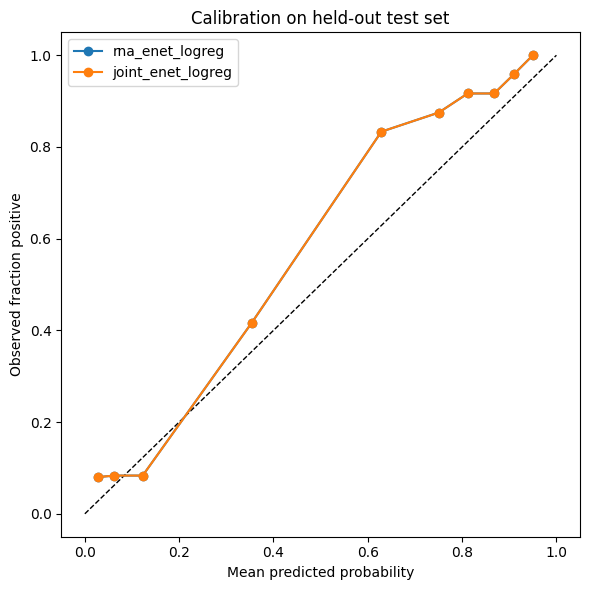

In [20]:
calibration_rows = []
plot_models = [PRIMARY_MODEL_NAME] + ([best_joint_model] if best_joint_model is not None and best_joint_model != PRIMARY_MODEL_NAME else [])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", linewidth=1)

for model_name in plot_models:
    prob = test_prob_store[model_name]
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", label=model_name)
    calibration_rows.append(
        {
            "model_name": model_name,
            "brier_score": brier_score_loss(y_test, prob),
        }
    )

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraction positive")
ax.set_title("Calibration on held-out test set")
ax.legend()
plt.tight_layout()

calibration_df = pd.DataFrame(calibration_rows)
display(calibration_df.round(4))


## 2.16 Task 2 — multiclass TP53 mutation-type prediction (CCLE)

This section completes the second assignment task. It trains a true multiclass classifier on the CCLE TP53 mutation-type label, with WT included as one of the modelling classes. The split is rebuilt specifically for Task 2 and is stratified jointly by **mutation-type label** and **CCLE lineage** so that lineage composition is preserved within each class.

Final CCLE Task 2 classes: `wild_type`, `missense_or_inframe`, `lof_or_splice`. The mapping from these classes to the reference mutation-type categories (Berkeley / EBI / libretexts) is documented in the final defensibility statement at the end of the notebook.

In [21]:
# ============================================================
# Task 2: true multiclass TP53 mutation-type prediction in CCLE
# ============================================================
# Methodological change from the initial completed version:
#   * Task 2 gets its own train/validation/test split.
#   * The split is stratified by TP53 mutation-type label and CCLE lineage together.
#   * Hyperparameter CV also stratifies by the same label-lineage strata when feasible.
#   * Model selection is by validation macro-F1, not by test performance.

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

TASK2_LABEL_COL = "TP53_task2_label"
TASK2_TEST_SIZE = 0.15
TASK2_VAL_SIZE = 0.15

if TASK2_LABEL_COL not in sample_meta.columns:
    if "mut_type" in sample_meta.columns:
        sample_meta[TASK2_LABEL_COL] = sample_meta["mut_type"].astype(str)
    elif "TP53_event_class" in sample_meta.columns:
        sample_meta[TASK2_LABEL_COL] = sample_meta["TP53_event_class"].fillna("wild_type").astype(str)
    else:
        raise ValueError("Cannot construct CCLE Task 2 label: missing mut_type/TP53_event_class.")

# Final CCLE Task 2 classes from the EDA notebook.
task2_labels = ["wild_type", "missense_or_inframe", "lof_or_splice"]

unexpected_task2 = sorted(set(sample_meta[TASK2_LABEL_COL].dropna().astype(str)) - set(task2_labels))
if unexpected_task2:
    raise ValueError(f"Unexpected CCLE Task 2 labels: {unexpected_task2}")

if lineage_col is None or lineage_col not in sample_meta.columns:
    raise ValueError(
        "Task 2 now requires a CCLE lineage column for label-lineage stratification. "
        "Check the EDA schema and sample metadata."
    )


def make_stable_joint_strata(labels, groups, min_count=2, group_name="group"):
    """Create label+group strata, collapsing sparse group-label cells to a rare bucket.

    Stratified splitting fails if any stratum has too few samples. This helper keeps
    common label-lineage strata intact and collapses sparse cells within each label
    into a rare-lineage bucket. If that is still too sparse, it falls back to label-only
    strata and prints an explicit warning.
    """
    labels = pd.Series(labels).astype(str).reset_index(drop=True)
    groups = pd.Series(groups).astype(str).fillna("missing").replace({"nan": "missing"}).reset_index(drop=True)
    joint = labels + "__" + groups
    rare_joint = joint.value_counts().loc[lambda s: s < int(min_count)].index

    groups_collapsed = groups.copy()
    groups_collapsed.loc[joint.isin(rare_joint)] = f"RARE_{group_name.upper()}"
    joint_collapsed = labels + "__" + groups_collapsed

    if joint_collapsed.value_counts().min() < int(min_count):
        print(
            f"Warning: some label-{group_name} strata remain too small for min_count={min_count}; "
            "falling back to label-only stratification for this split/CV object."
        )
        return labels

    return joint_collapsed


def make_task2_lineage_pipeline(meta_col):
    return Pipeline(
        steps=[
            (
                "prep",
                ColumnTransformer(
                    transformers=[
                        ("lineage", make_dense_onehot_encoder(), [meta_col]),
                    ],
                    remainder="drop",
                ),
            ),
            (
                "clf",
                LogisticRegression(
                    max_iter=8000,
                    class_weight="balanced",
                    solver="lbfgs",
                    random_state=RNG,
                ),
            ),
        ]
    )


task2_counts = (
    sample_meta[TASK2_LABEL_COL]
    .value_counts()
    .reindex(task2_labels)
    .rename_axis("TP53_task2_label")
    .to_frame("n")
)

# Task 2 uses all eligible samples but creates a new split that is stratified by
# mutation-type class and lineage. This is preferable to reusing the binary Task 1 split.
y2_all = sample_meta[TASK2_LABEL_COL].astype(str)
task2_all_idx = pd.Index(sample_meta.index[y2_all.isin(task2_labels)], name=sample_meta.index.name)
task2_lineage_all = (
    sample_meta.loc[task2_all_idx, lineage_col]
    .astype(str)
    .fillna("missing")
    .replace({"nan": "missing"})
)

task2_strata_all = make_stable_joint_strata(
    labels=y2_all.loc[task2_all_idx],
    groups=task2_lineage_all,
    min_count=2,
    group_name="lineage",
)

task2_trainval_idx, task2_test_idx = train_test_split(
    task2_all_idx,
    test_size=TASK2_TEST_SIZE,
    random_state=RNG,
    shuffle=True,
    stratify=task2_strata_all,
)

task2_trainval_idx = pd.Index(task2_trainval_idx, name=sample_meta.index.name)
task2_test_idx = pd.Index(task2_test_idx, name=sample_meta.index.name)

task2_trainval_strata = make_stable_joint_strata(
    labels=y2_all.loc[task2_trainval_idx],
    groups=sample_meta.loc[task2_trainval_idx, lineage_col],
    min_count=2,
    group_name="lineage",
)

task2_val_fraction_of_trainval = TASK2_VAL_SIZE / (1.0 - TASK2_TEST_SIZE)
task2_train_idx, task2_val_idx = train_test_split(
    task2_trainval_idx,
    test_size=task2_val_fraction_of_trainval,
    random_state=RNG,
    shuffle=True,
    stratify=task2_trainval_strata,
)

task2_train_idx = pd.Index(task2_train_idx, name=sample_meta.index.name)
task2_val_idx = pd.Index(task2_val_idx, name=sample_meta.index.name)
task2_trainval_idx = task2_train_idx.union(task2_val_idx)

# Feature matrices for Task 2.
X2_train = X_joint.loc[task2_train_idx]
X2_val = X_joint.loc[task2_val_idx]
X2_test = X_joint.loc[task2_test_idx]
X2_trainval = X_joint.loc[task2_trainval_idx]

X2_meta_all = sample_meta[[lineage_col]].copy()
X2_meta_all[lineage_col] = X2_meta_all[lineage_col].astype(str).fillna("missing").replace({"nan": "missing"})
X2_meta_train = X2_meta_all.loc[task2_train_idx]
X2_meta_val = X2_meta_all.loc[task2_val_idx]
X2_meta_test = X2_meta_all.loc[task2_test_idx]
X2_meta_trainval = X2_meta_all.loc[task2_trainval_idx]

y2_train = y2_all.loc[task2_train_idx]
y2_val = y2_all.loc[task2_val_idx]
y2_test = y2_all.loc[task2_test_idx]
y2_trainval = y2_all.loc[task2_trainval_idx]

split_task2_counts = pd.concat(
    {
        "train": y2_train.value_counts().reindex(task2_labels),
        "val": y2_val.value_counts().reindex(task2_labels),
        "test": y2_test.value_counts().reindex(task2_labels),
    },
    axis=1,
).fillna(0).astype(int)

task2_lineage_split_counts = pd.concat(
    {
        "train": X2_meta_train[lineage_col].value_counts(),
        "val": X2_meta_val[lineage_col].value_counts(),
        "test": X2_meta_test[lineage_col].value_counts(),
    },
    axis=1,
).fillna(0).astype(int).sort_values("train", ascending=False)

print("CCLE Task 2 class counts:")
display(task2_counts)
print("CCLE Task 2 split counts using label-lineage stratification:")
display(split_task2_counts)
print("CCLE Task 2 lineage split counts, top 20 lineages:")
display(task2_lineage_split_counts.head(20))


def align_multiclass_proba(estimator, X, labels):
    """Return probability columns aligned to a fixed class order."""
    labels = list(labels)
    if hasattr(estimator, "predict_proba"):
        raw = estimator.predict_proba(X)
        est_classes = list(estimator.classes_)
    elif hasattr(estimator, "decision_function"):
        score = np.asarray(estimator.decision_function(X), dtype=float)
        if score.ndim == 1:
            score = np.column_stack([-score, score])
        score = score - np.nanmax(score, axis=1, keepdims=True)
        exp_score = np.exp(score)
        raw = exp_score / np.clip(exp_score.sum(axis=1, keepdims=True), 1e-12, None)
        est_classes = list(estimator.classes_)
    else:
        pred = estimator.predict(X)
        raw = np.zeros((len(pred), len(labels)), dtype=float)
        est_classes = labels
        for i, p in enumerate(pred):
            if p in labels:
                raw[i, labels.index(p)] = 1.0

    out = np.zeros((raw.shape[0], len(labels)), dtype=float)
    for j, cls in enumerate(labels):
        if cls in est_classes:
            out[:, j] = raw[:, est_classes.index(cls)]
    out = out / np.clip(out.sum(axis=1, keepdims=True), 1e-12, None)
    return out


def evaluate_multiclass(y_true, proba, labels):
    y_true = pd.Series(y_true).astype(str).to_numpy()
    labels = list(labels)
    y_pred = np.asarray(labels, dtype=object)[np.argmax(proba, axis=1)]

    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    try:
        y_bin = label_binarize(y_true, classes=labels)
        out["ovr_auroc_macro"] = roc_auc_score(y_bin, proba, average="macro", multi_class="ovr")
        out["ovr_auprc_macro"] = average_precision_score(y_bin, proba, average="macro")
    except Exception as exc:
        out["ovr_auroc_macro"] = np.nan
        out["ovr_auprc_macro"] = np.nan
        out["auc_note"] = repr(exc)

    return out, y_pred


def multiclass_report_df(y_true, y_pred, labels):
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).T.reset_index().rename(columns={"index": "class"})


class RNAMulticlassKBestFeatureBuilder(BaseEstimator, TransformerMixin):
    """Fold-safe multiclass RNA feature builder using train-fold ANOVA F scores."""

    def __init__(self, rna_cols, k=1000):
        self.rna_cols = rna_cols
        self.k = k

    def fit(self, X, y):
        X_df = self._to_frame(X)
        self.rna_cols_ = list(self.rna_cols)
        X_rna = X_df.loc[:, self.rna_cols_]
        k_eff = min(int(self.k), X_rna.shape[1])

        self.selector_ = SelectKBest(score_func=f_classif, k=k_eff)
        X_selected = self.selector_.fit_transform(X_rna, y)

        self.scaler_ = StandardScaler()
        self.scaler_.fit(X_selected)

        self.selected_genes_ = np.asarray(self.rna_cols_)[self.selector_.get_support()]
        return self

    def transform(self, X):
        X_df = self._to_frame(X)
        X_rna = X_df.loc[:, self.rna_cols_]
        X_selected = self.selector_.transform(X_rna)
        return self.scaler_.transform(X_selected)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.selected_genes_, dtype=object)

    @staticmethod
    def _to_frame(X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("RNAMulticlassKBestFeatureBuilder expects a pandas DataFrame")
        return X


def make_task2_rna_pipeline(clf, rna_cols, k=1000):
    return Pipeline(
        steps=[
            ("features", RNAMulticlassKBestFeatureBuilder(rna_cols=rna_cols, k=k)),
            ("clf", clf),
        ]
    )


task2_cv_n = min(CONFIG["cv_splits"], int(y2_train.value_counts().min()))
task2_cv_strata = make_stable_joint_strata(
    labels=y2_train,
    groups=X2_meta_train[lineage_col],
    min_count=task2_cv_n,
    group_name="lineage",
)
task2_cv = list(
    StratifiedKFold(n_splits=task2_cv_n, shuffle=True, random_state=RNG).split(
        np.zeros(len(y2_train)),
        task2_cv_strata,
    )
)

# Each registry entry declares the feature matrix it uses. Lineage-only is the
# required metadata baseline for checking whether RNA beats lineage composition.
task2_registry = [
    {
        "model_name": "task2_dummy_prior",
        "tier": "baseline",
        "feature_set": "lineage",
        "estimator": DummyClassifier(strategy="prior"),
        "param_grid": {},
    },
    {
        "model_name": "task2_lineage_only_logreg",
        "tier": "metadata_only",
        "feature_set": "lineage",
        "estimator": make_task2_lineage_pipeline(lineage_col),
        "param_grid": {"clf__C": [0.03, 0.1, 0.3, 1.0, 3.0]},
    },
    {
        "model_name": "task2_rna_multinomial_logreg",
        "tier": "mrna",
        "feature_set": "rna",
        "estimator": make_task2_rna_pipeline(
            LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                max_iter=8000,
                class_weight="balanced",
                random_state=RNG,
            ),
            rna_cols=rna_cols,
            k=1000,
        ),
        "param_grid": {
            "features__k": [500, 1000, 2000],
            "clf__C": [0.03, 0.1, 0.3],
            "clf__l1_ratio": [0.0, 0.5],
        },
    },
    {
        "model_name": "task2_rna_linear_svm",
        "tier": "mrna",
        "feature_set": "rna",
        "estimator": make_task2_rna_pipeline(
            SVC(
                kernel="linear",
                probability=True,
                class_weight="balanced",
                random_state=RNG,
            ),
            rna_cols=rna_cols,
            k=1000,
        ),
        "param_grid": {
            "features__k": [500, 1000],
            "clf__C": [0.03, 0.1, 0.3],
        },
    },
]

task2_feature_sets = {
    "rna": {
        "train": X2_train,
        "val": X2_val,
        "test": X2_test,
        "trainval": X2_trainval,
    },
    "lineage": {
        "train": X2_meta_train,
        "val": X2_meta_val,
        "test": X2_meta_test,
        "trainval": X2_meta_trainval,
    },
}

task2_val_rows = []
task2_test_rows = []
task2_best_estimators = {}
task2_best_params = {}

for spec in task2_registry:
    name = spec["model_name"]
    est = clone(spec["estimator"])
    grid = spec["param_grid"]
    feature_set = spec["feature_set"]
    X_fit = task2_feature_sets[feature_set]["train"]

    if len(grid) > 0:
        search = GridSearchCV(
            estimator=est,
            param_grid=grid,
            scoring="f1_macro",
            cv=task2_cv,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X_fit, y2_train)
        best_est = search.best_estimator_
        best_params = search.best_params_
        best_cv = search.best_score_
    else:
        best_est = est.fit(X_fit, y2_train)
        best_params = {}
        best_cv = np.nan

    val_proba = align_multiclass_proba(best_est, task2_feature_sets[feature_set]["val"], task2_labels)
    val_metrics, _ = evaluate_multiclass(y2_val, val_proba, task2_labels)

    task2_val_rows.append(
        {
            "model_name": name,
            "tier": spec["tier"],
            "feature_set": feature_set,
            "cv_best_macro_f1": best_cv,
            "best_params": json.dumps(best_params),
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
    )

    # Refit on train + validation using the selected hyperparameters before the one-time test evaluation.
    refit_est = clone(spec["estimator"])
    if len(best_params) > 0:
        refit_est.set_params(**best_params)
    refit_est.fit(task2_feature_sets[feature_set]["trainval"], y2_trainval)

    test_proba = align_multiclass_proba(refit_est, task2_feature_sets[feature_set]["test"], task2_labels)
    test_metrics, test_pred = evaluate_multiclass(y2_test, test_proba, task2_labels)

    task2_test_rows.append(
        {
            "model_name": name,
            "tier": spec["tier"],
            "feature_set": feature_set,
            "cv_best_macro_f1": best_cv,
            "best_params": json.dumps(best_params),
            **{f"test_{k}": v for k, v in test_metrics.items()},
        }
    )

    task2_best_estimators[name] = refit_est
    task2_best_params[name] = best_params

task2_val_results = pd.DataFrame(task2_val_rows).sort_values(
    "val_macro_f1",
    ascending=False,
).reset_index(drop=True)

task2_validation_order = {name: rank for rank, name in enumerate(task2_val_results["model_name"], start=1)}
task2_test_results = pd.DataFrame(task2_test_rows)
task2_test_results["validation_rank"] = task2_test_results["model_name"].map(task2_validation_order)
task2_test_results = task2_test_results.sort_values("validation_rank").reset_index(drop=True)

display(task2_val_results.round(4))
display(task2_test_results.round(4))

best_task2_name = task2_val_results.iloc[0]["model_name"]
best_task2_feature_set = task2_val_results.iloc[0]["feature_set"]
best_task2_est = task2_best_estimators[best_task2_name]
best_task2_test_proba = align_multiclass_proba(
    best_task2_est,
    task2_feature_sets[best_task2_feature_set]["test"],
    task2_labels,
)
_, best_task2_test_pred = evaluate_multiclass(y2_test, best_task2_test_proba, task2_labels)

task2_confusion = pd.DataFrame(
    confusion_matrix(y2_test, best_task2_test_pred, labels=task2_labels),
    index=[f"true_{x}" for x in task2_labels],
    columns=[f"pred_{x}" for x in task2_labels],
)

task2_report = multiclass_report_df(y2_test, best_task2_test_pred, task2_labels)

print(f"Best CCLE Task 2 model by validation macro-F1: {best_task2_name}")
display(task2_confusion)
display(task2_report.round(4))


CCLE Task 2 class counts:


,n
TP53_task2_label,
wild_type,621
missense_or_inframe,625
lof_or_splice,362


CCLE Task 2 split counts using label-lineage stratification:


,train,val,test
TP53_task2_label,,,
wild_type,434,93,94
missense_or_inframe,435,95,95
lof_or_splice,255,54,53


CCLE Task 2 lineage split counts, top 20 lineages:


...

,model_name,tier,feature_set,cv_best_macro_f1,best_params,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,val_ovr_auroc_macro,val_ovr_auprc_macro
0,task2_rna_multinomial_logreg,mrna,rna,0.7832,"{""clf__C"": 0.03, ""clf__l1_ratio"": 0.5, ""featur...",0.8058,0.7991,0.7964,0.8069,0.9203,0.8285
1,task2_rna_linear_svm,mrna,rna,0.6979,"{""clf__C"": 0.03, ""features__k"": 500}",0.7479,0.7338,0.7345,0.7494,0.8843,0.7874
2,task2_lineage_only_logreg,metadata_only,lineage,0.4814,"{""clf__C"": 0.3}",0.5041,0.5233,0.4901,0.4951,0.7150,0.5110
3,task2_dummy_prior,baseline,lineage,NaN,{},0.3926,0.3333,0.1879,0.2213,0.5000,0.3333


,model_name,tier,feature_set,cv_best_macro_f1,best_params,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,test_ovr_auroc_macro,test_ovr_auprc_macro,validation_rank
0,task2_rna_multinomial_logreg,mrna,rna,0.7832,"{""clf__C"": 0.03, ""clf__l1_ratio"": 0.5, ""featur...",0.7851,0.7778,0.7753,0.7866,0.8981,0.8059,1
1,task2_rna_linear_svm,mrna,rna,0.6979,"{""clf__C"": 0.03, ""features__k"": 500}",0.7479,0.7268,0.7325,0.7482,0.8738,0.7623,2
2,task2_lineage_only_logreg,metadata_only,lineage,0.4814,"{""clf__C"": 0.3}",0.5041,0.5277,0.4880,0.4926,0.7192,0.5194,3
3,task2_dummy_prior,baseline,lineage,NaN,{},0.3926,0.3333,0.1879,0.2213,0.5000,0.3333,4


Best CCLE Task 2 model by validation macro-F1: task2_rna_multinomial_logreg


,pred_wild_type,pred_missense_or_inframe,pred_lof_or_splice
true_wild_type,73,12,9
true_missense_or_inframe,8,78,9
true_lof_or_splice,2,12,39


,class,precision,recall,f1-score,support
0,wild_type,0.8795,0.7766,0.8249,94.0000
1,missense_or_inframe,0.7647,0.8211,0.7919,95.0000
2,lof_or_splice,0.6842,0.7358,0.7091,53.0000
3,accuracy,0.7851,0.7851,0.7851,0.7851
4,macro avg,0.7761,0.7778,0.7753,242.0000
5,weighted avg,0.7917,0.7851,0.7866,242.0000


## 2.17 Part 2 summary (CCLE)

This part covered both required tasks in CCLE. **Task 1** is the binary TP53 nonsynonymous prediction; the primary scientific comparison is mRNA-only vs metadata-only vs mRNA + metadata. **Task 2** is implemented as a true multiclass mutation-type prediction with WT included, using CCLE classes `wild_type`, `missense_or_inframe`, and `lof_or_splice`, and stratified jointly by mutation-type label and CCLE lineage.

Task 1 evidence supports the claim that RNA expression carries TP53-related signal beyond simple lineage metadata, with the lineage-only baseline and lineage-grouped CV providing explicit anti-confounding checks. Task 2 results should be interpreted more cautiously because mutation-type prediction is intrinsically harder and the `lof_or_splice` class is smaller than the other two.

The TCGA replication of both tasks is in Parts 3 and 4.

## 2.18 Save Part 2 outputs

In [22]:
save_df_map = {
    "ccle_mrna_first_validation_results.csv": val_results,
    "ccle_mrna_first_test_results.csv": test_results,
    "ccle_mrna_first_main_comparison.csv": main_comparison,
    "ccle_mrna_first_bootstrap_summary.csv": bootstrap_summary,
    "ccle_mrna_first_primary_coefficients.csv": primary_coef_df,
}

for fname, df in save_df_map.items():
    df.to_csv(PROC / fname, index=False)


if ccle_ablation_table is not None:
    ccle_ablation_table.to_csv(PROC / "ccle_mrna_first_ablation_table.csv", index=False)
if ccle_ablation_table_with_ensemble is not None:
    ccle_ablation_table_with_ensemble.to_csv(PROC / "ccle_mrna_first_ablation_table_with_ensemble.csv", index=False)
if isinstance(ccle_ablation_cv_results, pd.DataFrame) and len(ccle_ablation_cv_results) > 0:
    ccle_ablation_cv_results.to_csv(PROC / "ccle_mrna_first_ablation_cv_results.csv", index=False)
if ccle_final_model_comparison_with_ablations is not None:
    ccle_final_model_comparison_with_ablations.to_csv(PROC / "ccle_mrna_first_final_comparison_with_ablations.csv", index=False)

if joint_coef_df is not None:
    joint_coef_df.to_csv(PROC / "ccle_mrna_first_joint_coefficients.csv", index=False)
if per_lineage_primary is not None and len(per_lineage_primary) > 0:
    per_lineage_primary.to_csv(PROC / "ccle_mrna_first_per_lineage_primary.csv", index=False)
if grouped_cv_folds is not None:
    grouped_cv_folds.to_csv(PROC / "ccle_mrna_first_grouped_cv_folds.csv", index=False)
if grouped_cv_summary is not None:
    grouped_cv_summary.to_csv(PROC / "ccle_mrna_first_grouped_cv_summary.csv")
if outlier_sensitivity is not None:
    outlier_sensitivity.to_csv(PROC / "ccle_mrna_first_outlier_sensitivity.csv", index=False)
if label_sensitivity is not None:
    label_sensitivity.to_csv(PROC / "ccle_mrna_first_label_sensitivity.csv", index=False)
if calibration_df is not None:
    calibration_df.to_csv(PROC / "ccle_mrna_first_calibration.csv", index=False)


# Task 2 outputs are created only after the Task 2 section has run.
if "task2_counts" in globals():
    task2_counts.to_csv(PROC / "ccle_task2_class_counts.csv")
if "split_task2_counts" in globals():
    split_task2_counts.to_csv(PROC / "ccle_task2_split_class_counts.csv")
if "task2_val_results" in globals():
    task2_val_results.to_csv(PROC / "ccle_task2_validation_results.csv", index=False)
if "task2_test_results" in globals():
    task2_test_results.to_csv(PROC / "ccle_task2_test_results.csv", index=False)
if "task2_confusion" in globals():
    task2_confusion.to_csv(PROC / "ccle_task2_confusion_matrix.csv")
if "task2_report" in globals():
    task2_report.to_csv(PROC / "ccle_task2_classification_report.csv", index=False)

final_predictions = pd.DataFrame(index=X_test.index)
final_predictions["y_true"] = y_test
for model_name, prob in test_prob_store.items():
    final_predictions[f"prob__{model_name}"] = prob
save_parquet_with_id(final_predictions, "ccle_mrna_first_test_predictions.parquet")

run_summary = {
    "primary_label": primary_label,
    "primary_model_name": PRIMARY_MODEL_NAME,
    "best_metadata_model": best_meta_model,
    "best_joint_model": best_joint_model,
    "rna_gene_count": len(rna_cols),
    "recommended_meta_cols": recommended_meta_cols,
    "main_models": main_models,
    "has_ablation_table": bool(ccle_ablation_table is not None),
    "has_tp53_event_class": "TP53_event_class" in sample_meta.columns,
    "has_tp53_mut_ambiguous": "TP53_mut_ambiguous" in sample_meta.columns,
    "ambiguous_tp53_n": int(sample_meta["TP53_mut_ambiguous"].sum()) if "TP53_mut_ambiguous" in sample_meta.columns else None,
    "task2_label": TASK2_LABEL_COL if "TASK2_LABEL_COL" in globals() else None,
    "task2_classes": task2_labels if "task2_labels" in globals() else None,
    "best_task2_model": best_task2_name if "best_task2_name" in globals() else None,
}
with open(PROC / "ccle_mrna_first_run_summary.json", "w") as f:
    json.dump(run_summary, f, indent=2)

print("Saved revised mRNA-first modeling artifacts to:", PROC.resolve())


Saved revised mRNA-first modeling artifacts to: /kaggle/working/processed


# Part 3 — TCGA cohort and exploratory data analysis

## Objective

Replicate the project's prediction problem on **TCGA primary tumours** as a second, independent cohort: predict **TP53 nonsynonymous mutation status** from **TCGA RNA expression**, and prepare a multiclass mutation-type label for Task 2.

This part defines a clean, leakage-aware TCGA cohort and identifies the major modelling risks before Part 4 fits the models.

## Goals of Part 3

1. Load and inspect raw TCGA / UCSC Xena RNA, mutation, and phenotype files.
2. Define a sample-level TP53 nonsynonymous mutation label from raw mutation annotations.
3. Use phenotype / sample-derived patient IDs as the canonical patient identifiers.
4. Audit tumour / normal status, cancer-type composition, duplicate patients, and ambiguous TP53 annotations.
5. Define a final modelling cohort matching the assumptions used in Part 4.
6. Check RNA missingness, dimensionality, variance structure, and broad PCA patterns.
7. Identify leakage and confounding risks before modelling.

## Key confounding warning

In pan-cancer TCGA data, **cancer type can strongly confound TP53 prediction** because cancer type affects both TP53 mutation prevalence and RNA expression. Part 4 therefore includes cancer-type baselines and cancer-type-grouped evaluation as explicit anti-confounding checks.

In [1]:
import gzip
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_context("notebook")

RANDOM_STATE = 42
TOP_VAR_GENES_FOR_PCA = 2000

## File discovery

The notebook searches common Kaggle, Colab, local, and sandbox locations for the raw TCGA/Xena files. If your files are somewhere else, add that directory to `SEARCH_ROOTS` or set the paths manually.

In [2]:
SEARCH_ROOTS = [
    Path("/kaggle/input/datasets/cameroncaputa/tp53-prediction"),
    Path("/kaggle/input/tp53-prediction"),
    Path("/kaggle/input"),
    Path("/content"),
    Path("/mnt/data"),
    Path("./data"),
    Path("tp53_completed_notebooks"),
]


def find_first(patterns, roots=SEARCH_ROOTS, required=False):
    tried = []
    for root in roots:
        if not root.exists():
            continue
        for pattern in patterns:
            matches = [p for p in root.rglob(pattern) if p.is_file()]
            if matches:
                return sorted(matches)[0]
            tried.append(f"{root}/**/{pattern}")
    if required:
        raise FileNotFoundError("Could not find any matching file. Tried:\n" + "\n".join(tried))
    return None


RNA_PATH = find_first([
    "tcga_RSEM_gene_tpm",
    "tcga_RSEM_gene_tpm.gz",
    "*tcga_RSEM_gene_tpm*",
], required=True)

MUT_PATH = find_first([
    "mc3.v0.2.8.PUBLIC.xena",
    "mc3.v0.2.8.PUBLIC.xena.gz",
    "*mc3.v0.2.8.PUBLIC.xena*",
    "*mc3*PUBLIC*xena*",
], required=True)

PHENO_PATH = find_first([
    "Survival_SupplementalTable_S1_20171025_xena_sp",
    "Survival_SupplementalTable_S1_20171025_xena",
    "*Survival_SupplementalTable_S1_20171025*xena*",
], required=True)

TP53_TARGETS_PATH = find_first([
    "tp53_target_genes_fischer2017.csv",
    "*tp53_target_genes_fischer2017*.csv",
], required=False)

GENE_ANNOTATION_PATH = find_first([
    "*probeMap*",
    "*gene_annotation*.csv",
    "*gene_annotation*.tsv",
    "*gencode*.csv",
    "*gencode*.tsv",
], required=False)

print("RNA_PATH:", RNA_PATH)
print("MUT_PATH:", MUT_PATH)
print("PHENO_PATH:", PHENO_PATH)
print("TP53_TARGETS_PATH:", TP53_TARGETS_PATH)
print("GENE_ANNOTATION_PATH:", GENE_ANNOTATION_PATH)

RNA_PATH: data/tcga_RSEM_gene_tpm.gz
MUT_PATH: data/mc3.v0.2.8.PUBLIC.xena.gz
PHENO_PATH: data/Survival_SupplementalTable_S1_20171025_xena_sp
TP53_TARGETS_PATH: data/tp53_target_genes_fischer2017.csv
GENE_ANNOTATION_PATH: None


## Helper functions

These functions standardize TCGA sample and patient identifiers and derive tumour/normal sample type from the TCGA barcode.

In [3]:
def sniff_sep(path):
    opener = gzip.open if str(path).endswith(".gz") else open
    with opener(path, "rt", errors="ignore") as f:
        line = f.readline()
    return "	" if line.count("	") >= line.count(",") else ","


def norm_name(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).lower())


def find_col(df, candidates, label, required=True):
    cols = list(df.columns)
    exact = {c.lower(): c for c in cols}
    normalized = {norm_name(c): c for c in cols}
    for cand in candidates:
        if cand.lower() in exact:
            return exact[cand.lower()]
    for cand in candidates:
        nc = norm_name(cand)
        if nc in normalized:
            return normalized[nc]
    if required:
        raise KeyError(f"Could not find {label}. Available columns: {cols}")
    return None


def looks_like_tcga_barcode(x):
    if pd.isna(x):
        return False
    return bool(re.match(r"^TCGA-[A-Za-z0-9]{2}-[A-Za-z0-9]{4}", str(x)))


def looks_like_ensembl(x):
    if pd.isna(x):
        return False
    return bool(re.match(r"^ENSG[0-9]+", str(x)))


def normalize_sample_id(x):
    """Return TCGA sample-level barcode, usually first four barcode fields."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        return "-".join(parts[:4]) if len(parts) >= 4 else s
    return s


def normalize_patient_id(x):
    """Return TCGA patient-level barcode, usually first three barcode fields."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        return "-".join(parts[:3]) if len(parts) >= 3 else s
    return s


def tcga_sample_type_code(barcode):
    """Return TCGA two-digit sample type code from the fourth barcode field."""
    if pd.isna(barcode):
        return np.nan
    s = str(barcode)
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        if len(parts) >= 4 and len(parts[3]) >= 2:
            return parts[3][:2]
    return np.nan


TCGA_SAMPLE_TYPE_MAP = {
    "01": "Primary Solid Tumor",
    "02": "Recurrent Solid Tumor",
    "03": "Primary Blood Derived Cancer - Peripheral Blood",
    "04": "Recurrent Blood Derived Cancer - Bone Marrow",
    "05": "Additional - New Primary",
    "06": "Metastatic",
    "07": "Additional Metastatic",
    "08": "Human Tumor Original Cells",
    "09": "Primary Blood Derived Cancer - Bone Marrow",
    "10": "Blood Derived Normal",
    "11": "Solid Tissue Normal",
    "12": "Buccal Cell Normal",
    "13": "EBV Immortalized Normal",
    "14": "Bone Marrow Normal",
    "20": "Control Analyte",
}

TUMOR_SAMPLE_TYPE_CODES = {"01", "02", "03", "04", "05", "06", "07", "08", "09"}

SAMPLE_PRIORITY = {
    "01": 0,  # primary solid tumour
    "03": 1,
    "06": 2,
    "02": 3,
    "05": 4,
    "07": 5,
    "08": 6,
    "09": 7,
    "04": 8,
}


def tcga_sample_type_label(barcode):
    code = tcga_sample_type_code(barcode)
    return TCGA_SAMPLE_TYPE_MAP.get(code, "Unknown") if pd.notna(code) else np.nan


def is_tcga_tumor_sample(barcode):
    code = tcga_sample_type_code(barcode)
    return code in TUMOR_SAMPLE_TYPE_CODES if pd.notna(code) else False

## Load raw files and inspect schema

In [4]:
RNA_SEP = sniff_sep(RNA_PATH)
MUT_SEP = sniff_sep(MUT_PATH)
PHENO_SEP = sniff_sep(PHENO_PATH)

# Read mutation and phenotype fully. RNA is read fully in the next section because we need expression values for EDA.
mut_raw = pd.read_csv(MUT_PATH, sep=MUT_SEP, low_memory=False, dtype=str)
pheno_raw = pd.read_csv(PHENO_PATH, sep=PHENO_SEP, low_memory=False, dtype=str)
rna_header = pd.read_csv(RNA_PATH, sep=RNA_SEP, nrows=5, low_memory=False)

print("Mutation shape:", mut_raw.shape)
print("Phenotype shape:", pheno_raw.shape)
print("RNA header preview shape:", rna_header.shape)
print("Mutation columns:", mut_raw.columns.tolist()[:30])
print("Phenotype columns:", pheno_raw.columns.tolist()[:30])
print("RNA first columns:", rna_header.columns.tolist()[:8])

display(mut_raw.head())
display(pheno_raw.head())
display(rna_header.head())

Mutation shape: (2907335, 12)
Phenotype shape: (12591, 34)
RNA header preview shape: (5, 10536)
Mutation columns: ['sample', 'chr', 'start', 'end', 'reference', 'alt', 'gene', 'effect', 'Amino_Acid_Change', 'DNA_VAF', 'SIFT', 'PolyPhen']
Phenotype columns: ['sample', '_PATIENT', 'cancer type abbreviation', 'age_at_initial_pathologic_diagnosis', 'gender', 'race', 'ajcc_pathologic_tumor_stage', 'clinical_stage', 'histological_type', 'histological_grade', 'initial_pathologic_dx_year', 'menopause_status', 'birth_days_to', 'vital_status', 'tumor_status', 'last_contact_days_to', 'death_days_to', 'cause_of_death', 'new_tumor_event_type', 'new_tumor_event_site', 'new_tumor_event_site_other', 'new_tumor_event_dx_days_to', 'treatment_outcome_first_course', 'margin_status', 'residual_tumor', 'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI']
RNA first columns: ['sample', 'TCGA-19-1787-01', 'TCGA-S9-A7J2-01', 'TCGA-G3-A3CH-11', 'TCGA-EK-A2RE-01', 'TCGA-44-6778-01', 'TCGA-F4-6854-01', 'TCGA-AB-2863-03']


,sample,chr,start,end,reference,alt,gene,effect,Amino_Acid_Change,DNA_VAF,SIFT,PolyPhen
0,TCGA-02-0003-01,10,123810032,123810032,C,T,TACC2,Missense_Mutation,p.T38M,0.88,NaN,benign(0.335)
1,TCGA-02-0003-01,10,133967449,133967449,C,T,JAKMIP3,Silent,p.D723D,0.79,NaN,NaN
2,TCGA-02-0003-01,11,124489539,124489539,G,A,PANX3,Missense_Mutation,p.R296Q,0.41,tolerated(0.37),benign(0.001)
3,TCGA-02-0003-01,11,47380512,47380512,G,T,SPI1,Missense_Mutation,p.P127T,0.50,tolerated(0.08),benign(0.093)
4,TCGA-02-0003-01,11,89868837,89868837,C,T,NAALAD2,Missense_Mutation,p.R65C,0.51,deleterious(0.01),benign(0.034)


,sample,_PATIENT,cancer type abbreviation,age_at_initial_pathologic_diagnosis,gender,race,ajcc_pathologic_tumor_stage,clinical_stage,histological_type,histological_grade,initial_pathologic_dx_year,menopause_status,birth_days_to,vital_status,tumor_status,last_contact_days_to,death_days_to,cause_of_death,new_tumor_event_type,new_tumor_event_site,new_tumor_event_site_other,new_tumor_event_dx_days_to,treatment_outcome_first_course,margin_status,residual_tumor,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction
0,TCGA-OR-A5J1-01,TCGA-OR-A5J1,ACC,58,MALE,WHITE,Stage II,NaN,Adrenocortical carcinoma- Usual Type,NaN,2000,NaN,-21496,Dead,WITH TUMOR,NaN,1355,NaN,Distant Metastasis,Peritoneal Surfaces,NaN,754,Complete Remission/Response,NaN,NaN,1,1355,1,1355,1,754,1,754,NaN
1,TCGA-OR-A5J2-01,TCGA-OR-A5J2,ACC,44,FEMALE,WHITE,Stage IV,NaN,Adrenocortical carcinoma- Usual Type,NaN,2004,NaN,-16090,Dead,WITH TUMOR,NaN,1677,NaN,Distant Metastasis,Soft Tissue,NaN,289,Progressive Disease,NaN,NaN,1,1677,1,1677,NaN,NaN,1,289,NaN
2,TCGA-OR-A5J3-01,TCGA-OR-A5J3,ACC,23,FEMALE,WHITE,Stage III,NaN,Adrenocortical carcinoma- Usual Type,NaN,2008,NaN,-8624,Alive,WITH TUMOR,2091,NaN,NaN,Distant Metastasis,Lung,NaN,53,Complete Remission/Response,NaN,NaN,0,2091,0,2091,1,53,1,53,NaN
3,TCGA-OR-A5J4-01,TCGA-OR-A5J4,ACC,23,FEMALE,WHITE,Stage IV,NaN,Adrenocortical carcinoma- Usual Type,NaN,2000,NaN,-8451,Dead,WITH TUMOR,NaN,423,NaN,Locoregional Recurrence,Peritoneal Surfaces,NaN,126,Progressive Disease,NaN,NaN,1,423,1,423,NaN,NaN,1,126,NaN
4,TCGA-OR-A5J5-01,TCGA-OR-A5J5,ACC,30,MALE,WHITE,Stage III,NaN,Adrenocortical carcinoma- Usual Type,NaN,2000,NaN,-11171,Dead,WITH TUMOR,NaN,365,NaN,Locoregional Recurrence,"Other, specify",vena cava thrombus,50,Progressive Disease,NaN,NaN,1,365,1,365,NaN,NaN,1,50,NaN


,sample,TCGA-19-1787-01,TCGA-S9-A7J2-01,TCGA-G3-A3CH-11,TCGA-EK-A2RE-01,TCGA-44-6778-01,TCGA-F4-6854-01,TCGA-AB-2863-03,TCGA-C8-A1HL-01,TCGA-EW-A2FS-01,TCGA-IR-A3L7-01,TCGA-05-4420-01,TCGA-R6-A8WC-01,TCGA-DX-A3U8-01,TCGA-GL-8500-01,TCGA-E2-A153-11,TCGA-BR-A4J6-01,TCGA-EJ-7125-01,TCGA-IN-7808-01,TCGA-L5-A4OH-01,TCGA-RP-A695-06,TCGA-AX-A3G6-01,TCGA-B9-A8YH-01,TCGA-E1-A7YI-01,TCGA-PC-A5DM-01,TCGA-BR-A4QL-01,TCGA-CH-5751-01,TCGA-A2-A3XX-01,TCGA-DQ-5624-01,TCGA-KK-A7B3-01,TCGA-DQ-7591-01,TCGA-06-5412-01,TCGA-BP-4989-01,TCGA-EJ-8468-01,TCGA-CZ-5459-01,TCGA-D5-5538-01,TCGA-56-8305-01,TCGA-CZ-5468-11,TCGA-BH-A0BQ-11,TCGA-4X-A9FA-01,TCGA-DD-AAW0-01,TCGA-AA-3511-01,TCGA-Z7-A8R5-01,TCGA-CZ-4863-11,TCGA-39-5031-01,TCGA-ZG-A8QW-01,TCGA-DU-7302-01,TCGA-DJ-A3UX-01,TCGA-ZN-A9VQ-01,TCGA-EI-6512-01,TCGA-J4-A83K-01,TCGA-EE-A17X-06,TCGA-HZ-7922-01,TCGA-DD-AACA-02,TCGA-DD-AACA-01,TCGA-D3-A8GD-06,TCGA-13-1485-01,TCGA-QG-A5YX-01,TCGA-ZG-A9MC-01,TCGA-DU-A7TI-01,TCGA-A3-3335-01,TCGA-BR-8372-01,TCGA-HC-7742-01,TCGA-DD-A3A6-11,TCGA-64-1679-01,TCGA-CV-5976-01,TCGA-25-1315-01,TCGA-2G-AAFZ-01,TCGA-LN-A4MQ-01,TCGA-CV-6948-01,TCGA-K7-AAU7-01,TCGA-CJ-6028-01,TCGA-B6-A0RL-01,TCGA-CZ-5456-01,TCGA-EL-A3D0-01,TCGA-EM-A22Q-01,TCGA-49-6744-01,TCGA-L5-A4ON-01,TCGA-FS-A1ZF-06,TCGA-ZN-A9VU-01,TCGA-Q3-A5QY-01,TCGA-AJ-A3BI-01,TCGA-W2-A7UY-01,TCGA-BH-A204-11,TCGA-E3-A3E2-01,TCGA-FB-A545-01,TCGA-44-2657-11,TCGA-G4-6320-01,TCGA-EB-A41A-01,TCGA-55-6982-01,TCGA-RC-A7SH-01,TCGA-CC-A3MA-01,TCGA-DD-A3A5-11,TCGA-RC-A7SB-01,TCGA-CM-6164-01,TCGA-ET-A3BW-01,TCGA-09-0369-01,TCGA-E2-A2P6-01,TCGA-VD-A8KF-01,TCGA-EL-A4JZ-01,...,TCGA-AB-2833-03,TCGA-EE-A2MF-06,TCGA-D8-A1XR-01,TCGA-50-5072-01,TCGA-AB-2964-03,TCGA-HI-7171-01,TCGA-AR-A0TQ-01,TCGA-G3-A3CG-01,TCGA-BB-7863-01,TCGA-DU-6406-01,TCGA-BR-4255-01,TCGA-AA-3675-01,TCGA-JV-A75J-01,TCGA-DD-A1ED-01,TCGA-BH-A18P-01,TCGA-VD-A8KJ-01,TCGA-A6-6782-01,TCGA-BR-A4CR-01,TCGA-2Y-A9H8-01,TCGA-61-1721-01,TCGA-56-8628-01,TCGA-2Y-A9GT-01,TCGA-EO-A3AZ-01,TCGA-3N-A9WD-06,TCGA-29-1784-01,TCGA-2L-AAQI-01,TCGA-HS-A5N9-01,TCGA-VS-A9UT-01,TCGA-E2-A15O-01,TCGA-50-5045-01,TCGA-DA-A95W-06,TCGA-BP-4332-01,TCGA-AO-A12C-01,TCGA-86-8674-01,TCGA-CZ-5451-11,TCGA-FF-8043-01,TCGA-P3-A5Q5-01,TCGA-N8-A4PQ-01,TCGA-50-8457-01,TCGA-ZJ-AAX8-01,TCGA-OL-A97C-01,TCGA-18-3416-01,TCGA-B8-4146-01,TCGA-AB-2937-03,TCGA-56-7222-11,TCGA-68-7755-01,TCGA-EE-A2GN-06,TCGA-V1-A9ZR-01,TCGA-2J-AABK-01,TCGA-EJ-A6RC-01,TCGA-EL-A3GP-01,TCGA-D9-A4Z6-06,TCGA-E2-A15K-11,TCGA-06-0743-01,TCGA-H2-A3RI-01,TCGA-21-5787-01,TCGA-BJ-A18Z-01,TCGA-D7-A6EX-01,TCGA-TM-A84B-01,TCGA-OR-A5K0-01,TCGA-FY-A4B4-01,TCGA-BH-A18G-01,TCGA-13-0725-01,TCGA-B6-A0IA-01,TCGA-A8-A090-01,TCGA-BB-4217-01,TCGA-5T-A9QA-01,TCGA-TN-A7HJ-01,TCGA-AN-A0XT-01,TCGA-TS-A8AS-01,TCGA-J4-8198-01,TCGA-DU-A76O-01,TCGA-EE-A29L-06,TCGA-4X-A9F9-01,TCGA-C5-A1BJ-01,TCGA-G2-AA3C-01,TCGA-HU-8602-01,TCGA-CR-6470-01,TCGA-CH-5768-01,TCGA-2H-A9GM-01,TCGA-XH-A853-01,TCGA-CM-4751-01,TCGA-AO-A0J4-01,TCGA-55-6985-11,TCGA-YL-A9WK-01,TCGA-77-6844-01,TCGA-IN-AB1X-11,TCGA-A2-A0YK-01,TCGA-18-3414-01,TCGA-13-1481-01,TCGA-DJ-A2QC-01,TCGA-A8-A09K-01,TCGA-61-1907-01,TCGA-IB-7885-01,TCGA-95-7947-01,TCGA-VQ-AA6F-01,TCGA-BR-8588-01,TCGA-24-2254-01,TCGA-DD-A115-01,TCGA-FV-A3I0-11
0,ENSG00000242268.2,-9.9658,0.2998,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-0.6873,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-0.8599,-0.4521,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-4.2934,-3.6259,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-9.9658,-2.5479,-1.2481,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.965800,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-0.6193,-1.3921,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-9.9658,-2.0529,-9.9658,-9.9658,-3.1714,-3.3076,-9.9658,-5.0116,1.0711,-2.1140,-9.9658,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-9.9658,-0.9686,0.1257,-3.4580,-4.2934,-9.9658,-9.9658,-9.9658,-4.6082,-9.9658,-9.9658,-9.9658,-9.9658,-0.4131,-9.9658,-9.9658,-9.9658,-

In [5]:
MUT_SAMPLE_COL = find_col(
    mut_raw,
    ["Tumor_Sample_Barcode", "sample", "sample_id", "SampleID", "ModelID"],
    "mutation sample column",
)
MUT_GENE_COL = find_col(
    mut_raw,
    ["Hugo_Symbol", "HugoSymbol", "gene", "Gene", "symbol"],
    "mutation gene column",
)
MUT_EFFECT_COLS = [
    c for c in [
        find_col(mut_raw, ["Variant_Classification"], "Variant_Classification", required=False),
        find_col(mut_raw, ["VariantInfo"], "VariantInfo", required=False),
        find_col(mut_raw, ["effect"], "effect", required=False),
        find_col(mut_raw, ["Variant_Type"], "Variant_Type", required=False),
        find_col(mut_raw, ["VariantType"], "VariantType", required=False),
        find_col(mut_raw, ["Protein_Change"], "Protein_Change", required=False),
        find_col(mut_raw, ["ProteinChange"], "ProteinChange", required=False),
        find_col(mut_raw, ["Amino_Acid_Change"], "Amino_Acid_Change", required=False),
        find_col(mut_raw, ["Consequence"], "Consequence", required=False),
    ] if c is not None
]
assert len(MUT_EFFECT_COLS) > 0, "Could not find any mutation effect / classification columns."

PHENO_SAMPLE_COL = find_col(
    pheno_raw,
    ["sample", "sample_id", "SampleID", "submitter_id", "Tumor_Sample_Barcode", "ModelID"],
    "phenotype sample column",
)
PHENO_PATIENT_COL = find_col(
    pheno_raw,
    ["_PATIENT", "patient", "patient_id", "PatientID", "case_submitter_id", "participant_id"],
    "phenotype patient column",
    required=False,
)
CANCER_TYPE_COL = find_col(
    pheno_raw,
    ["cancer type abbreviation", "cancer_type_abbreviation", "acronym", "project_id", "OncotreeCode", "primary_disease"],
    "cancer type column",
)

print("Chosen mutation sample column:", MUT_SAMPLE_COL)
print("Chosen mutation gene column:", MUT_GENE_COL)
print("Chosen mutation effect columns:", MUT_EFFECT_COLS)
print("Chosen phenotype sample column:", PHENO_SAMPLE_COL)
print("Chosen phenotype patient column:", PHENO_PATIENT_COL)
print("Chosen cancer type column:", CANCER_TYPE_COL)

Chosen mutation sample column: sample
Chosen mutation gene column: gene
Chosen mutation effect columns: ['effect', 'Amino_Acid_Change']
Chosen phenotype sample column: sample
Chosen phenotype patient column: _PATIENT
Chosen cancer type column: cancer type abbreviation


## Identifier and schema decisions

- RNA matrix orientation is inferred from the header.
- Mutation and phenotype identifiers are standardized to sample-level TCGA barcodes.
- Patient ID should come from the phenotype table when available, falling back to the sample barcode.
- TP53 mutation-derived patient IDs are **not** allowed to overwrite patient IDs for mutation-negative samples.
- Tumour/normal status is derived from the TCGA sample-type code in the fourth barcode field.

## Load RNA expression matrix

The expected Xena RNA layout is usually genes as rows and samples as columns. The code below detects that layout and converts the matrix to samples × genes.

In [6]:
def infer_rna_orientation(header_df):
    cols = list(header_df.columns)
    first_col = cols[0]
    other_cols = cols[1:min(len(cols), 200)]

    first_norm = norm_name(first_col)
    sample_named_first = first_norm in {"sample", "sampleid", "samplebarcode", "submitterid", "modelid"}
    tcga_header_frac = np.mean([looks_like_tcga_barcode(c) for c in other_cols]) if other_cols else 0.0
    ensembl_header_frac = np.mean([looks_like_ensembl(c) for c in other_cols]) if other_cols else 0.0

    if sample_named_first and ensembl_header_frac >= 0.05:
        return "sample_x_gene"
    if tcga_header_frac >= 0.20:
        return "gene_x_sample"
    if sample_named_first:
        return "sample_x_gene"

    preview_first_values = header_df.iloc[:, 0].astype(str).tolist()
    preview_tcga_frac = np.mean([looks_like_tcga_barcode(v) for v in preview_first_values]) if preview_first_values else 0.0
    if preview_tcga_frac >= 0.5 and ensembl_header_frac >= 0.02:
        return "sample_x_gene"

    return "gene_x_sample"


RNA_ORIENTATION = infer_rna_orientation(rna_header)
RNA_FIRST_COL = rna_header.columns[0]

print("Inferred RNA orientation:", RNA_ORIENTATION)
print("RNA first column:", RNA_FIRST_COL)

rna_raw = pd.read_csv(RNA_PATH, sep=RNA_SEP, low_memory=False)

if RNA_ORIENTATION == "gene_x_sample":
    gene_col = rna_raw.columns[0]
    rna_mat = rna_raw.set_index(gene_col).T
    rna_mat.index = rna_mat.index.map(normalize_sample_id)
    rna_mat.index.name = "sample_id"
    rna_mat.columns = rna_mat.columns.astype(str)
else:
    sample_col = rna_raw.columns[0]
    rna_mat = rna_raw.copy()
    rna_mat[sample_col] = rna_mat[sample_col].map(normalize_sample_id)
    rna_mat = rna_mat.set_index(sample_col)
    rna_mat.index.name = "sample_id"
    rna_mat.columns = rna_mat.columns.astype(str)

n_duplicate_rna_samples = int(rna_mat.index.duplicated().sum())
if n_duplicate_rna_samples > 0:
    print(f"Warning: {n_duplicate_rna_samples} duplicate normalized RNA sample IDs. Keeping first occurrence for EDA.")
    rna_mat = rna_mat.loc[~rna_mat.index.duplicated(keep="first")].copy()

# Convert expression values to numeric. Xena TPM matrices are typically already log-scale numeric values.
rna_mat = rna_mat.apply(pd.to_numeric, errors="coerce")

print("RNA matrix shape, samples x genes:", rna_mat.shape)
print("Unique RNA samples:", rna_mat.index.nunique())
print("Duplicated RNA samples after cleanup:", int(rna_mat.index.duplicated().sum()))
print("RNA missing-value fraction:", float(rna_mat.isna().mean().mean()))
display(rna_mat.iloc[:3, :5])

Inferred RNA orientation: gene_x_sample
RNA first column: sample
RNA matrix shape, samples x genes: (10535, 60498)
Unique RNA samples: 10535
Duplicated RNA samples after cleanup: 0
RNA missing-value fraction: 0.0


sample,ENSG00000242268.2,ENSG00000259041.1,ENSG00000270112.3,ENSG00000167578.16,ENSG00000278814.1
sample_id,,,,,
TCGA-19-1787-01,-9.9658,-9.9658,-3.8160,5.2998,-9.9658
TCGA-S9-A7J2-01,0.2998,-9.9658,-3.0469,4.8881,-9.9658
TCGA-G3-A3CH-11,-9.9658,-9.9658,-9.9658,3.5572,-9.9658


,value
n_samples,10535.0
n_genes,60498.0
overall_missing_fraction,0.0
max_sample_missing_fraction,0.0
max_gene_missing_fraction,0.0
duplicated_gene_ids,0.0


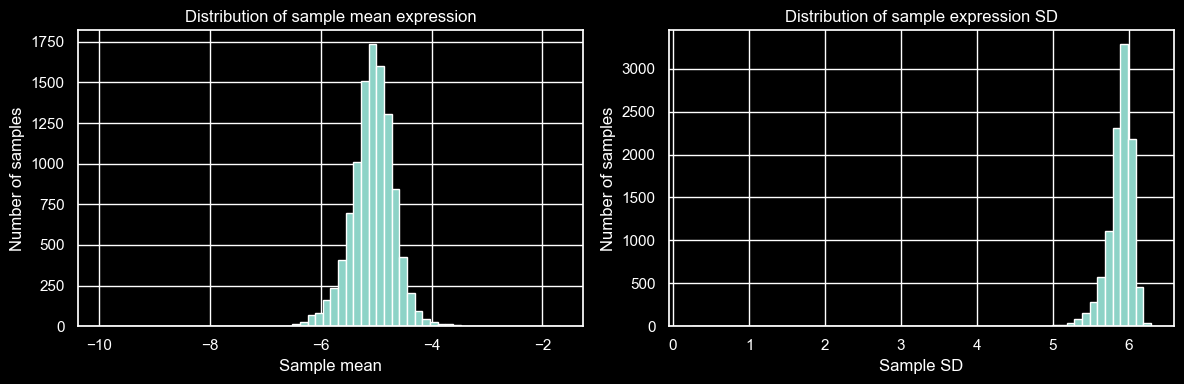

In [7]:
# Basic RNA QC at the matrix level.
sample_missing = rna_mat.isna().mean(axis=1)
gene_missing = rna_mat.isna().mean(axis=0)
sample_means = rna_mat.mean(axis=1)
sample_stds = rna_mat.std(axis=1)

rna_qc_summary = pd.Series({
    "n_samples": rna_mat.shape[0],
    "n_genes": rna_mat.shape[1],
    "overall_missing_fraction": float(rna_mat.isna().mean().mean()),
    "max_sample_missing_fraction": float(sample_missing.max()),
    "max_gene_missing_fraction": float(gene_missing.max()),
    "duplicated_gene_ids": int(pd.Index(rna_mat.columns).duplicated().sum()),
})

display(rna_qc_summary.to_frame("value"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sample_means, bins=60)
axes[0].set_title("Distribution of sample mean expression")
axes[0].set_xlabel("Sample mean")
axes[0].set_ylabel("Number of samples")

axes[1].hist(sample_stds, bins=60)
axes[1].set_title("Distribution of sample expression SD")
axes[1].set_xlabel("Sample SD")
axes[1].set_ylabel("Number of samples")
plt.tight_layout()
plt.show()

## TP53 mutation label construction

The primary label is `TP53_mut_nonsyn`: whether a sample has at least one nonsynonymous / protein-altering TP53 mutation.

This is preferred over using any TP53 row because synonymous and ambiguous TP53 annotations should not be treated as equivalent to protein-altering TP53 mutations.

In [8]:
tp53_rows = mut_raw.loc[mut_raw[MUT_GENE_COL].astype(str).str.upper().eq("TP53")].copy()
tp53_rows["sample_id"] = tp53_rows[MUT_SAMPLE_COL].map(normalize_sample_id)
tp53_rows["patient_id"] = tp53_rows[MUT_SAMPLE_COL].map(normalize_patient_id)

tp53_rows["effect_text"] = (
    tp53_rows[MUT_EFFECT_COLS]
    .fillna("")
    .astype(str)
    .agg(" | ".join, axis=1)
    .str.strip()
)

PROTEIN_ALTERING_KEYWORDS = {
    "missense", "nonsense", "frame_shift", "frameshift", "splice", "stop_gained",
    "stoplost", "stop_lost", "nonstop", "translation_start", "start_codon",
    "inframe", "in_frame", "trunc", "deleterious", "nonsynonymous", "non_synonymous"
}
SYNONYMOUS_KEYWORDS = {"silent", "synonymous"}


def classify_tp53_effect(effect):
    if pd.isna(effect):
        return "unknown"
    e = str(effect).strip().lower()
    if e == "":
        return "unknown"
    if any(k in e for k in SYNONYMOUS_KEYWORDS):
        return "synonymous"
    if "missense" in e:
        return "missense"
    if any(k in e for k in ["nonsense", "stop_gained", "nonstop", "frame_shift", "frameshift", "trunc"]):
        return "truncating"
    if "splice" in e:
        return "splice"
    if "inframe" in e or "in_frame" in e:
        return "inframe"
    if any(k in e for k in PROTEIN_ALTERING_KEYWORDS):
        return "protein_altering"
    return "other_or_unknown"


tp53_rows["tp53_event_class"] = tp53_rows["effect_text"].map(classify_tp53_effect)
tp53_rows["is_tp53_nonsyn"] = tp53_rows["tp53_event_class"].isin(
    ["missense", "truncating", "splice", "inframe", "protein_altering"]
)
tp53_rows["is_tp53_ambiguous"] = tp53_rows["tp53_event_class"].isin(["unknown", "other_or_unknown"])

print("TP53 mutation rows:", len(tp53_rows))
display(tp53_rows[[MUT_SAMPLE_COL, "sample_id", "patient_id", "effect_text", "tp53_event_class"]].head())
display(tp53_rows["tp53_event_class"].value_counts(dropna=False).to_frame("n_rows"))

TP53 mutation rows: 3729


,sample,sample_id,patient_id,effect_text,tp53_event_class
19,TCGA-02-0003-01,TCGA-02-0003-01,TCGA-02-0003,Missense_Mutation | p.R282W,missense
20,TCGA-02-0003-01,TCGA-02-0003-01,TCGA-02-0003,Missense_Mutation | p.H178Q,missense
80,TCGA-02-0033-01,TCGA-02-0033-01,TCGA-02-0033,Missense_Mutation | p.R248Q,missense
211,TCGA-02-0055-01,TCGA-02-0055-01,TCGA-02-0055,Missense_Mutation | p.V216M,missense
363,TCGA-02-2483-01,TCGA-02-2483-01,TCGA-02-2483,Missense_Mutation | p.R273H,missense


,n_rows
tp53_event_class,
missense,2382
truncating,921
splice,238
synonymous,90
inframe,79
other_or_unknown,18
protein_altering,1


In [9]:
tp53_sample = (
    tp53_rows.groupby("sample_id", dropna=True)
    .agg(
        patient_id=("patient_id", "first"),
        n_tp53_rows=("sample_id", "size"),
        has_any_tp53_row=("sample_id", lambda x: True),
        has_any_tp53_nonsyn=("is_tp53_nonsyn", "max"),
        has_any_tp53_ambiguous=("is_tp53_ambiguous", "max"),
        n_unique_tp53_event_classes=("tp53_event_class", "nunique"),
        example_effects=("effect_text", lambda x: "; ".join(pd.Series(x).dropna().astype(str).unique()[:5])),
    )
    .reset_index()
)

tp53_sample["TP53_mut_nonsyn"] = tp53_sample["has_any_tp53_nonsyn"].astype(int)
tp53_sample["TP53_mut_ambiguous"] = tp53_sample["has_any_tp53_ambiguous"].astype(int)
tp53_sample["has_mixed_tp53_annotation"] = (
    tp53_sample["has_any_tp53_nonsyn"] & tp53_sample["has_any_tp53_ambiguous"]
).astype(int)

print("Samples with any TP53 mutation row:", len(tp53_sample))
display(tp53_sample.head())
display(tp53_sample[["TP53_mut_nonsyn", "TP53_mut_ambiguous", "has_mixed_tp53_annotation"]].sum().to_frame("n_samples"))
display(tp53_sample[["TP53_mut_nonsyn", "TP53_mut_ambiguous", "has_mixed_tp53_annotation"]].mean().to_frame("fraction_among_tp53_row_samples"))

Samples with any TP53 mutation row: 3325


,sample_id,patient_id,n_tp53_rows,has_any_tp53_row,has_any_tp53_nonsyn,has_any_tp53_ambiguous,n_unique_tp53_event_classes,example_effects,TP53_mut_nonsyn,TP53_mut_ambiguous,has_mixed_tp53_annotation
0,TCGA-02-0003-01,TCGA-02-0003,2,True,True,False,1,Missense_Mutation | p.R282W; Missense_Mutation...,1,0,0
1,TCGA-02-0033-01,TCGA-02-0033,1,True,True,False,1,Missense_Mutation | p.R248Q,1,0,0
2,TCGA-02-0055-01,TCGA-02-0055,1,True,True,False,1,Missense_Mutation | p.V216M,1,0,0
3,TCGA-02-2483-01,TCGA-02-2483,1,True,True,False,1,Missense_Mutation | p.R273H,1,0,0
4,TCGA-02-2485-01,TCGA-02-2485,2,True,True,False,1,Missense_Mutation | p.R248Q; Missense_Mutation...,1,0,0


,n_samples
TP53_mut_nonsyn,3270
TP53_mut_ambiguous,18
has_mixed_tp53_annotation,8


,fraction_among_tp53_row_samples
TP53_mut_nonsyn,0.983459
TP53_mut_ambiguous,0.005414
has_mixed_tp53_annotation,0.002406


In [10]:
# Task 2 sample-level mutation-type label audit.
# A sample may have more than one TP53 row, so choose a primary event by biological severity.
TCGA_TASK2_PRIORITY = {
    "truncating": 7,
    "splice": 6,
    "missense": 5,
    "inframe": 4,
    "protein_altering": 3,
    "synonymous": 2,
    "other_or_unknown": 1,
    "unknown": 0,
}

tp53_rows["task2_priority"] = (
    tp53_rows["tp53_event_class"]
    .map(TCGA_TASK2_PRIORITY)
    .fillna(0)
    .astype(int)
)

tp53_primary_event = (
    tp53_rows
    .sort_values(["sample_id", "task2_priority"], ascending=[True, False])
    .drop_duplicates("sample_id")
    .set_index("sample_id")["tp53_event_class"]
    .rename("tp53_primary_event_class")
)

tp53_nonsyn_class_count = (
    tp53_rows.loc[tp53_rows["is_tp53_nonsyn"]]
    .groupby("sample_id")["tp53_event_class"]
    .nunique()
    .rename("n_unique_tp53_nonsyn_event_classes")
)

tp53_sample = tp53_sample.merge(
    tp53_primary_event.reset_index(),
    on="sample_id",
    how="left",
)

tp53_sample = tp53_sample.merge(
    tp53_nonsyn_class_count.reset_index(),
    on="sample_id",
    how="left",
    suffixes=("", "_nonsyn_only"),
)

if "n_unique_tp53_nonsyn_event_classes_nonsyn_only" in tp53_sample.columns:
    tp53_sample["n_unique_tp53_nonsyn_event_classes"] = tp53_sample[
        "n_unique_tp53_nonsyn_event_classes_nonsyn_only"
    ].fillna(0).astype(int)
    tp53_sample = tp53_sample.drop(columns=["n_unique_tp53_nonsyn_event_classes_nonsyn_only"])

print("Sample-level primary TP53 event classes before final cohort filtering:")
display(tp53_primary_event.value_counts().rename_axis("tp53_primary_event_class").to_frame("n_samples"))


Sample-level primary TP53 event classes before final cohort filtering:


,n_samples
tp53_primary_event_class,
missense,2069
truncating,900
splice,230
inframe,71
synonymous,45
other_or_unknown,10


## Phenotype setup

This is the key fix relative to the earlier EDA: patient IDs come from phenotype/sample information, not from the TP53 mutation table. If patient ID were taken only from TP53 mutation rows, most TP53-wild-type samples would incorrectly appear to have missing patient IDs.

In [11]:
pheno = pheno_raw.copy()
pheno["sample_id"] = pheno[PHENO_SAMPLE_COL].map(normalize_sample_id)

if PHENO_PATIENT_COL is not None:
    pheno["patient_id"] = pheno[PHENO_PATIENT_COL].where(
        pheno[PHENO_PATIENT_COL].notna(),
        pheno["sample_id"].map(normalize_patient_id),
    )
else:
    pheno["patient_id"] = pheno["sample_id"].map(normalize_patient_id)

pheno["patient_id"] = pheno["patient_id"].fillna(pheno["sample_id"].map(normalize_patient_id))
pheno["sample_type_code"] = pheno["sample_id"].map(tcga_sample_type_code)
pheno["sample_type_label"] = pheno["sample_id"].map(tcga_sample_type_label)
pheno["is_tumor_sample"] = pheno["sample_id"].map(is_tcga_tumor_sample)

# Prevent row multiplication during merge.
pheno = pheno.sort_values(["sample_id", "patient_id"]).drop_duplicates(subset="sample_id", keep="first").copy()

print("Phenotype rows after sample-level dedup:", len(pheno))
print("Unique phenotype samples:", pheno["sample_id"].nunique())
print("Unique phenotype patients:", pheno["patient_id"].nunique())
print("Missing patient IDs:", int(pheno["patient_id"].isna().sum()))
print("Missing cancer type:", int(pheno[CANCER_TYPE_COL].isna().sum()))

display(
    pheno[[
        PHENO_SAMPLE_COL,
        "sample_id",
        "patient_id",
        "sample_type_code",
        "sample_type_label",
        "is_tumor_sample",
        CANCER_TYPE_COL,
    ]].head()
)

display(pheno["sample_type_label"].value_counts(dropna=False).to_frame("n_samples"))

Phenotype rows after sample-level dedup: 12591
Unique phenotype samples: 12591
Unique phenotype patients: 11081
Missing patient IDs: 0
Missing cancer type: 0


,sample,sample_id,patient_id,sample_type_code,sample_type_label,is_tumor_sample,cancer type abbreviation
2918,TCGA-02-0001-01,TCGA-02-0001-01,TCGA-02-0001,01,Primary Solid Tumor,True,GBM
2919,TCGA-02-0003-01,TCGA-02-0003-01,TCGA-02-0003,01,Primary Solid Tumor,True,GBM
2920,TCGA-02-0006-01,TCGA-02-0006-01,TCGA-02-0006,01,Primary Solid Tumor,True,GBM
2921,TCGA-02-0007-01,TCGA-02-0007-01,TCGA-02-0007,01,Primary Solid Tumor,True,GBM
2922,TCGA-02-0009-01,TCGA-02-0009-01,TCGA-02-0009,01,Primary Solid Tumor,True,GBM


,n_samples
sample_type_label,
Primary Solid Tumor,10517
Solid Tissue Normal,1413
Metastatic,395
Primary Blood Derived Cancer - Peripheral Blood,200
Recurrent Solid Tumor,55
Additional - New Primary,10
Additional Metastatic,1


## Build raw merged sample-level table

The raw merged table starts from RNA-available samples, merges phenotype metadata, and then merges TP53 labels. It is intentionally metadata-only; expression values remain in `rna_mat` to avoid duplicating a very large RNA matrix.

In [12]:
rna_index_df = pd.DataFrame({"sample_id": rna_mat.index})

tp53_for_merge = tp53_sample.rename(columns={"patient_id": "patient_id_tp53"}).copy()

metadata_cols = [
    "sample_id",
    "patient_id",
    "sample_type_code",
    "sample_type_label",
    "is_tumor_sample",
    CANCER_TYPE_COL,
]

optional_cols = [
    "age_at_initial_pathologic_diagnosis",
    "gender",
    "ajcc_pathologic_tumor_stage",
    "clinical_stage",
    "histological_type",
    "histological_grade",
]
metadata_cols += [c for c in optional_cols if c in pheno.columns]

merged = (
    rna_index_df
    .merge(pheno[metadata_cols], on="sample_id", how="left")
    .merge(tp53_for_merge, on="sample_id", how="left")
)

# Backfill from TP53-derived patient ID only if phenotype/sample-derived patient ID is missing.
if "patient_id_tp53" in merged.columns:
    merged["patient_id"] = merged["patient_id"].fillna(merged["patient_id_tp53"])

merged["TP53_mut_nonsyn"] = merged["TP53_mut_nonsyn"].fillna(0).astype(int)
merged["TP53_mut_ambiguous"] = merged["TP53_mut_ambiguous"].fillna(0).astype(int)
merged["has_any_tp53_row"] = merged["has_any_tp53_row"].fillna(False).astype(bool)
merged["has_mixed_tp53_annotation"] = merged["has_mixed_tp53_annotation"].fillna(0).astype(int)

print("Merged metadata shape:", merged.shape)
print("Rows:", len(merged))
print("Unique samples:", merged["sample_id"].nunique())
print("Unique patients:", merged["patient_id"].nunique())
print("Missing patient IDs:", int(merged["patient_id"].isna().sum()))
print("Missing cancer type:", int(merged[CANCER_TYPE_COL].isna().sum()))

display(
    merged[[
        "sample_id",
        "patient_id",
        "sample_type_code",
        "sample_type_label",
        "is_tumor_sample",
        CANCER_TYPE_COL,
        "TP53_mut_nonsyn",
        "TP53_mut_ambiguous",
        "has_mixed_tp53_annotation",
    ]].head()
)

Merged metadata shape: (10535, 24)
Rows: 10535
Unique samples: 10535
Unique patients: 9747
Missing patient IDs: 35
Missing cancer type: 39


,sample_id,patient_id,sample_type_code,sample_type_label,is_tumor_sample,cancer type abbreviation,TP53_mut_nonsyn,TP53_mut_ambiguous,has_mixed_tp53_annotation
0,TCGA-19-1787-01,TCGA-19-1787,01,Primary Solid Tumor,True,GBM,1,0,0
1,TCGA-S9-A7J2-01,TCGA-S9-A7J2,01,Primary Solid Tumor,True,LGG,0,0,0
2,TCGA-G3-A3CH-11,TCGA-G3-A3CH,11,Solid Tissue Normal,False,LIHC,0,0,0
3,TCGA-EK-A2RE-01,TCGA-EK-A2RE,01,Primary Solid Tumor,True,CESC,0,0,0
4,TCGA-44-6778-01,TCGA-44-6778,01,Primary Solid Tumor,True,LUAD,1,0,0


## Raw cohort audit

This audit describes the RNA-available merged table before final modelling filters. The final modelling cohort is stricter and is defined in the next section.

In [13]:
cohort_audit = pd.Series({
    "rows": len(merged),
    "unique_sample_ids": merged["sample_id"].nunique(),
    "duplicated_sample_ids": int(merged["sample_id"].duplicated().sum()),
    "unique_patient_ids": merged["patient_id"].nunique(),
    "missing_patient_ids": int(merged["patient_id"].isna().sum()),
    "patients_with_multiple_samples": int((merged["patient_id"].value_counts() > 1).sum()),
    "missing_cancer_type": int(merged[CANCER_TYPE_COL].isna().sum()),
    "tumor_samples": int(merged["is_tumor_sample"].fillna(False).sum()),
    "non_tumor_or_unknown_samples": int((~merged["is_tumor_sample"].fillna(False)).sum()),
    "tp53_nonsyn_positive": int(merged["TP53_mut_nonsyn"].sum()),
    "tp53_nonsyn_rate": float(merged["TP53_mut_nonsyn"].mean()),
    "tp53_ambiguous_samples": int(merged["TP53_mut_ambiguous"].sum()),
    "mixed_tp53_annotation_samples": int(merged["has_mixed_tp53_annotation"].sum()),
})

display(cohort_audit.to_frame("value"))
display(merged["sample_type_label"].value_counts(dropna=False).to_frame("n_samples"))
display(merged[CANCER_TYPE_COL].value_counts(dropna=False).head(40).to_frame("n_samples"))

,value
rows,10535.000000
unique_sample_ids,10535.000000
duplicated_sample_ids,0.000000
unique_patient_ids,9747.000000
missing_patient_ids,35.000000
patients_with_multiple_samples,749.000000
missing_cancer_type,39.000000
tumor_samples,9784.000000
non_tumor_or_unknown_samples,-20319.000000
tp53_nonsyn_positive,3033.000000


,n_samples
sample_type_label,
Primary Solid Tumor,9164
Solid Tissue Normal,712
Metastatic,392
Primary Blood Derived Cancer - Peripheral Blood,173
Recurrent Solid Tumor,44
NaN,39
Additional - New Primary,10
Additional Metastatic,1


,n_samples
cancer type abbreviation,
BRCA,1211
KIRC,603
LUAD,574
THCA,571
HNSC,564
PRAD,548
LUSC,548
LGG,522
SKCM,470


## Final modelling cohort definition

For modelling, use a stricter cohort than the raw merged EDA table.

Rules:

1. Keep samples present in the RNA matrix.
2. Keep tumour samples only, based on TCGA sample-type code.
3. Exclude samples with missing cancer type.
4. Exclude samples with ambiguous or mixed TP53 annotation.
5. Keep one sample per patient to prevent patient-level leakage.
6. Prefer primary tumour samples when a patient has multiple retained tumour samples.

This cohort definition should match the TCGA modelling notebook. Supervised gene filtering and model fitting should still happen only after train/test splitting.

In [14]:
model_eda = merged.copy()

# Rule 1: RNA-present samples are already represented because merged starts from rna_mat.index.
# Rule 2: tumour-only.
model_eda = model_eda.loc[model_eda["is_tumor_sample"].fillna(False)].copy()

# Rule 3: require cancer type.
model_eda = model_eda.loc[model_eda[CANCER_TYPE_COL].notna()].copy()

# Rule 4: exclude ambiguous or mixed TP53 labels.
model_eda = model_eda.loc[
    (model_eda["TP53_mut_ambiguous"] == 0)
    & (model_eda["has_mixed_tp53_annotation"] == 0)
].copy()

# Rule 5/6: one sample per patient, preferring primary tumour samples.
pre_dedup_n = len(model_eda)
pre_dedup_multi_patient_counts = (
    model_eda["patient_id"]
    .value_counts()
    .loc[lambda s: s > 1]
    .sort_values(ascending=False)
)

model_eda["sample_priority"] = model_eda["sample_type_code"].map(SAMPLE_PRIORITY).fillna(99)
model_eda = (
    model_eda
    .sort_values(["patient_id", "sample_priority", "sample_id"])
    .drop_duplicates(subset="patient_id", keep="first")
    .reset_index(drop=True)
)

final_cohort_summary = pd.Series({
    "n_samples": len(model_eda),
    "n_unique_samples": model_eda["sample_id"].nunique(),
    "n_unique_patients": model_eda["patient_id"].nunique(),
    "tp53_nonsyn_positive": int(model_eda["TP53_mut_nonsyn"].sum()),
    "tp53_nonsyn_negative": int((model_eda["TP53_mut_nonsyn"] == 0).sum()),
    "tp53_prevalence": float(model_eda["TP53_mut_nonsyn"].mean()),
    "n_cancer_types": model_eda[CANCER_TYPE_COL].nunique(),
    "rows_before_patient_dedup": pre_dedup_n,
    "patients_with_multiple_samples_before_dedup": len(pre_dedup_multi_patient_counts),
})

display(final_cohort_summary.to_frame("value"))
print("Patients with multiple retained samples before dedup:", len(pre_dedup_multi_patient_counts))
display(pre_dedup_multi_patient_counts.head(10).to_frame("n_samples"))

assert model_eda["patient_id"].isna().sum() == 0, "Patient IDs must be present."
assert model_eda["patient_id"].nunique() == len(model_eda), "Exactly one sample per patient should remain."
assert model_eda["sample_id"].nunique() == len(model_eda), "Exactly one row per sample should remain."
assert set(model_eda["TP53_mut_nonsyn"].unique()).issubset({0, 1}), "Target must be binary."

print("Clean EDA cohort passes patient/sample leakage-sensitive checks.")

,value
n_samples,9695.000000
n_unique_samples,9695.000000
n_unique_patients,9695.000000
tp53_nonsyn_positive,3021.000000
tp53_nonsyn_negative,6674.000000
tp53_prevalence,0.311604
n_cancer_types,33.000000
rows_before_patient_dedup,9767.000000
patients_with_multiple_samples_before_dedup,71.000000


Patients with multiple retained samples before dedup: 71


,n_samples
patient_id,
TCGA-SR-A6MX,3
TCGA-ER-A2NF,2
TCGA-50-5066,2
TCGA-J8-A4HW,2
TCGA-13-1489,2
TCGA-2G-AAGY,2
TCGA-J8-A3YH,2
TCGA-2G-AAHP,2
TCGA-DU-6407,2


Clean EDA cohort passes patient/sample leakage-sensitive checks.


## Class balance in the final clean cohort

,value
n_samples,9695.000000
n_tp53_nonsyn,3021.000000
n_tp53_wildtype_or_no_nonsyn,6674.000000
tp53_nonsyn_rate,0.311604


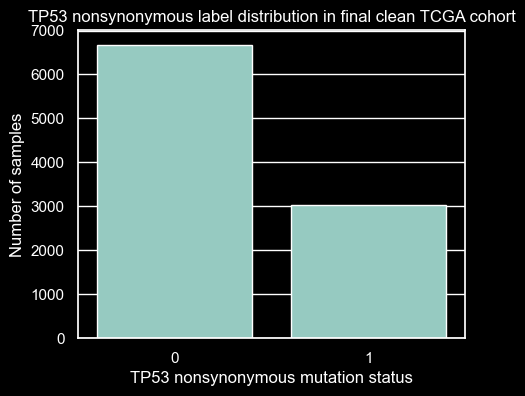

In [15]:
label_summary_clean = pd.Series({
    "n_samples": len(model_eda),
    "n_tp53_nonsyn": int(model_eda["TP53_mut_nonsyn"].sum()),
    "n_tp53_wildtype_or_no_nonsyn": int((model_eda["TP53_mut_nonsyn"] == 0).sum()),
    "tp53_nonsyn_rate": float(model_eda["TP53_mut_nonsyn"].mean()),
})

display(label_summary_clean.to_frame("value"))

plt.figure(figsize=(5, 4))
sns.countplot(data=model_eda, x="TP53_mut_nonsyn")
plt.title("TP53 nonsynonymous label distribution in final clean TCGA cohort")
plt.xlabel("TP53 nonsynonymous mutation status")
plt.ylabel("Number of samples")
plt.show()

In [16]:
# Task 2 label design in the final clean TCGA cohort.
def collapse_tcga_task2_label(raw_class):
    if pd.isna(raw_class):
        return "WT"
    if raw_class == "missense":
        return "missense"
    if raw_class in {"truncating", "splice"}:
        return "truncating_or_splice"
    if raw_class in {"inframe", "protein_altering"}:
        return "rare_protein_altering_excluded"
    if raw_class == "synonymous":
        return "synonymous_excluded"
    return "ambiguous_excluded"

model_eda["TP53_task2_raw"] = model_eda["tp53_primary_event_class"].fillna("WT")
model_eda["TP53_task2_label"] = model_eda["tp53_primary_event_class"].map(collapse_tcga_task2_label)

tcga_task2_raw_counts = (
    model_eda["TP53_task2_raw"]
    .value_counts(dropna=False)
    .rename_axis("TP53_task2_raw")
    .to_frame("n_final_clean_cohort")
)

tcga_task2_collapsed_counts = (
    model_eda["TP53_task2_label"]
    .value_counts(dropna=False)
    .rename_axis("TP53_task2_label")
    .to_frame("n_final_clean_cohort")
)

print("Raw Task 2 classes in the final clean cohort:")
display(tcga_task2_raw_counts)
print("Collapsed/excluded Task 2 classes for modeling:")
display(tcga_task2_collapsed_counts)


Raw Task 2 classes in the final clean cohort:


,n_final_clean_cohort
TP53_task2_raw,
WT,6636
missense,1898
truncating,841
splice,216
inframe,66
synonymous,38


Collapsed/excluded Task 2 classes for modeling:


,n_final_clean_cohort
TP53_task2_label,
WT,6636
missense,1898
truncating_or_splice,1057
rare_protein_altering_excluded,66
synonymous_excluded,38


## Cancer-type composition and TP53 prevalence

This section checks whether cancer type is likely to confound pan-cancer TP53 prediction.

,n_samples,tp53_rate,n_tp53
cancer type abbreviation,,,
BRCA,1090,0.239450,261
KIRC,530,0.020755,11
HNSC,518,0.677606,351
LUAD,513,0.500975,257
LGG,510,0.472549,241
THCA,504,0.005952,3
PRAD,495,0.117172,58
LUSC,495,0.795960,394
SKCM,464,0.146552,68


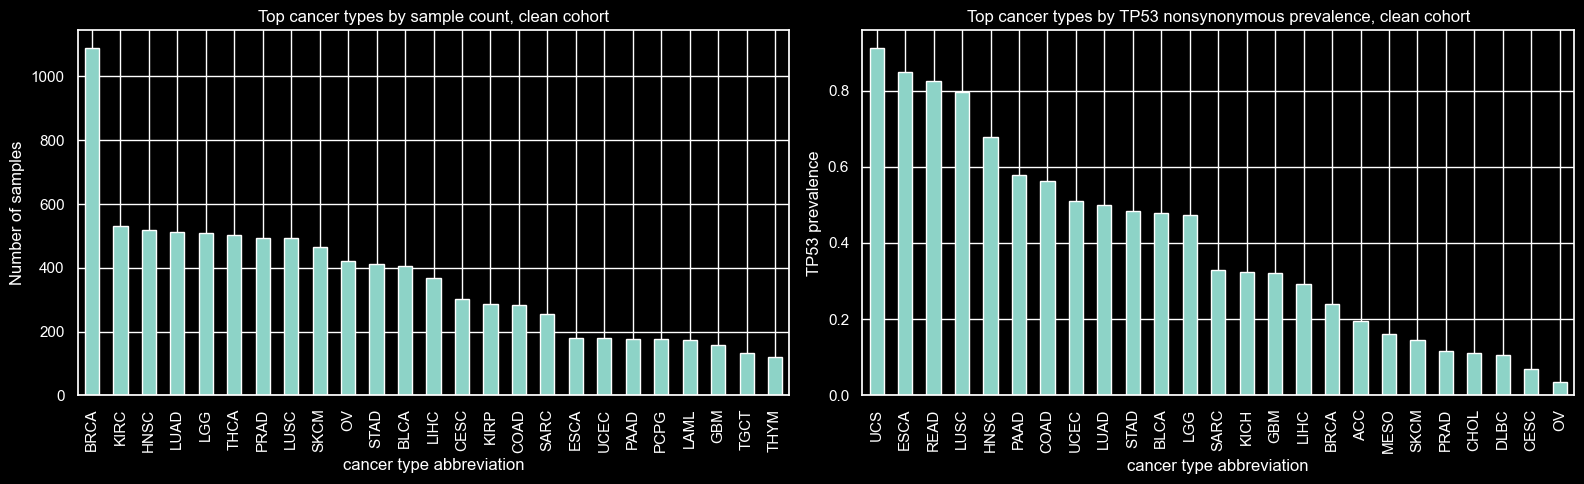

In [17]:
cancer_stats_clean = (
    model_eda
    .groupby(CANCER_TYPE_COL)
    .agg(
        n_samples=("sample_id", "size"),
        tp53_rate=("TP53_mut_nonsyn", "mean"),
        n_tp53=("TP53_mut_nonsyn", "sum"),
    )
    .sort_values("n_samples", ascending=False)
)

display(cancer_stats_clean)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cancer_stats_clean["n_samples"].sort_values(ascending=False).head(25).plot(
    kind="bar",
    ax=axes[0],
)
axes[0].set_title("Top cancer types by sample count, clean cohort")
axes[0].set_ylabel("Number of samples")

cancer_stats_clean["tp53_rate"].sort_values(ascending=False).head(25).plot(
    kind="bar",
    ax=axes[1],
)
axes[1].set_title("Top cancer types by TP53 nonsynonymous prevalence, clean cohort")
axes[1].set_ylabel("TP53 prevalence")

plt.tight_layout()
plt.show()

### Cancer-type interpretation

If TP53 prevalence differs strongly across cancer types, then random pan-cancer train/test splits may overestimate performance because train and test contain similar cancer-type mixtures. The modelling notebook should therefore include:

- a dummy prior baseline;
- a cancer-type-only baseline;
- an RNA-only model;
- an RNA + cancer-type model;
- cancer-type-grouped evaluation.

## Metadata missingness

In [18]:
metadata_cols_to_check = [
    "sample_id",
    "patient_id",
    "sample_type_code",
    "sample_type_label",
    "is_tumor_sample",
    CANCER_TYPE_COL,
    "TP53_mut_nonsyn",
    "TP53_mut_ambiguous",
    "has_mixed_tp53_annotation",
]

metadata_missing_raw = (
    merged[metadata_cols_to_check]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

metadata_missing_clean = (
    model_eda[metadata_cols_to_check]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

display(metadata_missing_raw.to_frame("missing_fraction_raw_merged"))
display(metadata_missing_clean.to_frame("missing_fraction_clean_cohort"))

,missing_fraction_raw_merged
sample_type_code,0.003702
sample_type_label,0.003702
is_tumor_sample,0.003702
cancer type abbreviation,0.003702
patient_id,0.003322
sample_id,0.000000
TP53_mut_nonsyn,0.000000
TP53_mut_ambiguous,0.000000
has_mixed_tp53_annotation,0.000000


,missing_fraction_clean_cohort
sample_id,0.0
patient_id,0.0
sample_type_code,0.0
sample_type_label,0.0
is_tumor_sample,0.0
cancer type abbreviation,0.0
TP53_mut_nonsyn,0.0
TP53_mut_ambiguous,0.0
has_mixed_tp53_annotation,0.0


## RNA expression structure in the final clean cohort

Expression matrix for clean cohort: (9695, 60498)
RNA feature count: 60498
Overall missing fraction: 0.0


,gene_variance
count,6.049800e+04
mean,4.722314e+00
std,5.744385e+00
min,3.155769e-30
25%,5.754346e-01
50%,2.300550e+00
75%,7.395137e+00
max,7.471875e+01


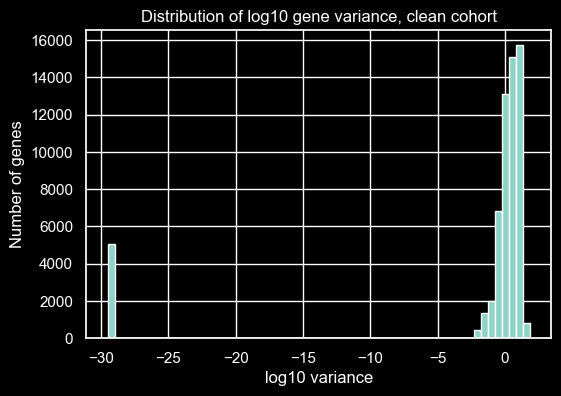

,n_genes
genes_with_variance_le_1e-06,5069
genes_with_variance_le_0.0001,5069
genes_with_variance_le_0.001,5069
genes_with_variance_le_0.01,5152


In [19]:
# Align expression matrix to the final clean cohort without duplicating expression columns in the metadata table.
model_sample_ids = model_eda["sample_id"].tolist()
expr_clean = rna_mat.reindex(model_sample_ids)
expr_clean.index = model_eda.index

assert expr_clean.shape[0] == len(model_eda)
assert expr_clean.isna().mean().mean() < 0.05, "Unexpectedly high expression missingness."

gene_cols = expr_clean.columns.tolist()
print("Expression matrix for clean cohort:", expr_clean.shape)
print("RNA feature count:", expr_clean.shape[1])
print("Overall missing fraction:", float(expr_clean.isna().mean().mean()))

gene_var = expr_clean.var(axis=0)
display(gene_var.describe().to_frame("gene_variance"))

plt.figure(figsize=(6, 4))
plt.hist(np.log10(gene_var.replace(0, np.nan).dropna()), bins=60)
plt.title("Distribution of log10 gene variance, clean cohort")
plt.xlabel("log10 variance")
plt.ylabel("Number of genes")
plt.show()

var_thresholds = [1e-6, 1e-4, 1e-3, 1e-2]
variance_filter_summary = pd.Series({
    f"genes_with_variance_le_{thr}": int((gene_var <= thr).sum())
    for thr in var_thresholds
})
display(variance_filter_summary.to_frame("n_genes"))

### RNA dimensionality conclusion

The RNA matrix is very high-dimensional relative to sample size. Dimensionality reduction, variance filtering, and supervised feature selection may be useful, but any supervised feature selection must be done inside training/CV folds in the modelling notebook.

## PCA on high-variance genes

This PCA is descriptive only. It should not be used for final model selection.

,PC1,PC2,PC3,PC4,PC5,TP53_mut_nonsyn,cancer type abbreviation
0,-23.974610,-12.993731,16.763394,1.464457,15.430758,0,GBM
1,-13.955581,-9.764000,8.333843,2.167282,7.339569,1,GBM
2,-27.915882,-13.068982,10.830295,-0.607605,7.360339,1,GBM
3,-27.821417,-10.905898,15.626859,-0.199058,10.497874,1,GBM
4,-0.123688,-4.954301,12.515860,-2.890930,-7.257321,0,OV


Explained variance ratio, first 5 PCs: [0.11453342 0.05620332 0.04338733 0.04042788 0.0339232 ]


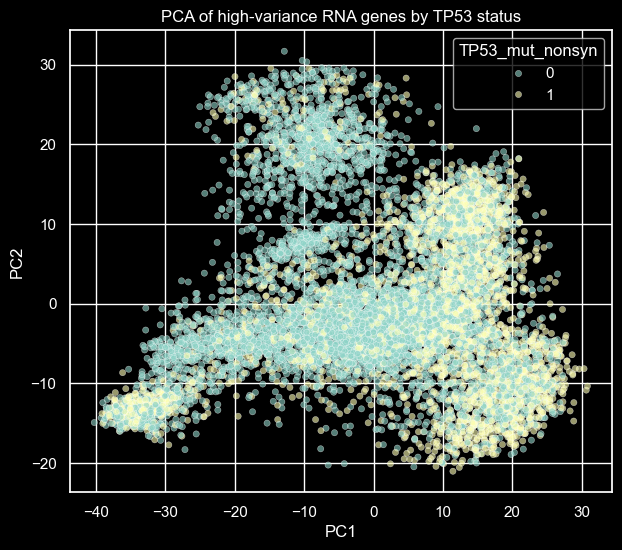

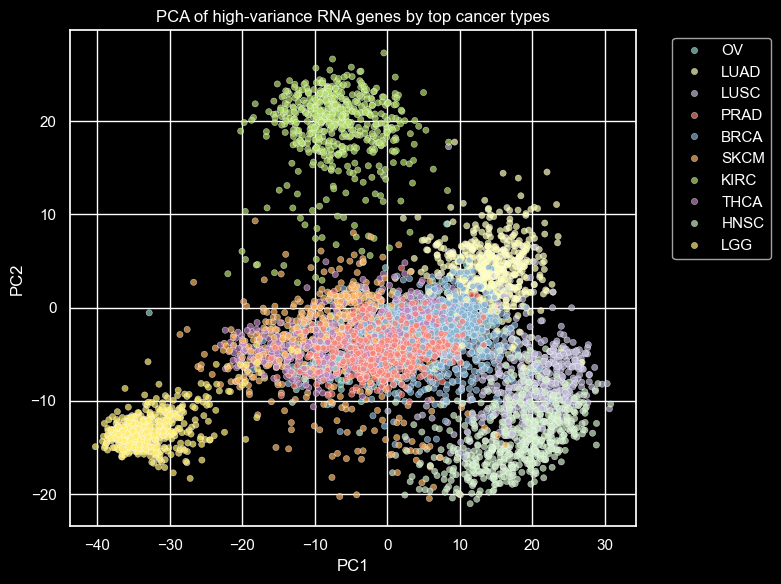

In [20]:
# Use top variable genes for stable PCA.
top_var_genes = gene_var.sort_values(ascending=False).head(TOP_VAR_GENES_FOR_PCA).index.tolist()

X_pca_input = expr_clean[top_var_genes].copy()
X_pca_input = X_pca_input.fillna(X_pca_input.median())

X_scaled = StandardScaler().fit_transform(X_pca_input)
pca = PCA(n_components=10, random_state=RANDOM_STATE)
pca_scores = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_scores[:, :5],
    columns=[f"PC{i}" for i in range(1, 6)],
    index=model_eda.index,
)
pca_df["TP53_mut_nonsyn"] = model_eda["TP53_mut_nonsyn"].values
pca_df[CANCER_TYPE_COL] = model_eda[CANCER_TYPE_COL].values

display(pca_df.head())
print("Explained variance ratio, first 5 PCs:", pca.explained_variance_ratio_[:5])

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="TP53_mut_nonsyn",
    alpha=0.6,
    s=20,
)
plt.title("PCA of high-variance RNA genes by TP53 status")
plt.show()

top_types = cancer_stats_clean.head(10).index
pca_top = pca_df.loc[pca_df[CANCER_TYPE_COL].isin(top_types)].copy()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_top,
    x="PC1",
    y="PC2",
    hue=CANCER_TYPE_COL,
    alpha=0.7,
    s=20,
)
plt.title("PCA of high-variance RNA genes by top cancer types")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### PCA interpretation

PCA is expected to reflect broad cancer-type structure more strongly than TP53 mutation status. This supports the modelling plan to include a cancer-type-only baseline and cancer-type-grouped evaluation. Random pan-cancer splits are likely easier than generalizing to held-out cancer types.

## TP53 target-gene and gene-identifier limitation

The RNA matrix typically uses Ensembl gene IDs, while TP53 target-gene lists often use gene symbols. Direct overlap between Ensembl IDs and symbols is not meaningful without an annotation map.

In [21]:
print("Example RNA feature IDs:")
display(pd.Series(gene_cols[:10], name="rna_feature_id"))

if TP53_TARGETS_PATH is not None and Path(TP53_TARGETS_PATH).exists():
    tp53_targets = pd.read_csv(TP53_TARGETS_PATH)
    print("TP53 target list shape:", tp53_targets.shape)
    display(tp53_targets.head())
else:
    tp53_targets = None
    print("No TP53 target-gene list found.")

if GENE_ANNOTATION_PATH is not None:
    print("Gene annotation file found:", GENE_ANNOTATION_PATH)
else:
    print("No gene annotation file found. Biological interpretation will be limited to Ensembl IDs.")

print("Direct symbol-to-Ensembl overlap should not be interpreted without annotation.")

Example RNA feature IDs:


0     ENSG00000242268.2
1     ENSG00000259041.1
2     ENSG00000270112.3
3    ENSG00000167578.16
4     ENSG00000278814.1
5     ENSG00000078237.5
6     ENSG00000269416.5
7     ENSG00000263642.1
8    ENSG00000146083.11
9    ENSG00000158486.13
Name: rna_feature_id, dtype: str

TP53 target list shape: (343, 1)


,gene_symbol
0,ABCA12
1,ABHD4
2,ABTB2
3,ACER2
4,ACTA2


No gene annotation file found. Biological interpretation will be limited to Ensembl IDs.
Direct symbol-to-Ensembl overlap should not be interpreted without annotation.


## Exploratory RNA-label differences

This section is descriptive only. It should not be used as final feature selection because it uses the full clean cohort and labels.

In [22]:
y_clean = model_eda["TP53_mut_nonsyn"].astype(int).values

group0 = expr_clean.loc[y_clean == 0]
group1 = expr_clean.loc[y_clean == 1]

effect_size = group1.mean(axis=0) - group0.mean(axis=0)
effect_df = effect_size.sort_values(ascending=False).rename("mean_diff_mut_minus_wt").to_frame()

display(effect_df.head(20))
display(effect_df.tail(20))

,mean_diff_mut_minus_wt
sample,
ENSG00000169469.8,4.562190
ENSG00000241794.1,4.439168
ENSG00000105388.14,4.316913
ENSG00000169474.4,4.215463
ENSG00000163216.6,4.207809
ENSG00000205420.10,4.201391
ENSG00000185479.5,4.079017
ENSG00000206075.13,3.850243
ENSG00000249395.2,3.803049


,mean_diff_mut_minus_wt
sample,
ENSG00000234779.1,-1.781997
ENSG00000105707.13,-1.790545
ENSG00000227568.1,-1.791834
ENSG00000279208.1,-1.793079
ENSG00000196415.9,-1.811815
ENSG00000249494.5,-1.835939
ENSG00000238243.3,-1.844602
ENSG00000160678.11,-1.850452
ENSG00000151365.2,-1.892142


### Warning

The exploratory RNA-label differences above are useful for sanity checking, but they are not a leakage-safe feature-selection procedure. In the modelling notebook, supervised feature selection must be performed only within training/CV folds.

# Part 3 conclusions

## Primary label

The Task 1 target for TCGA is `TP53_mut_nonsyn`: whether a sample has at least one nonsynonymous / protein-altering TP53 mutation. This is preferred over using any TP53 row because synonymous and ambiguous TP53 annotations should not be treated as equivalent to protein-altering mutations.

## Final modelling cohort rules

The final TCGA modelling cohort uses the following rules:

1. Keep samples present in the RNA matrix.
2. Keep tumour samples only, based on TCGA sample-type barcode codes.
3. Exclude samples with missing cancer type.
4. Exclude samples with ambiguous or mixed TP53 mutation annotation.
5. Keep one sample per patient to prevent patient-level leakage.
6. Prefer primary tumour samples when multiple tumour samples exist for the same patient.

In the current TCGA / UCSC Xena data this produces approximately 9,695 samples (one per patient), 33 cancer types, and TP53 nonsynonymous prevalence around 31.2%. Material deviation from these counts in Part 4 indicates a difference in input files or barcode normalisation.

## Main EDA findings

TP53 mutation status is moderately imbalanced, so accuracy alone is insufficient: AUPRC, AUROC, balanced accuracy, F1, and confusion matrices are reported in Part 4.

Cancer type is a major confounder. Some cancer types have very high TP53 mutation prevalence, others have very low or zero prevalence. Because cancer type also strongly affects RNA expression, random pan-cancer train / test splits may overestimate generalisation; Part 4 therefore includes a cancer-type-only baseline and cancer-type-grouped evaluation.

The RNA matrix is high-dimensional (~60,000 features). Variance filtering, top-variance selection, and supervised feature selection must be handled inside cross-validation folds.

The RNA matrix uses Ensembl gene IDs while the TP53 target list uses gene symbols; biological interpretation in Part 4 requires an Ensembl-to-symbol annotation map and is reported cautiously.

## Modelling risks identified

1. Patient-level leakage if multiple samples from the same patient appear across train and test.
2. Cancer-type confounding in pan-cancer prediction.
3. Supervised feature-selection leakage if RNA features are selected before splitting.
4. Misleading biological interpretation if Ensembl IDs are not mapped to gene symbols.
5. Overclaiming random-split performance as evidence of biological TP53 prediction.

## Part 4 plan

Part 4 uses:

1. dummy prior baseline,
2. cancer-type-only baseline,
3. RNA-only regularised model,
4. RNA + cancer-type model,
5. random stratified holdout evaluation,
6. cancer-type-grouped evaluation as the strictest anti-confounding estimate,
7. all RNA preprocessing and supervised feature selection inside training / CV folds,
8. cautious interpretation of coefficients when gene-symbol annotation is available.

# Part 4 — TCGA modelling (Tasks 1 and 2)

This part builds a leakage-aware modelling workflow for predicting TP53 mutation status from TCGA RNA expression, using the cohort defined at the end of Part 3.

It is designed to run on Kaggle, Colab, or local environments, with an optional GPU-backed cuML logistic-regression path when RAPIDS is available. If RAPIDS is unavailable, it falls back to scikit-learn on CPU while keeping the same modelling logic.

## Goals of Part 4

- use the tumour-only, one-sample-per-patient cohort from Part 3,
- predict TP53 nonsynonymous mutation status (Task 1) and TP53 mutation type (Task 2),
- compare against a dummy baseline, a cancer-type-only baseline, an RNA-only elastic-net logistic regression, and an RNA + cancer-type combined model,
- include a cancer-type-grouped evaluation as the strictest anti-confounding test,
- run an RNA model-family ablation and soft-voting ensemble,
- inspect RNA coefficients with cautious biological interpretation,
- report within-cancer-type performance.

## Input-file precedence

This part prefers the raw TCGA / UCSC Xena files when present:

- `mc3.v0.2.8.PUBLIC.xena`
- `Survival_SupplementalTable_S1_20171025_xena*`
- `tcga_RSEM_gene_tpm`

If those are not present, it falls back to curated CSV files.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import gc
import gzip
import os
import re
import sys
import subprocess
import warnings
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import CalibrationDisplay
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    StratifiedGroupKFold,
    StratifiedKFold,
    StratifiedShuffleSplit,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 200)

In [2]:
# Search locations for Kaggle, Colab, local, and this sandbox.
# The first Kaggle path below matches the path seen in the previously successful run.
SEARCH_ROOTS = [
    Path("/kaggle/input/datasets/cameroncaputa/tp53-prediction"),
    Path("/kaggle/input/tp53-prediction"),
    Path("/kaggle/input"),
    Path("/content"),
    Path("/mnt/data"),
    Path("tp53_completed_notebooks"),
]

def find_first(patterns, roots=SEARCH_ROOTS, required=False):
    tried = []
    for root in roots:
        if not root.exists():
            continue
        for pattern in patterns:
            matches = [p for p in root.rglob(pattern) if p.is_file()]
            if matches:
                return sorted(matches)[0]
            tried.append(f"{root}/**/{pattern}")
    if required:
        raise FileNotFoundError("Could not find any matching file.\nTried:\n" + "\n".join(tried))
    return None

# Prefer raw TCGA/Xena files when available.
RAW_MUT_PATH = find_first([
    "mc3.v0.2.8.PUBLIC.xena",
    "mc3.v0.2.8.PUBLIC.xena.gz",
    "*mc3.v0.2.8.PUBLIC.xena",
    "*mc3.v0.2.8.PUBLIC.xena.gz",
    "*mc3*PUBLIC*xena*",
], required=False)

RAW_PHENO_PATH = find_first([
    "Survival_SupplementalTable_S1_20171025_xena_sp",
    "Survival_SupplementalTable_S1_20171025_xena",
    "*Survival_SupplementalTable_S1_20171025*xena*",
], required=False)

RAW_RNA_PATH = find_first([
    "tcga_RSEM_gene_tpm",
    "tcga_RSEM_gene_tpm.gz",
    "*tcga_RSEM_gene_tpm*",
], required=False)

# Curated CSV fallbacks.
MODEL_PATH = find_first(["Model.csv", "*Model*.csv"], required=False)
OMICS_MUT_PATH = find_first([
    "OmicsSomaticMutations.csv",
    "*OmicsSomaticMutations*.csv",
], required=False)
OMICS_RNA_PATH = find_first([
    "OmicsExpressionProteinCodingGenesTPMLogp1.csv",
    "OmicsExpressionProteinCodingGenesTPML.csv",
    "*OmicsExpressionProteinCodingGenesTPM*.csv",
    "*OmicsExpressionProteinCodingGenesTPML*",
], required=False)

TP53_TARGETS_PATH = find_first([
    "tp53_target_genes_fischer2017.csv",
    "*tp53_target_genes_fischer2017*.csv",
], required=False)

GENE_ANNOTATION_PATH = find_first([
    "*probeMap*",
    "*gene_annotation*.csv",
    "*gene_annotation*.tsv",
    "*gencode*.csv",
    "*gencode*.tsv",
], required=False)

USE_RAW_TCGA = all(p is not None for p in [RAW_MUT_PATH, RAW_PHENO_PATH, RAW_RNA_PATH])

MUT_PATH = RAW_MUT_PATH if RAW_MUT_PATH is not None else OMICS_MUT_PATH
META_PATH = RAW_PHENO_PATH if RAW_PHENO_PATH is not None else MODEL_PATH
RNA_PATH = RAW_RNA_PATH if RAW_RNA_PATH is not None else OMICS_RNA_PATH

def show_available_kaggle_files(max_files=80):
    roots = [Path("/kaggle/input"), Path("/kaggle/input/datasets")]
    shown = 0
    print("\nAvailable files under Kaggle input roots:")
    for root in roots:
        if not root.exists():
            continue
        for p in sorted(root.rglob("*")):
            if p.is_file():
                print(" -", p)
                shown += 1
                if shown >= max_files:
                    print(f" ... truncated after {max_files} files")
                    return
    if shown == 0:
        print("No files found under /kaggle/input. Attach the TCGA raw-data Kaggle Dataset to this notebook.")

missing_inputs = []
if MUT_PATH is None:
    missing_inputs.append("mutation file: mc3.v0.2.8.PUBLIC.xena")
if META_PATH is None:
    missing_inputs.append("metadata/phenotype file: Survival_SupplementalTable_S1_20171025_xena_sp")
if RNA_PATH is None:
    missing_inputs.append("RNA expression file: tcga_RSEM_gene_tpm")

if missing_inputs:
    show_available_kaggle_files()
    raise FileNotFoundError(
        "Could not locate required TCGA input files. Missing:\n  - "
        + "\n  - ".join(missing_inputs)
        + "\n\nAttach the same Kaggle Dataset used in the successful run, which contained:\n"
        + "  /kaggle/input/datasets/cameroncaputa/tp53-prediction/mc3.v0.2.8.PUBLIC.xena/mc3.v0.2.8.PUBLIC.xena\n"
        + "  /kaggle/input/datasets/cameroncaputa/tp53-prediction/Survival_SupplementalTable_S1_20171025_xena_sp\n"
        + "  /kaggle/input/datasets/cameroncaputa/tp53-prediction/tcga_RSEM_gene_tpm/tcga_RSEM_gene_tpm\n"
        + "Optional but recommended: tp53_target_genes_fischer2017.csv"
    )

RANDOM_STATE = 42
TEST_SIZE = 0.20
INNER_CV_SPLITS = 5
GROUP_CV_SPLITS = 5
TOP_COEFS_TO_SHOW = 25
TOP_VAR_GENES = 5000
FLOOR_VALUE = -9.9658
MAX_FLOOR_FRAC = 0.95
BOOTSTRAP_RESAMPLES = 1000
MIN_SAMPLES_PER_CLASS = 20
SKLEARN_MAX_ITER = 10000
CUML_MAX_ITER = 10000
SAGA_TOL = 1e-3
CUML_TOL = 1e-4

RUN_GROUPED_CV = True
RUN_COMBINED_MODEL = True
RUN_WITHIN_CANCER_EVAL = True

# Runtime controls
GPU_REQUIRED = False
ALLOW_CPU_FALLBACK = True
INSTALL_RAPIDS_IN_COLAB = False
GPU_SEARCH_BACKEND = "cuml"      # {"cuml", "sklearn"}
FINAL_REFIT_BACKEND = "sklearn"  # {"sklearn", "cuml"}; sklearn is more reproducible for final reported fits
WITHIN_CANCER_BACKEND = "sklearn"   # {"cuml", "sklearn"}; fixed-parameter within-cancer checks favor reproducibility
GROUPED_TUNING_MODE = "nested"  # {"nested", "reuse_holdout_best"}; nested is slower but methodologically cleaner

META_C_GRID = [0.01, 0.1, 1.0, 10.0]

RNA_PARAM_GRID = {
    "top_k": [2000, 5000],
    "k_select": [250, 500, 1000, 2000],
    "scaler": ["maxabs", "standard"],
    "C": [0.001, 0.01, 0.1, 1.0],
    "l1_ratio": [0.0, 0.5, 1.0],
}

COMBO_PARAM_GRID = {
    "top_k": [2000, 5000],
    "k_select": [250, 500, 1000],
    "scaler": ["maxabs", "standard"],
    "C": [0.001, 0.01, 0.1, 1.0],
    "l1_ratio": [0.0, 0.5, 1.0],
}

# Smaller pre-specified grids for nested cancer-type-grouped evaluation.
# This keeps the stricter grouped analysis feasible while avoiding reuse of random-holdout hyperparameters.
GROUPED_RNA_PARAM_GRID = {
    "top_k": [5000],
    "k_select": [500, 1000],
    "scaler": ["maxabs"],
    "C": [0.01, 0.1, 1.0],
    "l1_ratio": [0.0, 0.5],
}
GROUPED_COMBO_PARAM_GRID = {
    "top_k": [5000],
    "k_select": [500, 1000],
    "scaler": ["maxabs"],
    "C": [0.01, 0.1, 1.0],
    "l1_ratio": [0.0, 0.5],
}

print("Using raw TCGA/Xena inputs:", USE_RAW_TCGA)
print("MUT_PATH =", MUT_PATH)
print("META_PATH =", META_PATH)
print("RNA_PATH =", RNA_PATH)
print("TP53_TARGETS_PATH =", TP53_TARGETS_PATH)
print("GENE_ANNOTATION_PATH =", GENE_ANNOTATION_PATH)
print("RNA grid combinations:", len(list(ParameterGrid(RNA_PARAM_GRID))))
print("Combined grid combinations:", len(list(ParameterGrid(COMBO_PARAM_GRID))))
print("Grouped RNA grid combinations:", len(list(ParameterGrid(GROUPED_RNA_PARAM_GRID))))
print("Grouped combined grid combinations:", len(list(ParameterGrid(GROUPED_COMBO_PARAM_GRID))))

Using raw TCGA/Xena inputs: True
MUT_PATH = /kaggle/input/datasets/cameroncaputa/tp53-prediction/mc3.v0.2.8.PUBLIC.xena/mc3.v0.2.8.PUBLIC.xena
META_PATH = /kaggle/input/datasets/cameroncaputa/tp53-prediction/Survival_SupplementalTable_S1_20171025_xena_sp
RNA_PATH = /kaggle/input/datasets/cameroncaputa/tp53-prediction/tcga_RSEM_gene_tpm/tcga_RSEM_gene_tpm
TP53_TARGETS_PATH = /kaggle/input/datasets/cameroncaputa/tp53-prediction/tp53_target_genes_fischer2017.csv
GENE_ANNOTATION_PATH = None
RNA grid combinations: 192
Combined grid combinations: 144
Grouped RNA grid combinations: 12
Grouped combined grid combinations: 12


## Backend strategy

This part uses a hybrid CPU/GPU strategy. GPU-accelerated cuML is used for the repeated hyperparameter-search fits, where speed matters most. The final refit, within-cancer analyses, and reported coefficients use scikit-learn, because these stages provide the final reported estimates, calibration, and subgroup results — and numerical stability, clearer convergence diagnostics, and reproducibility are more important than speed for them. This is especially relevant for some within-cancer subsets that are small or highly imbalanced, where GPU overhead and solver behaviour can be less reliable. cuML is therefore used as an acceleration tool for model search; scikit-learn is the reference implementation for final reporting.

## 4.0 GPU environment setup

The heavy RNA and combined-model searches can use RAPIDS cuML if available.

- If RAPIDS is installed and importable, the elastic-net search can use cuML logistic regression.
- If RAPIDS is unavailable, scikit-learn is used automatically unless `GPU_REQUIRED=True`.
- The final refit defaults to scikit-learn for more reproducible reported holdout estimates and fewer GPU convergence-warning issues.
- The grouped cancer-type evaluation defaults to nested tuning with a smaller pre-specified grid; this is slower but is the cleaner anti-confounding estimate than reusing hyperparameters selected on the random pan-cancer holdout.

In [3]:
IN_COLAB = "google.colab" in sys.modules
IN_KAGGLE = os.path.exists("/kaggle")

if INSTALL_RAPIDS_IN_COLAB and IN_COLAB:
    utils_dir = Path("./rapidsai-csp-utils")
    if not utils_dir.exists():
        subprocess.run(
            ["git", "clone", "https://github.com/rapidsai/rapidsai-csp-utils.git"],
            check=True,
        )
    subprocess.run([sys.executable, "rapidsai-csp-utils/colab/pip-install.py"], check=True)

GPU_AVAILABLE = False
GPU_IMPORT_ERROR = None
cp = None
cuLogisticRegression = None
cuml = None

try:
    import cupy as cp
    import cuml
    from cuml.linear_model import LogisticRegression as cuLogisticRegression

    GPU_AVAILABLE = True
    try:
        cuml.set_global_output_type("numpy")
    except Exception:
        pass
except Exception as e:
    GPU_IMPORT_ERROR = repr(e)

if GPU_REQUIRED and not GPU_AVAILABLE and not ALLOW_CPU_FALLBACK:
    raise RuntimeError(
        "GPU_REQUIRED=True but cuML/CuPy could not be imported. "
        "Install RAPIDS in a compatible CUDA environment first."
    )

if GPU_SEARCH_BACKEND == "cuml" and not GPU_AVAILABLE:
    if ALLOW_CPU_FALLBACK:
        print("cuML not available; falling back to scikit-learn CPU search.")
        GPU_SEARCH_BACKEND = "sklearn"
        if FINAL_REFIT_BACKEND == "cuml":
            FINAL_REFIT_BACKEND = "sklearn"
        if WITHIN_CANCER_BACKEND == "cuml":
            WITHIN_CANCER_BACKEND = "sklearn"
    else:
        raise RuntimeError("GPU search requested but cuML/CuPy are unavailable.")

gpu_name = None
try:
    smi = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        text=True,
    ).strip().splitlines()
    gpu_name = smi[0] if smi else None
except Exception:
    pass

print("In Colab:", IN_COLAB)
print("In Kaggle:", IN_KAGGLE)
print("GPU available:", GPU_AVAILABLE)
print("GPU import error:", GPU_IMPORT_ERROR)
print("Detected GPU name:", gpu_name)
print("GPU search backend:", GPU_SEARCH_BACKEND)
print("Final refit backend:", FINAL_REFIT_BACKEND)
print("Within-cancer backend:", WITHIN_CANCER_BACKEND)
print("Grouped tuning mode:", GROUPED_TUNING_MODE)

In Colab: False
In Kaggle: True
GPU available: True
GPU import error: None
Detected GPU name: Tesla T4
GPU search backend: cuml
Final refit backend: sklearn
Within-cancer backend: sklearn
Grouped tuning mode: nested


## 4.1 Load mutation and metadata tables

Mutation and phenotype tables are loaded first, the relevant schema is inferred, and only then is the RNA matrix loaded — after the modelling cohort is frozen. This avoids reading the full expression matrix too early.

In [4]:
def sniff_sep(path):
    opener = gzip.open if str(path).endswith(".gz") else open
    with opener(path, "rt", errors="ignore") as f:
        line = f.readline()
    if line.count("\t") > line.count(","):
        return "\t"
    return ","

def norm_name(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).lower())

def find_col(df, candidates, label, required=True):
    cols = list(df.columns)
    exact = {c.lower(): c for c in cols}
    normalized = {norm_name(c): c for c in cols}
    for cand in candidates:
        if cand.lower() in exact:
            return exact[cand.lower()]
    for cand in candidates:
        nc = norm_name(cand)
        if nc in normalized:
            return normalized[nc]
    if required:
        raise KeyError(f"Could not find {label}. Available columns: {cols}")
    return None

def looks_like_tcga_barcode(x):
    if pd.isna(x):
        return False
    return bool(re.match(r"^TCGA-[A-Za-z0-9]{2}-[A-Za-z0-9]{4}", str(x)))

def looks_like_ensembl(x):
    if pd.isna(x):
        return False
    return bool(re.match(r"^ENSG[0-9]+", str(x)))

def normalize_sample_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        return "-".join(parts[:4]) if len(parts) >= 4 else s
    return s

def normalize_patient_id(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        return "-".join(parts[:3]) if len(parts) >= 3 else s
    return s

def tcga_sample_type_code(barcode):
    if pd.isna(barcode):
        return np.nan
    s = str(barcode)
    if looks_like_tcga_barcode(s):
        parts = s.split("-")
        if len(parts) >= 4 and len(parts[3]) >= 2:
            return parts[3][:2]
    return np.nan

TCGA_SAMPLE_TYPE_MAP = {
    "01": "Primary Solid Tumor",
    "02": "Recurrent Solid Tumor",
    "03": "Primary Blood Derived Cancer - Peripheral Blood",
    "04": "Recurrent Blood Derived Cancer - Bone Marrow",
    "05": "Additional - New Primary",
    "06": "Metastatic",
    "07": "Additional Metastatic",
    "08": "Human Tumor Original Cells",
    "09": "Primary Blood Derived Cancer - Bone Marrow",
    "10": "Blood Derived Normal",
    "11": "Solid Tissue Normal",
    "12": "Buccal Cell Normal",
    "13": "EBV Immortalized Normal",
    "14": "Bone Marrow Normal",
    "20": "Control Analyte",
}

TUMOR_SAMPLE_TYPE_CODES = {"01", "02", "03", "04", "05", "06", "07", "08", "09"}

def tcga_sample_type_label(barcode):
    code = tcga_sample_type_code(barcode)
    return TCGA_SAMPLE_TYPE_MAP.get(code, "Unknown") if pd.notna(code) else np.nan

def is_tcga_tumor_sample(barcode):
    code = tcga_sample_type_code(barcode)
    return code in TUMOR_SAMPLE_TYPE_CODES if pd.notna(code) else False

MUT_SEP = sniff_sep(MUT_PATH)
META_SEP = sniff_sep(META_PATH)
RNA_SEP = sniff_sep(RNA_PATH)

mut_raw = pd.read_csv(MUT_PATH, sep=MUT_SEP, low_memory=False, dtype=str)
meta_raw = pd.read_csv(META_PATH, sep=META_SEP, low_memory=False, dtype=str)
rna_header = pd.read_csv(RNA_PATH, sep=RNA_SEP, nrows=3, low_memory=False)

print("mut_raw shape:", mut_raw.shape)
print("meta_raw shape:", meta_raw.shape)
print("rna_header preview shape:", rna_header.shape)
print("mut_raw columns:", mut_raw.columns.tolist()[:20])
print("meta_raw columns:", meta_raw.columns.tolist()[:20])
print("RNA first columns:", list(rna_header.columns[:8]))

MUT_SAMPLE_COL = find_col(
    mut_raw,
    ["Tumor_Sample_Barcode", "sample", "sample_id", "SampleID", "ModelID"],
    "mutation sample column",
)
MUT_GENE_COL = find_col(
    mut_raw,
    ["Hugo_Symbol", "HugoSymbol", "gene", "Gene", "symbol"],
    "mutation gene column",
)
MUT_EFFECT_COLS = [
    c for c in [
        find_col(mut_raw, ["Variant_Classification"], "Variant_Classification", required=False),
        find_col(mut_raw, ["VariantInfo"], "VariantInfo", required=False),
        find_col(mut_raw, ["effect"], "effect", required=False),
        find_col(mut_raw, ["Variant_Type"], "Variant_Type", required=False),
        find_col(mut_raw, ["VariantType"], "VariantType", required=False),
        find_col(mut_raw, ["Protein_Change"], "Protein_Change", required=False),
        find_col(mut_raw, ["ProteinChange"], "ProteinChange", required=False),
        find_col(mut_raw, ["Consequence"], "Consequence", required=False),
    ] if c is not None
]
assert len(MUT_EFFECT_COLS) > 0, "Could not find any mutation effect / classification columns."

META_SAMPLE_COL = find_col(
    meta_raw,
    ["sample", "sample_id", "SampleID", "submitter_id", "Tumor_Sample_Barcode", "ModelID"],
    "metadata sample column",
)
PATIENT_COL = find_col(
    meta_raw,
    ["patient", "patient_id", "PatientID", "case_submitter_id", "participant_id"],
    "patient column",
    required=False,
)
CANCER_TYPE_COL = find_col(
    meta_raw,
    ["cancer type abbreviation", "cancer_type_abbreviation", "acronym", "project_id", "OncotreeCode", "primary_disease"],
    "cancer type column",
)

print("Chosen mutation sample column:", MUT_SAMPLE_COL)
print("Chosen mutation gene column:", MUT_GENE_COL)
print("Chosen mutation effect columns:", MUT_EFFECT_COLS)
print("Chosen metadata sample column:", META_SAMPLE_COL)
print("Chosen patient column:", PATIENT_COL)
print("Chosen cancer type column:", CANCER_TYPE_COL)

mut_raw shape: (2907335, 12)
meta_raw shape: (12591, 34)
rna_header preview shape: (3, 10536)
mut_raw columns: ['sample', 'chr', 'start', 'end', 'reference', 'alt', 'gene', 'effect', 'Amino_Acid_Change', 'DNA_VAF', 'SIFT', 'PolyPhen']
meta_raw columns: ['sample', '_PATIENT', 'cancer type abbreviation', 'age_at_initial_pathologic_diagnosis', 'gender', 'race', 'ajcc_pathologic_tumor_stage', 'clinical_stage', 'histological_type', 'histological_grade', 'initial_pathologic_dx_year', 'menopause_status', 'birth_days_to', 'vital_status', 'tumor_status', 'last_contact_days_to', 'death_days_to', 'cause_of_death', 'new_tumor_event_type', 'new_tumor_event_site']
RNA first columns: ['sample', 'TCGA-19-1787-01', 'TCGA-S9-A7J2-01', 'TCGA-G3-A3CH-11', 'TCGA-EK-A2RE-01', 'TCGA-44-6778-01', 'TCGA-F4-6854-01', 'TCGA-AB-2863-03']
Chosen mutation sample column: sample
Chosen mutation gene column: gene
Chosen mutation effect columns: ['effect']
Chosen metadata sample column: sample
Chosen patient column: _P

## 4.2 Infer RNA matrix orientation and available samples

Two RNA layouts are supported:

1. **sample × gene** — first column is sample ID, remaining columns are genes,
2. **gene × sample** — first column is gene ID, remaining columns are sample IDs.

The loader detects the layout automatically and later loads only the retained cohort.

In [5]:
def infer_rna_orientation(header_df):
    cols = list(header_df.columns)
    first_col = cols[0]
    other_cols = cols[1:min(len(cols), 200)]

    first_norm = norm_name(first_col)
    sample_named_first = first_norm in {"sample", "sampleid", "samplebarcode", "submitterid", "modelid"}

    tcga_header_frac = np.mean([looks_like_tcga_barcode(c) for c in other_cols]) if other_cols else 0.0
    ensembl_header_frac = np.mean([looks_like_ensembl(c) for c in other_cols]) if other_cols else 0.0

    # Strong clues from header names.
    if sample_named_first and ensembl_header_frac >= 0.05:
        return "sample_x_gene"
    if tcga_header_frac >= 0.20:
        return "gene_x_sample"
    if sample_named_first:
        return "sample_x_gene"

    # Fallback using first few row values.
    preview_first_values = header_df.iloc[:, 0].astype(str).tolist()
    preview_tcga_frac = np.mean([looks_like_tcga_barcode(v) for v in preview_first_values]) if preview_first_values else 0.0
    if preview_tcga_frac >= 0.5 and ensembl_header_frac >= 0.02:
        return "sample_x_gene"

    # Conservative default for TCGA-like Xena matrices.
    return "sample_x_gene"

RNA_ORIENTATION = infer_rna_orientation(rna_header)
RNA_FIRST_COL = rna_header.columns[0]

def get_rna_available_samples(path, sep, orientation):
    if orientation == "gene_x_sample":
        header = pd.read_csv(path, sep=sep, nrows=0)
        sample_ids = [normalize_sample_id(c) for c in header.columns[1:]]
        return pd.Index(pd.unique(pd.Series(sample_ids).dropna()), name="sample_id")

    sample_ids = []
    for chunk in pd.read_csv(path, sep=sep, usecols=[0], chunksize=5000, low_memory=False):
        vals = chunk.iloc[:, 0].map(normalize_sample_id)
        sample_ids.extend(vals.dropna().tolist())
    return pd.Index(pd.unique(pd.Series(sample_ids)), name="sample_id")

rna_available_samples = get_rna_available_samples(RNA_PATH, RNA_SEP, RNA_ORIENTATION)

print("RNA orientation:", RNA_ORIENTATION)
print("RNA first column:", RNA_FIRST_COL)
print("Number of RNA-available samples:", len(rna_available_samples))
print("Example RNA-available samples:", rna_available_samples[:5].tolist())

RNA orientation: gene_x_sample
RNA first column: sample
Number of RNA-available samples: 10535
Example RNA-available samples: ['TCGA-19-1787-01', 'TCGA-S9-A7J2-01', 'TCGA-G3-A3CH-11', 'TCGA-EK-A2RE-01', 'TCGA-44-6778-01']


## 4.3 Rebuild the TP53 sample-level label (TCGA)

The Task 1 rule matches Part 1 / Part 2: `TP53_mut_nonsyn = 1` if a sample has at least one protein-altering TP53 event, with ambiguous or mixed cases tracked and later excluded from modelling.

In [6]:
tp53_rows = mut_raw.loc[mut_raw[MUT_GENE_COL].astype(str).str.upper().eq("TP53")].copy()
tp53_rows["sample_id"] = tp53_rows[MUT_SAMPLE_COL].map(normalize_sample_id)
tp53_rows["patient_id"] = tp53_rows[MUT_SAMPLE_COL].map(normalize_patient_id)

tp53_rows["effect_text"] = (
    tp53_rows[MUT_EFFECT_COLS]
    .fillna("")
    .astype(str)
    .agg(" | ".join, axis=1)
    .str.strip()
)

PROTEIN_ALTERING_KEYWORDS = {
    "missense", "nonsense", "frame_shift", "frameshift", "splice", "stop_gained",
    "stoplost", "stop_lost", "nonstop", "translation_start", "start_codon",
    "inframe", "in_frame", "trunc", "deleterious", "nonsynonymous", "non_synonymous"
}
SYNONYMOUS_KEYWORDS = {"silent", "synonymous"}

def classify_tp53_effect(effect):
    if pd.isna(effect):
        return "unknown"
    e = str(effect).strip().lower()
    if e == "":
        return "unknown"
    if any(k in e for k in SYNONYMOUS_KEYWORDS):
        return "synonymous"
    if "missense" in e:
        return "missense"
    if any(k in e for k in ["nonsense", "stop_gained", "nonstop", "frame_shift", "frameshift", "trunc"]):
        return "truncating"
    if "splice" in e:
        return "splice"
    if "inframe" in e or "in_frame" in e:
        return "inframe"
    if any(k in e for k in PROTEIN_ALTERING_KEYWORDS):
        return "protein_altering"
    return "other_or_unknown"

tp53_rows["tp53_event_class"] = tp53_rows["effect_text"].map(classify_tp53_effect)
tp53_rows["is_tp53_nonsyn"] = tp53_rows["tp53_event_class"].isin(
    ["missense", "truncating", "splice", "inframe", "protein_altering"]
)
tp53_rows["is_tp53_ambiguous"] = tp53_rows["tp53_event_class"].isin(["unknown", "other_or_unknown"])

tp53_sample = (
    tp53_rows.groupby("sample_id", dropna=True)
    .agg(
        patient_id=("patient_id", "first"),
        n_tp53_rows=("sample_id", "size"),
        has_any_tp53_row=("sample_id", lambda x: True),
        has_any_tp53_nonsyn=("is_tp53_nonsyn", "max"),
        has_any_tp53_ambiguous=("is_tp53_ambiguous", "max"),
        n_unique_tp53_event_classes=("tp53_event_class", "nunique"),
        example_effects=("effect_text", lambda x: "; ".join(pd.Series(x).dropna().astype(str).unique()[:5])),
    )
    .reset_index()
)

tp53_sample["TP53_mut_nonsyn"] = tp53_sample["has_any_tp53_nonsyn"].astype(int)
tp53_sample["TP53_mut_ambiguous"] = tp53_sample["has_any_tp53_ambiguous"].astype(int)
tp53_sample["has_mixed_tp53_annotation"] = (
    tp53_sample["has_any_tp53_nonsyn"] & tp53_sample["has_any_tp53_ambiguous"]
).astype(int)

print("TP53 mutation rows:", len(tp53_rows))
display(tp53_rows["tp53_event_class"].value_counts(dropna=False).to_frame("n_rows"))
display(tp53_sample[["TP53_mut_nonsyn", "TP53_mut_ambiguous", "has_mixed_tp53_annotation"]].mean().to_frame("rate"))

TP53 mutation rows: 3729


,n_rows
tp53_event_class,
missense,2382
truncating,921
splice,238
synonymous,90
inframe,79
other_or_unknown,18
protein_altering,1


,rate
TP53_mut_nonsyn,0.983459
TP53_mut_ambiguous,0.005414
has_mixed_tp53_annotation,0.002406


In [7]:
# Task 2 sample-level mutation-type label source.
# A sample can have multiple TP53 rows, so choose a primary event by severity for the multiclass task.
TCGA_TASK2_PRIORITY = {
    "truncating": 7,
    "splice": 6,
    "missense": 5,
    "inframe": 4,
    "protein_altering": 3,
    "synonymous": 2,
    "other_or_unknown": 1,
    "unknown": 0,
}

tp53_rows["task2_priority"] = (
    tp53_rows["tp53_event_class"]
    .map(TCGA_TASK2_PRIORITY)
    .fillna(0)
    .astype(int)
)

tp53_primary_event = (
    tp53_rows
    .sort_values(["sample_id", "task2_priority"], ascending=[True, False])
    .drop_duplicates("sample_id")
    .set_index("sample_id")["tp53_event_class"]
    .rename("tp53_primary_event_class")
)

tp53_nonsyn_class_count = (
    tp53_rows.loc[tp53_rows["is_tp53_nonsyn"]]
    .groupby("sample_id")["tp53_event_class"]
    .nunique()
    .rename("n_unique_tp53_nonsyn_event_classes")
)

tp53_sample = tp53_sample.merge(
    tp53_primary_event.reset_index(),
    on="sample_id",
    how="left",
)

tp53_sample = tp53_sample.merge(
    tp53_nonsyn_class_count.reset_index(),
    on="sample_id",
    how="left",
    suffixes=("", "_nonsyn_only"),
)

if "n_unique_tp53_nonsyn_event_classes_nonsyn_only" in tp53_sample.columns:
    tp53_sample["n_unique_tp53_nonsyn_event_classes"] = tp53_sample[
        "n_unique_tp53_nonsyn_event_classes_nonsyn_only"
    ].fillna(0).astype(int)
    tp53_sample = tp53_sample.drop(columns=["n_unique_tp53_nonsyn_event_classes_nonsyn_only"])

print("Sample-level primary TP53 event class counts before cohort filtering:")
display(tp53_primary_event.value_counts().rename_axis("tp53_primary_event_class").to_frame("n_samples"))


Sample-level primary TP53 event class counts before cohort filtering:


,n_samples
tp53_primary_event_class,
missense,2069
truncating,900
splice,230
inframe,71
synonymous,45
other_or_unknown,10


## 4.4 Phenotype metadata and final modelling cohort

This block applies the leakage-aware cohort rules before any large RNA matrix is loaded:

- retain only samples with RNA available,
- derive patient IDs from phenotype / sample barcodes for **all** samples, not only mutation-positive samples,
- keep tumour samples only,
- require non-missing cancer type,
- remove ambiguous or mixed TP53 labels,
- keep exactly one sample per patient.

These rules mirror Part 3.

In [8]:
meta = meta_raw.copy()
meta["sample_id"] = meta[META_SAMPLE_COL].map(normalize_sample_id)

if PATIENT_COL is not None:
    meta["patient_id"] = meta[PATIENT_COL]
else:
    meta["patient_id"] = meta["sample_id"].map(normalize_patient_id)

meta["patient_id"] = meta["patient_id"].fillna(meta["sample_id"].map(normalize_patient_id))
meta["sample_type_code"] = meta["sample_id"].map(tcga_sample_type_code)
meta["sample_type_label"] = meta["sample_id"].map(tcga_sample_type_label)

if USE_RAW_TCGA:
    meta["is_tumor_sample"] = meta["sample_id"].map(is_tcga_tumor_sample)
else:
    # For non-TCGA fallback tables, keep all rows by default.
    meta["is_tumor_sample"] = True

meta["in_rna"] = meta["sample_id"].isin(rna_available_samples)

meta = meta.merge(tp53_sample, on="sample_id", how="left", suffixes=("", "_tp53"))
if "patient_id_tp53" in meta.columns:
    meta["patient_id"] = meta["patient_id"].fillna(meta["patient_id_tp53"])

meta["TP53_mut_nonsyn"] = meta["TP53_mut_nonsyn"].fillna(0).astype(int)
meta["TP53_mut_ambiguous"] = meta["TP53_mut_ambiguous"].fillna(0).astype(int)
meta["has_any_tp53_row"] = meta["has_any_tp53_row"].fillna(False).astype(bool)
meta["has_mixed_tp53_annotation"] = meta["has_mixed_tp53_annotation"].fillna(0).astype(int)

SAMPLE_PRIORITY = {
    "01": 0,
    "03": 1,
    "06": 2,
    "02": 3,
    "05": 4,
    "07": 5,
    "08": 6,
    "09": 7,
    "04": 8,
}

model_meta = meta.copy()
model_meta = model_meta.loc[model_meta["in_rna"]].copy()
model_meta = model_meta.loc[model_meta["is_tumor_sample"].fillna(False)].copy()
model_meta = model_meta.loc[model_meta[CANCER_TYPE_COL].notna()].copy()
model_meta = model_meta.loc[
    (model_meta["TP53_mut_ambiguous"] == 0) &
    (model_meta["has_mixed_tp53_annotation"] == 0)
].copy()

pre_dedup_n = len(model_meta)
pre_dedup_multi_patient_counts = (
    model_meta["patient_id"].value_counts().loc[lambda s: s > 1].sort_values(ascending=False)
)

model_meta["sample_priority"] = model_meta["sample_type_code"].map(SAMPLE_PRIORITY).fillna(99)
model_meta = (
    model_meta.sort_values(["patient_id", "sample_priority", "sample_id"])
    .drop_duplicates(subset="patient_id", keep="first")
    .reset_index(drop=True)
)

cohort_summary = pd.Series({
    "n_rows": len(model_meta),
    "n_unique_samples": model_meta["sample_id"].nunique(),
    "n_unique_patients": model_meta["patient_id"].nunique(),
    "tp53_prevalence": model_meta["TP53_mut_nonsyn"].mean(),
    "n_cancer_types": model_meta[CANCER_TYPE_COL].nunique(),
    "rows_before_patient_dedup": pre_dedup_n,
    "patients_with_multiple_samples_before_dedup": len(pre_dedup_multi_patient_counts),
})

display(cohort_summary.to_frame("value"))
print("Patients with multiple retained samples before dedup:", len(pre_dedup_multi_patient_counts))
display(pre_dedup_multi_patient_counts.head(10).to_frame("n_samples"))

assert model_meta["patient_id"].isna().sum() == 0, "Patient IDs must be present after backfill."
assert model_meta["patient_id"].nunique() == len(model_meta), "Exactly one sample per patient should remain."
assert set(model_meta["TP53_mut_nonsyn"].unique()).issubset({0, 1}), "Target must be binary."
print("Final cohort passes basic leakage-sensitive checks.")

,value
n_rows,9695.000000
n_unique_samples,9695.000000
n_unique_patients,9695.000000
tp53_prevalence,0.311604
n_cancer_types,33.000000
rows_before_patient_dedup,9767.000000
patients_with_multiple_samples_before_dedup,71.000000


Patients with multiple retained samples before dedup: 71


,n_samples
patient_id,
TCGA-SR-A6MX,3
TCGA-G5-6572,2
TCGA-2G-AAKG,2
TCGA-ER-A2NF,2
TCGA-K1-A42X,2
TCGA-TM-A7CF,2
TCGA-QR-A6GZ,2
TCGA-K1-A3PN,2
TCGA-HM-A6W2,2


Final cohort passes basic leakage-sensitive checks.


## 4.5 Task 2 label design — sample-level TP53 mutation type (TCGA)

This block constructs the multiclass mutation-type label required by the assignment, for **every sample including wild-type**. Rare or ambiguous TCGA classes are counted and then excluded from the multiclass model, rather than being forced into unstable labels. The final TCGA Task 2 classes are `WT`, `missense`, and `truncating_or_splice`; the mapping from these classes to the reference mutation-type categories (Berkeley / EBI / libretexts) is documented in the final defensibility statement.

In [9]:
def collapse_tcga_task2_label(raw_class):
    if pd.isna(raw_class):
        return "WT"
    if raw_class == "missense":
        return "missense"
    if raw_class in {"truncating", "splice"}:
        return "truncating_or_splice"
    if raw_class in {"inframe", "protein_altering"}:
        return "rare_protein_altering_excluded"
    if raw_class == "synonymous":
        return "synonymous_excluded"
    return "ambiguous_excluded"

model_meta["TP53_task2_raw"] = model_meta["tp53_primary_event_class"].fillna("WT")
model_meta["TP53_task2_label"] = model_meta["tp53_primary_event_class"].map(collapse_tcga_task2_label)

task2_raw_counts = (
    model_meta["TP53_task2_raw"]
    .value_counts(dropna=False)
    .rename_axis("TP53_task2_raw")
    .to_frame("n")
)

task2_candidate_counts = (
    model_meta["TP53_task2_label"]
    .value_counts(dropna=False)
    .rename_axis("TP53_task2_label")
    .to_frame("n")
)

print("Raw TCGA Task 2 labels in final clean cohort:")
display(task2_raw_counts)
print("Collapsed/excluded TCGA Task 2 labels:")
display(task2_candidate_counts)

tcga_task2_keep_labels = ["WT", "missense", "truncating_or_splice"]
task2_mask = model_meta["TP53_task2_label"].isin(tcga_task2_keep_labels)
model_meta_task2 = model_meta.loc[task2_mask].copy()

print("Final TCGA Task 2 modeling classes:")
display(
    model_meta_task2["TP53_task2_label"]
    .value_counts()
    .reindex(tcga_task2_keep_labels)
    .rename_axis("TP53_task2_label")
    .to_frame("n_final_task2")
)

print("Excluded from main Task 2 model:")
display(
    task2_candidate_counts.loc[
        ~task2_candidate_counts.index.isin(tcga_task2_keep_labels)
    ]
)


Raw TCGA Task 2 labels in final clean cohort:


,n
TP53_task2_raw,
WT,6636
missense,1898
truncating,841
splice,216
inframe,66
synonymous,38


Collapsed/excluded TCGA Task 2 labels:


,n
TP53_task2_label,
WT,6636
missense,1898
truncating_or_splice,1057
rare_protein_altering_excluded,66
synonymous_excluded,38


Final TCGA Task 2 modeling classes:


,n_final_task2
TP53_task2_label,
WT,6636
missense,1898
truncating_or_splice,1057


Excluded from main Task 2 model:


,n
TP53_task2_label,
rare_protein_altering_excluded,66
synonymous_excluded,38


## 4.6 Load RNA for the final retained cohort only

The loader handles either:

- **sample × gene** RNA matrices, by chunking through rows and keeping only retained samples,
- **gene × sample** RNA matrices, by loading only the retained sample columns and then transposing.

In [10]:
def load_rna_subset(path, sep, orientation, selected_sample_ids):
    selected_sample_ids = list(pd.Index(selected_sample_ids).astype(str))
    selected_set = set(selected_sample_ids)

    if orientation == "sample_x_gene":
        chunks = []
        for chunk in pd.read_csv(path, sep=sep, chunksize=256, low_memory=False):
            first_col = chunk.columns[0]
            chunk["sample_id"] = chunk[first_col].map(normalize_sample_id)
            sub = chunk.loc[chunk["sample_id"].isin(selected_set)].copy()
            if len(sub) == 0:
                continue
            keep_cols = ["sample_id"] + [c for c in sub.columns if c not in {first_col, "sample_id"}]
            sub = sub[keep_cols]
            chunks.append(sub)

        if len(chunks) == 0:
            raise ValueError("No selected samples were found in the RNA matrix.")

        rna_df = pd.concat(chunks, axis=0, ignore_index=True)
        rna_df = rna_df.drop_duplicates("sample_id", keep="first")
        rna_df = rna_df.set_index("sample_id")
        rna_df = rna_df.reindex(selected_sample_ids)
        rna_df.index.name = "sample_id"
        rna_df.columns.name = None
        rna_df = rna_df.apply(pd.to_numeric, errors="coerce").astype(np.float32)
        return rna_df

    # gene × sample
    header = pd.read_csv(path, sep=sep, nrows=0)
    first_col = header.columns[0]
    sample_cols = [c for c in header.columns[1:] if normalize_sample_id(c) in selected_set]
    if len(sample_cols) == 0:
        raise ValueError("No selected samples matched RNA columns in a gene × sample matrix.")

    subset = pd.read_csv(path, sep=sep, usecols=[first_col] + sample_cols, low_memory=False)
    subset = subset.rename(columns={first_col: "feature_id"})

    rename_map = {c: normalize_sample_id(c) for c in sample_cols}
    subset = subset.rename(columns=rename_map)

    # If multiple original columns collapse to the same normalized sample_id, average them.
    dup_cols = pd.Index(subset.columns[1:]).duplicated(keep=False)
    if dup_cols.any():
        feature = subset["feature_id"]
        values = subset.drop(columns=["feature_id"])
        values = values.groupby(level=0, axis=1).mean()
        subset = pd.concat([feature, values], axis=1)

    subset = subset.set_index("feature_id")
    subset = subset.apply(pd.to_numeric, errors="coerce")
    rna_df = subset.T
    rna_df.index = pd.Index(rna_df.index.map(normalize_sample_id), name="sample_id")
    rna_df = rna_df.groupby(level=0).mean()
    rna_df = rna_df.reindex(selected_sample_ids)
    rna_df.columns.name = None
    rna_df = rna_df.astype(np.float32)
    return rna_df

selected_sample_ids = model_meta["sample_id"].tolist()
rna_mat = load_rna_subset(RNA_PATH, RNA_SEP, RNA_ORIENTATION, selected_sample_ids)

assert rna_mat.shape[0] == len(selected_sample_ids), "RNA sample count does not match retained cohort."
assert rna_mat.index.equals(pd.Index(selected_sample_ids, name="sample_id")), "RNA sample order mismatch."

print("rna_mat shape (samples x genes):", rna_mat.shape)
print("RNA missing fraction:", float(rna_mat.isna().mean().mean()))
print("RNA dtype summary:")
print(rna_mat.dtypes.value_counts().head())
print(
    "Observed RNA min / median / max:",
    float(np.nanmin(rna_mat.to_numpy())),
    float(np.nanmedian(rna_mat.to_numpy())),
    float(np.nanmax(rna_mat.to_numpy())),
)
print("Overall fraction exactly at floor value:", float(np.isclose(rna_mat.to_numpy(), FLOOR_VALUE, atol=1e-6).mean()))
display(rna_mat.iloc[:3, :5])

rna_mat shape (samples x genes): (9695, 60498)
RNA missing fraction: 0.0
RNA dtype summary:
float32    60498
Name: count, dtype: int64
Observed RNA min / median / max: -9.965800285339355 -9.965800285339355 19.211000442504883
Overall fraction exactly at floor value: 0.5393398792088584


,ENSG00000242268.2,ENSG00000259041.1,ENSG00000270112.3,ENSG00000167578.16,ENSG00000278814.1
sample_id,,,,,
TCGA-02-0047-01,0.0158,-9.9658,-0.8863,5.9750,-9.9658
TCGA-02-0055-01,-9.9658,-9.9658,-3.8160,5.2506,-9.9658
TCGA-02-2483-01,-9.9658,-9.9658,-5.5735,5.4519,-9.9658


## 4.7 Prepare train and test data

In [11]:
y = model_meta["TP53_mut_nonsyn"].astype(np.int8).to_numpy()
groups = model_meta[CANCER_TYPE_COL].astype(str).to_numpy()
X_meta = model_meta[[CANCER_TYPE_COL]].copy()
X_rna = rna_mat.to_numpy(dtype=np.float32, copy=True)
gene_ids = np.array(rna_mat.columns)

del rna_mat
_ = gc.collect()

print("X_meta shape:", X_meta.shape)
print("X_rna shape:", X_rna.shape)
print("X_rna dtype:", X_rna.dtype)
print("Positive class rate:", y.mean())

sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(sss.split(np.zeros(len(y)), y))

X_meta_train, X_meta_test = X_meta.iloc[train_idx], X_meta.iloc[test_idx]
X_rna_train, X_rna_test = X_rna[train_idx], X_rna[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
patient_train = model_meta.iloc[train_idx]["patient_id"]
patient_test = model_meta.iloc[test_idx]["patient_id"]

assert set(patient_train).isdisjoint(set(patient_test)), "Patient overlap detected across train/test."

print("Train size:", len(train_idx))
print("Test size:", len(test_idx))
print("Train prevalence:", y_train.mean())
print("Test prevalence:", y_test.mean())

print("Cancer types in train:", pd.Series(groups[train_idx]).nunique())
print("Cancer types in test:", pd.Series(groups[test_idx]).nunique())
print("Cancer types absent from train but present in random test:", sorted(set(groups[test_idx]) - set(groups[train_idx])))
print("Cancer types absent from random test but present in train:", sorted(set(groups[train_idx]) - set(groups[test_idx]))[:10])

X_meta shape: (9695, 1)
X_rna shape: (9695, 60498)
X_rna dtype: float32
Positive class rate: 0.3116039195461578
Train size: 7756
Test size: 1939
Train prevalence: 0.31162970603403817
Test prevalence: 0.3115007735946364
Cancer types in train: 33
Cancer types in test: 33
Cancer types absent from train but present in random test: []
Cancer types absent from random test but present in train: []


## 4.8 Evaluation helpers

In [12]:
def subset_X(X, idx):
    if isinstance(X, (pd.DataFrame, pd.Series)):
        return X.iloc[idx]
    return X[idx]

def evaluate_from_proba(y_true, y_proba, threshold=0.5):
    """Primary metrics are threshold-free AUROC/AUPRC plus calibration/Brier.
    Threshold-dependent metrics use a fixed 0.5 threshold and should be interpreted as secondary.
    """
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "auroc": roc_auc_score(y_true, y_proba),
        "auprc": average_precision_score(y_true, y_proba),
        "balanced_accuracy_at_0.5": balanced_accuracy_score(y_true, y_pred),
        "f1_at_0.5": f1_score(y_true, y_pred),
        "brier": brier_score_loss(y_true, y_proba),
    }

def plot_roc_pr_curves(y_true, y_proba, title_prefix="Model"):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    precision, recall, _ = precision_recall_curve(y_true, y_proba)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(fpr, tpr)
    axes[0].plot([0, 1], [0, 1], linestyle="--")
    axes[0].set_title(f"{title_prefix} ROC")
    axes[0].set_xlabel("False positive rate")
    axes[0].set_ylabel("True positive rate")

    axes[1].plot(recall, precision)
    axes[1].set_title(f"{title_prefix} Precision-Recall")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    plt.tight_layout()
    plt.show()

def evaluate_fitted_model(name, fitted_estimator, X_test, y_test, threshold=0.5, show_plots=True):
    y_proba = fitted_estimator.predict_proba(X_test)[:, 1]
    metrics = pd.Series({"model": name, **evaluate_from_proba(y_test, y_proba, threshold=threshold)})

    print()
    print(name)
    display(metrics.to_frame("value"))

    y_pred = (y_proba >= threshold).astype(int)
    print("Confusion matrix:")
    display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=["true_0", "true_1"], columns=["pred_0", "pred_1"]))
    print("Classification report at fixed threshold 0.5:")
    print(classification_report(y_test, y_pred, digits=3))

    if show_plots:
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
        plt.show()
        plot_roc_pr_curves(y_test, y_proba, title_prefix=name)

    return metrics, y_proba

def bootstrap_metric_ci(y_true, y_proba, metric_fn, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    n = len(y_true)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        vals.append(metric_fn(y_true[idx], y_proba[idx]))
    return np.percentile(vals, [2.5, 50, 97.5])

## 4.9 Baseline 1 — dummy classifier

In [13]:
dummy = DummyClassifier(strategy="prior")
dummy.fit(np.zeros((len(y_train), 1)), y_train)
dummy_proba = dummy.predict_proba(np.zeros((len(y_test), 1)))[:, 1]
dummy_metrics = pd.Series({"model": "dummy_prior", **evaluate_from_proba(y_test, dummy_proba)})
display(dummy_metrics.to_frame("value"))

,value
model,dummy_prior
auroc,0.5
auprc,0.311501
balanced_accuracy_at_0.5,0.5
f1_at_0.5,0.0
brier,0.214468


## 4.10 Baseline 2 — cancer-type-only logistic regression

Best metadata params: {'clf__C': 10.0}
Best metadata CV AUPRC: 0.6666887208864052

metadata_only_cancer_type


,value
model,metadata_only_cancer_type
auroc,0.82418
auprc,0.647466
balanced_accuracy_at_0.5,0.749707
f1_at_0.5,0.649492
brier,0.179839


Confusion matrix:


,pred_0,pred_1
true_0,943,392
true_1,125,479


Classification report at fixed threshold 0.5:
              precision    recall  f1-score   support

           0      0.883     0.706     0.785      1335
           1      0.550     0.793     0.649       604

    accuracy                          0.733      1939
   macro avg      0.716     0.750     0.717      1939
weighted avg      0.779     0.733     0.743      1939



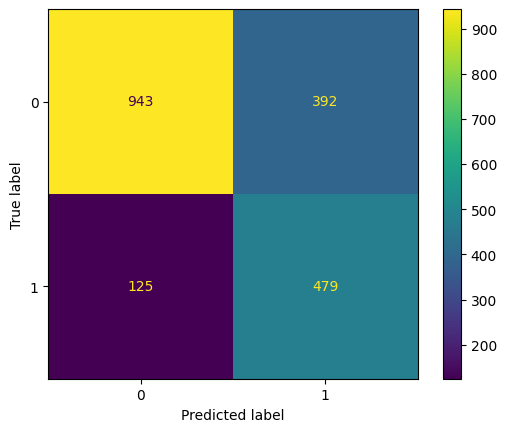

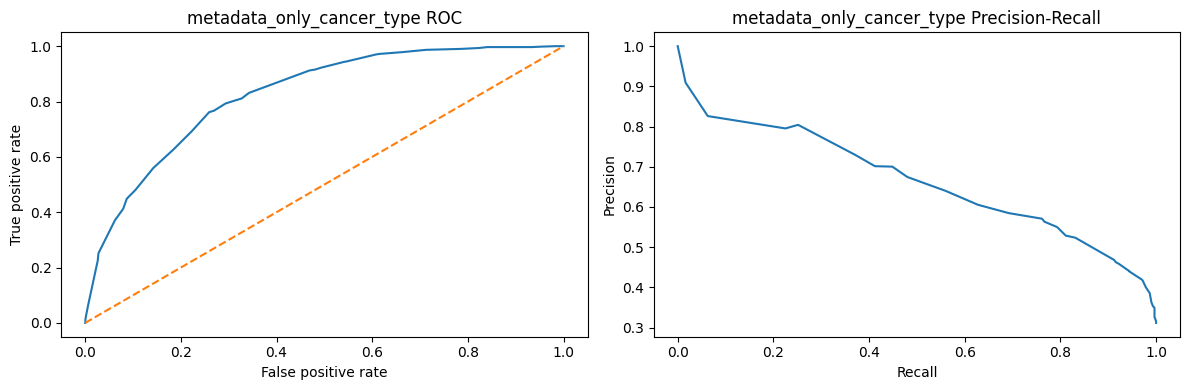

In [14]:
inner_cv = StratifiedKFold(n_splits=INNER_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

meta_pipe = Pipeline([
    (
        "prep",
        ColumnTransformer(
            transformers=[
                ("cancer_type", OneHotEncoder(handle_unknown="ignore"), [CANCER_TYPE_COL]),
            ],
            remainder="drop",
        ),
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=SKLEARN_MAX_ITER,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_STATE,
        ),
    ),
])

meta_grid = GridSearchCV(
    estimator=meta_pipe,
    param_grid={"clf__C": META_C_GRID},
    scoring="average_precision",
    cv=inner_cv,
    n_jobs=1,
    pre_dispatch=1,
    refit=True,
)

meta_grid.fit(X_meta_train, y_train)
print("Best metadata params:", meta_grid.best_params_)
print("Best metadata CV AUPRC:", meta_grid.best_score_)

meta_metrics, meta_test_proba = evaluate_fitted_model(
    name="metadata_only_cancer_type",
    fitted_estimator=meta_grid.best_estimator_,
    X_test=X_meta_test,
    y_test=y_test,
)

## 4.11 Main model — RNA-only elastic-net logistic regression (Task 1, TCGA)

This uses the same scientific model family as Part 2's CCLE primary, but the search loop is implemented manually so that the heavy elastic-net fits can use cuML when available.

Per training fold, the RNA pipeline applies:

- floor-value filtering,
- top-variance prefiltering,
- supervised `SelectKBest`,
- scaling,
- elastic-net logistic regression.

All four supervised preprocessing steps are fit on the training fold only.

In [15]:
def compute_floor_fraction(X, floor_value=FLOOR_VALUE):
    X = np.asarray(X, dtype=np.float32)
    return (X == np.float32(floor_value)).mean(axis=0)

def fit_floor_filter(X_train, floor_value=FLOOR_VALUE, max_floor_frac=MAX_FLOOR_FRAC):
    floor_frac = compute_floor_fraction(X_train, floor_value=floor_value)
    keep_idx = np.where(floor_frac <= max_floor_frac)[0]
    if len(keep_idx) == 0:
        raise ValueError("All features were removed by the floor filter.")
    return {
        "floor_value": float(floor_value),
        "max_floor_frac": float(max_floor_frac),
        "floor_frac": floor_frac,
        "keep_idx": keep_idx,
    }

def transform_floor_filter(floor_filter, X):
    X = np.asarray(X, dtype=np.float32)
    return np.ascontiguousarray(X[:, floor_filter["keep_idx"]], dtype=np.float32)

def fit_topvar_indices(X_train, top_k):
    X_train = np.asarray(X_train, dtype=np.float32)
    k = min(int(top_k), X_train.shape[1])
    variances = np.nanvar(X_train, axis=0)
    support_idx = np.argpartition(variances, -k)[-k:]
    support_idx = support_idx[np.argsort(variances[support_idx])[::-1]]
    return {
        "top_k": int(top_k),
        "support_idx": support_idx,
        "variances": variances,
    }

def transform_topvar(topvar_obj, X):
    X = np.asarray(X, dtype=np.float32)
    return np.ascontiguousarray(X[:, topvar_obj["support_idx"]], dtype=np.float32)

def fit_kbest_indices(X_train, y_train, k_select):
    X_train = np.asarray(X_train, dtype=np.float32)
    k_eff = min(int(k_select), X_train.shape[1])
    scores, pvals = f_classif(X_train, y_train)
    scores = np.nan_to_num(scores, nan=-np.inf, neginf=-np.inf, posinf=np.inf)
    support_idx = np.argpartition(scores, -k_eff)[-k_eff:]
    support_idx = support_idx[np.argsort(scores[support_idx])[::-1]]
    return {
        "k_select": int(k_select),
        "k_effective": int(k_eff),
        "support_idx": support_idx,
        "scores": scores,
        "pvals": pvals,
    }

def transform_kbest(kbest_obj, X):
    X = np.asarray(X, dtype=np.float32)
    return np.ascontiguousarray(X[:, kbest_obj["support_idx"]], dtype=np.float32)

def fit_scaler(X_train, scaler_name):
    if scaler_name == "maxabs":
        scaler = MaxAbsScaler()
    elif scaler_name == "standard":
        scaler = StandardScaler()
    else:
        raise ValueError(f"Unknown scaler_name: {scaler_name}")
    scaler.fit(X_train)
    return scaler

def transform_scaler(scaler, X):
    X_out = scaler.transform(X)
    return np.ascontiguousarray(np.asarray(X_out, dtype=np.float32), dtype=np.float32)

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.float32)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False, dtype=np.float32)

def fit_meta_encoder(meta_df):
    enc = make_onehot_encoder()
    enc.fit(meta_df[[CANCER_TYPE_COL]])
    return enc

def transform_meta_encoder(enc, meta_df):
    X_meta_ready = enc.transform(meta_df[[CANCER_TYPE_COL]])
    return np.ascontiguousarray(np.asarray(X_meta_ready, dtype=np.float32), dtype=np.float32)

def fit_rna_preprocessor(X_train, y_train, params):
    floor_filter = fit_floor_filter(X_train, floor_value=FLOOR_VALUE, max_floor_frac=MAX_FLOOR_FRAC)
    X_floor = transform_floor_filter(floor_filter, X_train)

    topvar_obj = fit_topvar_indices(X_floor, top_k=params["top_k"])
    X_topvar = transform_topvar(topvar_obj, X_floor)

    kbest_obj = fit_kbest_indices(X_topvar, y_train, k_select=params["k_select"])
    X_selected = transform_kbest(kbest_obj, X_topvar)

    scaler = fit_scaler(X_selected, scaler_name=params["scaler"])
    return {
        "params": dict(params),
        "floor_filter": floor_filter,
        "topvar_obj": topvar_obj,
        "kbest_obj": kbest_obj,
        "scaler": scaler,
    }

def transform_rna_preprocessor(preproc, X):
    X_floor = transform_floor_filter(preproc["floor_filter"], X)
    X_topvar = transform_topvar(preproc["topvar_obj"], X_floor)
    X_selected = transform_kbest(preproc["kbest_obj"], X_topvar)
    return transform_scaler(preproc["scaler"], X_selected)

def fit_binary_logreg_ready(X_train_ready, y_train, C, l1_ratio, backend="sklearn"):
    backend = backend.lower()
    y_train = np.asarray(y_train).astype(np.int32)

    if backend == "sklearn":
        X_fit = np.ascontiguousarray(np.asarray(X_train_ready, dtype=np.float64))
        clf = LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            max_iter=SKLEARN_MAX_ITER,
            tol=SAGA_TOL,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            C=float(C),
            l1_ratio=float(l1_ratio),
        )
        clf.fit(X_fit, y_train)
        return clf

    if backend == "cuml":
        if not GPU_AVAILABLE:
            raise RuntimeError("backend='cuml' requested but GPU stack is unavailable.")
        X_fit = cp.asarray(np.ascontiguousarray(np.asarray(X_train_ready, dtype=np.float32)))
        y_fit = cp.asarray(y_train)
        clf = cuLogisticRegression(
            penalty="elasticnet",
            C=float(C),
            l1_ratio=float(l1_ratio),
            max_iter=SKLEARN_MAX_ITER,
            tol=SAGA_TOL,
            class_weight="balanced",
            fit_intercept=True,
            output_type="numpy",
        )
        clf.fit(X_fit, y_fit)
        return clf

    raise ValueError(f"Unknown backend: {backend}")

def predict_binary_proba_ready(clf, X_ready):
    X_ready = np.asarray(X_ready)
    if GPU_AVAILABLE and cuLogisticRegression is not None and isinstance(clf, cuLogisticRegression):
        X_pred = cp.asarray(np.ascontiguousarray(X_ready.astype(np.float32)))
    else:
        X_pred = np.ascontiguousarray(X_ready.astype(np.float64))
    proba = clf.predict_proba(X_pred)[:, 1]
    return np.asarray(proba, dtype=np.float64)

def fit_rna_artifact(X_train, y_train, params, backend="sklearn"):
    preproc = fit_rna_preprocessor(X_train, y_train, params=params)
    X_ready = transform_rna_preprocessor(preproc, X_train)
    clf = fit_binary_logreg_ready(
        X_ready,
        y_train,
        C=params["C"],
        l1_ratio=params["l1_ratio"],
        backend=backend,
    )
    return {
        "kind": "rna",
        "backend": backend,
        "params": dict(params),
        "preproc": preproc,
        "model": clf,
    }

def predict_rna_artifact(artifact, X):
    X_ready = transform_rna_preprocessor(artifact["preproc"], X)
    return predict_binary_proba_ready(artifact["model"], X_ready)

def fit_combo_artifact(X_meta_train, X_rna_train, y_train, params, backend="sklearn"):
    encoder = fit_meta_encoder(X_meta_train)
    X_meta_ready = transform_meta_encoder(encoder, X_meta_train)

    rna_preproc = fit_rna_preprocessor(X_rna_train, y_train, params=params)
    X_rna_ready = transform_rna_preprocessor(rna_preproc, X_rna_train)

    X_combo_ready = np.ascontiguousarray(
        np.concatenate([X_meta_ready, X_rna_ready], axis=1),
        dtype=np.float32,
    )
    clf = fit_binary_logreg_ready(
        X_combo_ready,
        y_train,
        C=params["C"],
        l1_ratio=params["l1_ratio"],
        backend=backend,
    )
    return {
        "kind": "combo",
        "backend": backend,
        "params": dict(params),
        "encoder": encoder,
        "rna_preproc": rna_preproc,
        "model": clf,
    }

def predict_combo_artifact(artifact, X_meta, X_rna):
    X_meta_ready = transform_meta_encoder(artifact["encoder"], X_meta)
    X_rna_ready = transform_rna_preprocessor(artifact["rna_preproc"], X_rna)
    X_combo_ready = np.ascontiguousarray(
        np.concatenate([X_meta_ready, X_rna_ready], axis=1),
        dtype=np.float32,
    )
    return predict_binary_proba_ready(artifact["model"], X_combo_ready)

def materialize_cv_splits(splitter, y, groups=None):
    dummy_X = np.zeros((len(y), 1), dtype=np.float32)
    if groups is None:
        return list(splitter.split(dummy_X, y))
    return list(splitter.split(dummy_X, y, groups))

def manual_cv_search_rna(
    X,
    y,
    splitter,
    param_grid,
    search_backend="cuml",
    refit_backend="sklearn",
    groups=None,
    verbose=1,
    label="RNA",
):
    candidate_params = list(ParameterGrid(param_grid))
    splits = materialize_cv_splits(splitter, y, groups=groups)

    rows = []
    best_params = None
    best_score = -np.inf

    for candidate_idx, params in enumerate(candidate_params, start=1):
        fold_scores = []
        for fold_idx, (tr_idx, val_idx) in enumerate(splits, start=1):
            artifact = fit_rna_artifact(
                X_train=X[tr_idx],
                y_train=y[tr_idx],
                params=params,
                backend=search_backend,
            )
            val_proba = predict_rna_artifact(artifact, X[val_idx])
            fold_scores.append(average_precision_score(y[val_idx], val_proba))

        row = dict(params)
        row["mean_cv_auprc"] = float(np.mean(fold_scores))
        row["std_cv_auprc"] = float(np.std(fold_scores))
        rows.append(row)

        if row["mean_cv_auprc"] > best_score:
            best_score = row["mean_cv_auprc"]
            best_params = dict(params)

        if verbose and (candidate_idx == 1 or candidate_idx % max(1, len(candidate_params) // 8) == 0 or candidate_idx == len(candidate_params)):
            print(
                f"{label} search: {candidate_idx}/{len(candidate_params)} combos done | "
                f"current best mean CV AUPRC = {best_score:.4f}"
            )

    cv_results = pd.DataFrame(rows).sort_values("mean_cv_auprc", ascending=False).reset_index(drop=True)
    best_artifact = fit_rna_artifact(X, y, best_params, backend=refit_backend)
    return {
        "best_params": best_params,
        "best_score": float(best_score),
        "cv_results": cv_results,
        "best_artifact": best_artifact,
    }

def manual_cv_search_combo(
    X_meta,
    X_rna,
    y,
    splitter,
    param_grid,
    search_backend="cuml",
    refit_backend="sklearn",
    groups=None,
    verbose=1,
    label="COMBO",
):
    candidate_params = list(ParameterGrid(param_grid))
    splits = materialize_cv_splits(splitter, y, groups=groups)

    rows = []
    best_params = None
    best_score = -np.inf

    for candidate_idx, params in enumerate(candidate_params, start=1):
        fold_scores = []
        for fold_idx, (tr_idx, val_idx) in enumerate(splits, start=1):
            artifact = fit_combo_artifact(
                X_meta_train=subset_X(X_meta, tr_idx),
                X_rna_train=X_rna[tr_idx],
                y_train=y[tr_idx],
                params=params,
                backend=search_backend,
            )
            val_proba = predict_combo_artifact(
                artifact,
                X_meta=subset_X(X_meta, val_idx),
                X_rna=X_rna[val_idx],
            )
            fold_scores.append(average_precision_score(y[val_idx], val_proba))

        row = dict(params)
        row["mean_cv_auprc"] = float(np.mean(fold_scores))
        row["std_cv_auprc"] = float(np.std(fold_scores))
        rows.append(row)

        if row["mean_cv_auprc"] > best_score:
            best_score = row["mean_cv_auprc"]
            best_params = dict(params)

        if verbose and (candidate_idx == 1 or candidate_idx % max(1, len(candidate_params) // 8) == 0 or candidate_idx == len(candidate_params)):
            print(
                f"{label} search: {candidate_idx}/{len(candidate_params)} combos done | "
                f"current best mean CV AUPRC = {best_score:.4f}"
            )

    cv_results = pd.DataFrame(rows).sort_values("mean_cv_auprc", ascending=False).reset_index(drop=True)
    best_artifact = fit_combo_artifact(X_meta, X_rna, y, best_params, backend=refit_backend)
    return {
        "best_params": best_params,
        "best_score": float(best_score),
        "cv_results": cv_results,
        "best_artifact": best_artifact,
    }

def crossval_fixed_rna_params(X, y, splitter, params, backend="cuml", groups=None):
    splits = materialize_cv_splits(splitter, y, groups=groups)
    rows = []
    for fold_idx, (tr_idx, val_idx) in enumerate(splits, start=1):
        artifact = fit_rna_artifact(X[tr_idx], y[tr_idx], params=params, backend=backend)
        val_proba = predict_rna_artifact(artifact, X[val_idx])
        rows.append({"fold": fold_idx, **evaluate_from_proba(y[val_idx], val_proba)})
    return pd.DataFrame(rows)

def extract_rna_feature_names(preproc, gene_ids):
    genes_after_floor = gene_ids[preproc["floor_filter"]["keep_idx"]]
    genes_after_topvar = genes_after_floor[preproc["topvar_obj"]["support_idx"]]
    final_genes = genes_after_topvar[preproc["kbest_obj"]["support_idx"]]
    return np.asarray(final_genes)

train_floor_frac = compute_floor_fraction(X_rna_train, floor_value=FLOOR_VALUE)
floor_diag = pd.DataFrame({
    "ensembl_gene_id": gene_ids,
    "train_floor_frac": train_floor_frac,
})
print("Genes with >95% floor in training set:", int((floor_diag["train_floor_frac"] > MAX_FLOOR_FRAC).sum()))
display(floor_diag.sort_values("train_floor_frac", ascending=False).head(20))

rna_search = manual_cv_search_rna(
    X=X_rna_train,
    y=y_train,
    splitter=inner_cv,
    param_grid=RNA_PARAM_GRID,
    search_backend=GPU_SEARCH_BACKEND,
    refit_backend=FINAL_REFIT_BACKEND,
    groups=None,
    verbose=1,
    label="RNA",
)

print("Best RNA params:", rna_search["best_params"])
print("Best RNA CV AUPRC:", rna_search["best_score"])
display(rna_search["cv_results"].head(10))

combo_search = None
best_combo_artifact = None

Genes with >95% floor in training set: 18708


,ensembl_gene_id,train_floor_frac
12701,ENSG00000252268.1,1.0
12682,ENSG00000266624.1,1.0
12672,ENSG00000281253.1,1.0
12557,ENSG00000221021.1,1.0
12559,ENSG00000201805.1,1.0
12548,ENSG00000252363.1,1.0
12712,ENSG00000274095.1,1.0
12713,ENSG00000266645.1,1.0
12574,ENSG00000252439.1,1.0
12569,ENSG00000238540.1,1.0


RNA search: 1/192 combos done | current best mean CV AUPRC = 0.6765
[2026-05-12 12:36:09.933] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-05-12 12:36:18.067] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-05-12 12:36:34.180] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-05-12 12:43:30.440] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-05-12 12:43:37.956] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-05-12 12:44:00.308] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-05-12 12:44:08.511] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-05-12 12:44:33.115] [CUML] [warning] QWL-QN stopped

,C,k_select,l1_ratio,scaler,top_k,mean_cv_auprc,std_cv_auprc
0,0.100,2000,1.0,maxabs,5000,0.811847,0.015635
1,0.100,1000,0.5,maxabs,5000,0.809703,0.020120
2,0.100,1000,1.0,maxabs,5000,0.808962,0.019235
3,0.010,2000,0.5,standard,5000,0.808388,0.015544
4,0.100,1000,1.0,standard,5000,0.807268,0.020494
5,0.001,2000,0.0,standard,5000,0.807267,0.012301
6,0.010,2000,0.0,maxabs,5000,0.807176,0.015402
7,0.100,2000,0.5,maxabs,5000,0.806168,0.016704
8,0.010,1000,0.0,maxabs,5000,0.806157,0.018464
9,0.010,1000,0.0,standard,5000,0.803203,0.020919



rna_only_elastic_net_logreg


,value
model,rna_only_elastic_net_logreg
auroc,0.906072
auprc,0.781147
balanced_accuracy_at_0.5,0.845643
f1_at_0.5,0.77259
brier,0.11776


Confusion matrix:


,pred_0,pred_1
true_0,1124,211
true_1,91,513


Classification report at fixed threshold 0.5:
              precision    recall  f1-score   support

           0      0.925     0.842     0.882      1335
           1      0.709     0.849     0.773       604

    accuracy                          0.844      1939
   macro avg      0.817     0.846     0.827      1939
weighted avg      0.858     0.844     0.848      1939



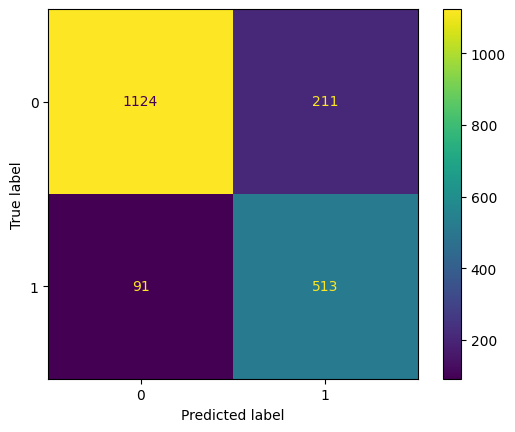

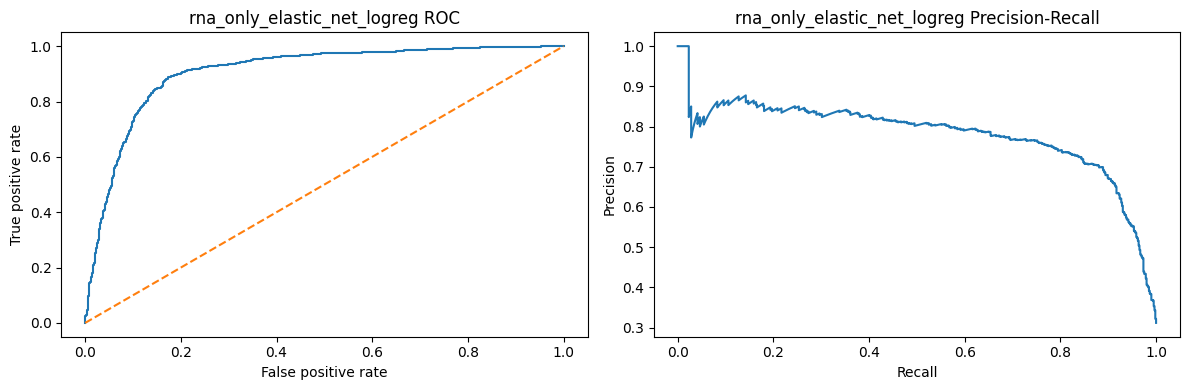

In [16]:
best_rna_artifact = rna_search["best_artifact"]
rna_test_proba = predict_rna_artifact(best_rna_artifact, X_rna_test)
rna_metrics = pd.Series({"model": "rna_only_elastic_net_logreg", **evaluate_from_proba(y_test, rna_test_proba)})

print()
print("rna_only_elastic_net_logreg")
display(rna_metrics.to_frame("value"))

rna_test_pred = (rna_test_proba >= 0.5).astype(int)
print("Confusion matrix:")
display(pd.DataFrame(confusion_matrix(y_test, rna_test_pred), index=["true_0", "true_1"], columns=["pred_0", "pred_1"]))
print("Classification report at fixed threshold 0.5:")
print(classification_report(y_test, rna_test_pred, digits=3))

ConfusionMatrixDisplay.from_predictions(y_test, rna_test_pred)
plt.show()
plot_roc_pr_curves(y_test, rna_test_proba, title_prefix="rna_only_elastic_net_logreg")

## 4.12 Task 1 holdout comparison and calibration diagnostics (TCGA)

,model,auroc,auprc,balanced_accuracy_at_0.5,f1_at_0.5,brier
0,rna_only_elastic_net_logreg,0.906072,0.781147,0.845643,0.772590,0.117760
1,metadata_only_cancer_type,0.824180,0.647466,0.749707,0.649492,0.179839
2,dummy_prior,0.500000,0.311501,0.500000,0.000000,0.214468


,model,auroc_ci_2.5,auroc_ci_50,auroc_ci_97.5,auprc_ci_2.5,auprc_ci_50,auprc_ci_97.5
0,metadata_only_cancer_type,0.805283,0.824262,0.843425,0.607292,0.648540,0.687486
1,rna_only_elastic_net_logreg,0.892131,0.906090,0.919558,0.744329,0.781759,0.817019


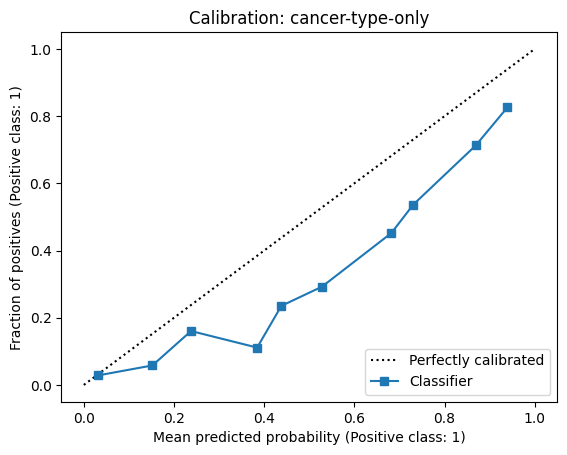

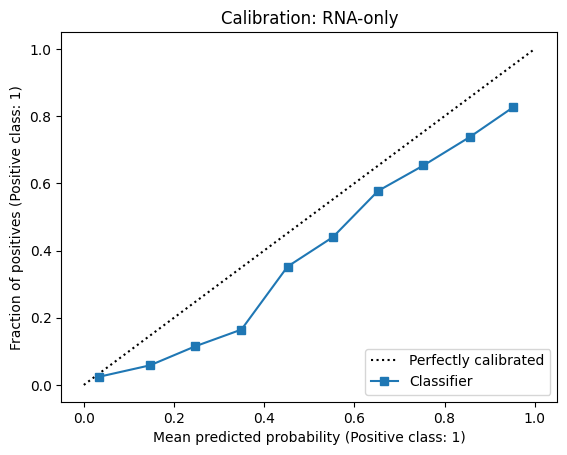

In [17]:
holdout_results = pd.DataFrame([dummy_metrics, meta_metrics, rna_metrics])
holdout_results = holdout_results.sort_values("auprc", ascending=False).reset_index(drop=True)
display(holdout_results)

ci_rows = []
for model_name, proba in [
    ("metadata_only_cancer_type", meta_test_proba),
    ("rna_only_elastic_net_logreg", rna_test_proba),
]:
    auroc_lo, auroc_med, auroc_hi = bootstrap_metric_ci(y_test, proba, roc_auc_score, n_boot=BOOTSTRAP_RESAMPLES, seed=RANDOM_STATE)
    auprc_lo, auprc_med, auprc_hi = bootstrap_metric_ci(y_test, proba, average_precision_score, n_boot=BOOTSTRAP_RESAMPLES, seed=RANDOM_STATE)
    ci_rows.append({
        "model": model_name,
        "auroc_ci_2.5": auroc_lo,
        "auroc_ci_50": auroc_med,
        "auroc_ci_97.5": auroc_hi,
        "auprc_ci_2.5": auprc_lo,
        "auprc_ci_50": auprc_med,
        "auprc_ci_97.5": auprc_hi,
    })

holdout_ci = pd.DataFrame(ci_rows)
display(holdout_ci)

CalibrationDisplay.from_predictions(y_test, meta_test_proba, n_bins=10)
plt.title("Calibration: cancer-type-only")
plt.show()

CalibrationDisplay.from_predictions(y_test, rna_test_proba, n_bins=10)
plt.title("Calibration: RNA-only")
plt.show()

## 4.13 Task 2 — multiclass TP53 mutation-type prediction (TCGA)

This section completes Task 2 for TCGA. It predicts `WT`, `missense`, and `truncating_or_splice` TP53 status from RNA expression. Because cancer type is the TCGA analogue of CCLE lineage and is a major confounder, the Task 2 split is stratified jointly by **mutation-type label** and **cancer type**. The section also reports a cancer-type-only baseline and an RNA + cancer-type model so that the RNA contribution to mutation-type discrimination can be assessed above and beyond cancer-type composition.

In [18]:
# ============================================================
# Task 2: true multiclass TP53 mutation-type prediction in TCGA
# ============================================================
# Methodological changes from the initial completed version:
#   * The Task 2 train/test split is stratified by mutation-type label and cancer type.
#   * Cancer type is the TCGA analogue of CCLE lineage.
#   * The model chosen for detailed reporting is selected by CV macro-F1, not by test macro-F1.
#   * A cancer-type-only baseline and an RNA+cancer-type model are included.

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

RUN_TASK2_COMBINED_MODEL = True


def make_stable_joint_strata(labels, groups, min_count=2, group_name="group"):
    """Create label+group strata, collapsing sparse group-label cells to a rare bucket.

    Stratified splitting fails if any stratum has too few samples. This helper keeps
    common label-cancer-type strata intact and collapses sparse cells within each label
    into a rare-cancer-type bucket. If that is still too sparse, it falls back to
    label-only strata and prints an explicit warning.
    """
    labels = pd.Series(labels).astype(str).reset_index(drop=True)
    groups = pd.Series(groups).astype(str).fillna("missing").replace({"nan": "missing"}).reset_index(drop=True)
    joint = labels + "__" + groups
    rare_joint = joint.value_counts().loc[lambda s: s < int(min_count)].index

    groups_collapsed = groups.copy()
    groups_collapsed.loc[joint.isin(rare_joint)] = f"RARE_{group_name.upper()}"
    joint_collapsed = labels + "__" + groups_collapsed

    if joint_collapsed.value_counts().min() < int(min_count):
        print(
            f"Warning: some label-{group_name} strata remain too small for min_count={min_count}; "
            "falling back to label-only stratification for this split/CV object."
        )
        return labels

    return joint_collapsed


def align_task2_proba_from_classes(raw_proba, est_classes, labels):
    labels = list(labels)
    est_classes = list(est_classes)
    out = np.zeros((raw_proba.shape[0], len(labels)), dtype=float)
    for j, cls in enumerate(labels):
        if cls in est_classes:
            out[:, j] = raw_proba[:, est_classes.index(cls)]
    out = out / np.clip(out.sum(axis=1, keepdims=True), 1e-12, None)
    return out


def evaluate_multiclass(y_true, proba, labels):
    y_true = pd.Series(y_true).astype(str).to_numpy()
    labels = list(labels)
    y_pred = np.asarray(labels, dtype=object)[np.argmax(proba, axis=1)]

    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    try:
        y_bin = label_binarize(y_true, classes=labels)
        out["ovr_auroc_macro"] = roc_auc_score(y_bin, proba, average="macro", multi_class="ovr")
        out["ovr_auprc_macro"] = average_precision_score(y_bin, proba, average="macro")
    except Exception as exc:
        out["ovr_auroc_macro"] = np.nan
        out["ovr_auprc_macro"] = np.nan
        out["auc_note"] = repr(exc)

    return out, y_pred


def multiclass_report_df(y_true, y_pred, labels):
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).T.reset_index().rename(columns={"index": "class"})


def fit_multiclass_logreg_ready(X_train_ready, y_train, C, l1_ratio):
    clf = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=SKLEARN_MAX_ITER,
        tol=SAGA_TOL,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        C=float(C),
        l1_ratio=float(l1_ratio),
    )
    clf.fit(np.asarray(X_train_ready, dtype=np.float64), y_train)
    return clf


def fit_task2_rna_logreg_artifact(X_train, y_train, params):
    preproc = fit_rna_preprocessor(X_train, y_train, params=params)
    X_ready = transform_rna_preprocessor(preproc, X_train)
    clf = fit_multiclass_logreg_ready(
        X_ready,
        y_train,
        C=params["C"],
        l1_ratio=params["l1_ratio"],
    )
    return {
        "kind": "task2_rna_logreg",
        "params": dict(params),
        "preproc": preproc,
        "model": clf,
    }


def fit_task2_rna_rf_artifact(X_train, y_train, params):
    preproc = fit_rna_preprocessor(X_train, y_train, params=params)
    X_ready = transform_rna_preprocessor(preproc, X_train)
    clf = RandomForestClassifier(
        n_estimators=int(params.get("n_estimators", 400)),
        max_depth=params.get("max_depth", 16),
        min_samples_leaf=int(params.get("min_samples_leaf", 2)),
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    clf.fit(X_ready, y_train)
    return {
        "kind": "task2_rna_random_forest",
        "params": dict(params),
        "preproc": preproc,
        "model": clf,
    }


def predict_task2_rna_artifact(artifact, X, labels):
    X_ready = transform_rna_preprocessor(artifact["preproc"], X)
    raw = artifact["model"].predict_proba(X_ready)
    return align_task2_proba_from_classes(raw, artifact["model"].classes_, labels)


def fit_task2_combo_logreg_artifact(X_meta_train, X_rna_train, y_train, params):
    encoder = fit_meta_encoder(X_meta_train)
    X_meta_ready = transform_meta_encoder(encoder, X_meta_train)

    rna_preproc = fit_rna_preprocessor(X_rna_train, y_train, params=params)
    X_rna_ready = transform_rna_preprocessor(rna_preproc, X_rna_train)

    X_ready = np.ascontiguousarray(
        np.concatenate([X_meta_ready, X_rna_ready], axis=1),
        dtype=np.float32,
    )
    clf = fit_multiclass_logreg_ready(
        X_ready,
        y_train,
        C=params["C"],
        l1_ratio=params["l1_ratio"],
    )
    return {
        "kind": "task2_rna_plus_cancer_type_logreg",
        "params": dict(params),
        "encoder": encoder,
        "rna_preproc": rna_preproc,
        "model": clf,
    }


def predict_task2_combo_artifact(artifact, X_meta, X_rna, labels):
    X_meta_ready = transform_meta_encoder(artifact["encoder"], X_meta)
    X_rna_ready = transform_rna_preprocessor(artifact["rna_preproc"], X_rna)
    X_ready = np.ascontiguousarray(
        np.concatenate([X_meta_ready, X_rna_ready], axis=1),
        dtype=np.float32,
    )
    raw = artifact["model"].predict_proba(X_ready)
    return align_task2_proba_from_classes(raw, artifact["model"].classes_, labels)


def task2_cv_search(model_name, fit_fn, predict_fn, param_grid, X_fit, y_fit, labels, cv):
    rows = []
    best_score = -np.inf
    best_params = None

    for params in list(ParameterGrid(param_grid)):
        fold_scores = []
        for tr, va in cv:
            artifact = fit_fn(X_fit[tr], y_fit[tr], params)
            proba = predict_fn(artifact, X_fit[va], labels)
            metrics, _ = evaluate_multiclass(y_fit[va], proba, labels)
            fold_scores.append(metrics["macro_f1"])
            del artifact, proba
            gc.collect()

        mean_macro_f1 = float(np.mean(fold_scores))
        rows.append({
            "model": model_name,
            "params": dict(params),
            "cv_macro_f1": mean_macro_f1,
        })
        if mean_macro_f1 > best_score:
            best_score = mean_macro_f1
            best_params = dict(params)

    final_artifact = fit_fn(X_fit, y_fit, best_params)
    return {
        "model": model_name,
        "best_params": best_params,
        "best_cv_macro_f1": float(best_score),
        "cv_results": pd.DataFrame(rows),
        "artifact": final_artifact,
    }


def task2_combo_cv_search(model_name, param_grid, X_meta_fit, X_rna_fit, y_fit, labels, cv):
    rows = []
    best_score = -np.inf
    best_params = None

    for params in list(ParameterGrid(param_grid)):
        fold_scores = []
        for tr, va in cv:
            artifact = fit_task2_combo_logreg_artifact(
                X_meta_fit.iloc[tr],
                X_rna_fit[tr],
                y_fit[tr],
                params,
            )
            proba = predict_task2_combo_artifact(
                artifact,
                X_meta_fit.iloc[va],
                X_rna_fit[va],
                labels,
            )
            metrics, _ = evaluate_multiclass(y_fit[va], proba, labels)
            fold_scores.append(metrics["macro_f1"])
            del artifact, proba
            gc.collect()

        mean_macro_f1 = float(np.mean(fold_scores))
        rows.append({
            "model": model_name,
            "params": dict(params),
            "cv_macro_f1": mean_macro_f1,
        })
        if mean_macro_f1 > best_score:
            best_score = mean_macro_f1
            best_params = dict(params)

    final_artifact = fit_task2_combo_logreg_artifact(X_meta_fit, X_rna_fit, y_fit, best_params)
    return {
        "model": model_name,
        "best_params": best_params,
        "best_cv_macro_f1": float(best_score),
        "cv_results": pd.DataFrame(rows),
        "artifact": final_artifact,
    }


task2_labels = ["WT", "missense", "truncating_or_splice"]

task2_indices = model_meta_task2.index.to_numpy()
X_rna_task2 = X_rna[task2_indices]
X_meta_task2 = model_meta_task2[[CANCER_TYPE_COL]].copy().reset_index(drop=True)
X_meta_task2[CANCER_TYPE_COL] = X_meta_task2[CANCER_TYPE_COL].astype(str).fillna("missing").replace({"nan": "missing"})
y_task2 = model_meta_task2["TP53_task2_label"].astype(str).to_numpy()
groups_task2 = model_meta_task2[CANCER_TYPE_COL].astype(str).to_numpy()

task2_all_pos = np.arange(len(y_task2))
task2_strata_all = make_stable_joint_strata(
    labels=y_task2,
    groups=groups_task2,
    min_count=2,
    group_name="cancer_type",
)

task2_train_pos, task2_test_pos = train_test_split(
    task2_all_pos,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=task2_strata_all,
)

X2_train = X_rna_task2[task2_train_pos]
X2_test = X_rna_task2[task2_test_pos]
X2_meta_train = X_meta_task2.iloc[task2_train_pos]
X2_meta_test = X_meta_task2.iloc[task2_test_pos]
y2_train = y_task2[task2_train_pos]
y2_test = y_task2[task2_test_pos]
g2_train = groups_task2[task2_train_pos]
g2_test = groups_task2[task2_test_pos]

task2_split_counts = pd.concat(
    {
        "train": pd.Series(y2_train).value_counts().reindex(task2_labels),
        "test": pd.Series(y2_test).value_counts().reindex(task2_labels),
    },
    axis=1,
).fillna(0).astype(int)

task2_cancer_split_counts = pd.concat(
    {
        "train": pd.Series(g2_train).value_counts(),
        "test": pd.Series(g2_test).value_counts(),
    },
    axis=1,
).fillna(0).astype(int).sort_values("train", ascending=False)

print("TCGA Task 2 split counts using label-cancer-type stratification:")
display(task2_split_counts)
print("TCGA Task 2 cancer-type split counts, top 20 cancer types:")
display(task2_cancer_split_counts.head(20))
print("Cancer types absent from Task 2 train but present in test:", sorted(set(g2_test) - set(g2_train)))
print("Cancer types absent from Task 2 test but present in train:", sorted(set(g2_train) - set(g2_test))[:10])

task2_cv_n = min(INNER_CV_SPLITS, int(pd.Series(y2_train).value_counts().min()))
task2_train_cv_strata = make_stable_joint_strata(
    labels=y2_train,
    groups=g2_train,
    min_count=task2_cv_n,
    group_name="cancer_type",
)
task2_cv = list(
    StratifiedKFold(n_splits=task2_cv_n, shuffle=True, random_state=RANDOM_STATE).split(
        np.zeros(len(y2_train)),
        task2_train_cv_strata,
    )
)

TASK2_LOGREG_GRID = {
    "top_k": [5000],
    "k_select": [500, 1000],
    "scaler": ["maxabs"],
    "C": [0.03, 0.1, 0.3],
    "l1_ratio": [0.0, 0.5],
}

TASK2_RF_GRID = {
    "top_k": [5000],
    "k_select": [500, 1000],
    "scaler": ["maxabs"],
    "n_estimators": [400],
    "max_depth": [12, 20],
    "min_samples_leaf": [2],
}

# Baseline 1: empirical class prior.
task2_dummy = DummyClassifier(strategy="prior")
task2_dummy.fit(np.zeros((len(y2_train), 1)), y2_train)
task2_dummy_raw = task2_dummy.predict_proba(np.zeros((len(y2_test), 1)))
task2_dummy_proba = align_task2_proba_from_classes(task2_dummy_raw, task2_dummy.classes_, task2_labels)
task2_dummy_metrics, task2_dummy_pred = evaluate_multiclass(y2_test, task2_dummy_proba, task2_labels)

# Baseline 2: cancer-type-only model. This is essential because mutation type may be confounded by tumour type.
task2_meta_pipe = Pipeline([
    (
        "prep",
        ColumnTransformer(
            transformers=[
                ("cancer_type", make_onehot_encoder(), [CANCER_TYPE_COL]),
            ],
            remainder="drop",
        ),
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=SKLEARN_MAX_ITER,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_STATE,
        ),
    ),
])

task2_meta_grid = GridSearchCV(
    estimator=task2_meta_pipe,
    param_grid={"clf__C": META_C_GRID},
    scoring="f1_macro",
    cv=task2_cv,
    n_jobs=1,
    pre_dispatch=1,
    refit=True,
)
task2_meta_grid.fit(X2_meta_train, y2_train)
task2_meta_raw = task2_meta_grid.best_estimator_.predict_proba(X2_meta_test)
task2_meta_proba = align_task2_proba_from_classes(
    task2_meta_raw,
    task2_meta_grid.best_estimator_.classes_,
    task2_labels,
)
task2_meta_metrics, task2_meta_pred = evaluate_multiclass(y2_test, task2_meta_proba, task2_labels)

# RNA-only models.
task2_logreg_search = task2_cv_search(
    "task2_rna_multinomial_logreg",
    fit_task2_rna_logreg_artifact,
    predict_task2_rna_artifact,
    TASK2_LOGREG_GRID,
    X2_train,
    y2_train,
    task2_labels,
    task2_cv,
)

task2_rf_search = task2_cv_search(
    "task2_rna_random_forest",
    fit_task2_rna_rf_artifact,
    predict_task2_rna_artifact,
    TASK2_RF_GRID,
    X2_train,
    y2_train,
    task2_labels,
    task2_cv,
)

# RNA + cancer-type model. Keep the grid compact by reusing the RNA logreg grid.
if RUN_TASK2_COMBINED_MODEL:
    task2_combo_search = task2_combo_cv_search(
        "task2_rna_plus_cancer_type_logreg",
        TASK2_LOGREG_GRID,
        X2_meta_train,
        X2_train,
        y2_train,
        task2_labels,
        task2_cv,
    )
else:
    task2_combo_search = None

task2_rows = [
    {
        "model": "task2_dummy_prior",
        "tier": "baseline",
        "best_cv_macro_f1": np.nan,
        "selection_macro_f1": np.nan,
        "best_params": {},
        **{f"test_{k}": v for k, v in task2_dummy_metrics.items()},
    },
    {
        "model": "task2_cancer_type_only_logreg",
        "tier": "metadata_only",
        "best_cv_macro_f1": float(task2_meta_grid.best_score_),
        "selection_macro_f1": float(task2_meta_grid.best_score_),
        "best_params": task2_meta_grid.best_params_,
        **{f"test_{k}": v for k, v in task2_meta_metrics.items()},
    },
]

task2_predictions = {
    "task2_dummy_prior": task2_dummy_pred,
    "task2_cancer_type_only_logreg": task2_meta_pred,
}
task2_artifacts = {
    "task2_cancer_type_only_logreg": task2_meta_grid.best_estimator_,
    "task2_rna_multinomial_logreg": task2_logreg_search["artifact"],
    "task2_rna_random_forest": task2_rf_search["artifact"],
}

for search in [task2_logreg_search, task2_rf_search]:
    proba = predict_task2_rna_artifact(search["artifact"], X2_test, task2_labels)
    metrics, pred = evaluate_multiclass(y2_test, proba, task2_labels)
    task2_rows.append({
        "model": search["model"],
        "tier": "rna_only",
        "best_cv_macro_f1": search["best_cv_macro_f1"],
        "selection_macro_f1": search["best_cv_macro_f1"],
        "best_params": search["best_params"],
        **{f"test_{k}": v for k, v in metrics.items()},
    })
    task2_predictions[search["model"]] = pred

if task2_combo_search is not None:
    combo_proba = predict_task2_combo_artifact(
        task2_combo_search["artifact"],
        X2_meta_test,
        X2_test,
        task2_labels,
    )
    combo_metrics, combo_pred = evaluate_multiclass(y2_test, combo_proba, task2_labels)
    task2_rows.append({
        "model": task2_combo_search["model"],
        "tier": "rna_plus_metadata",
        "best_cv_macro_f1": task2_combo_search["best_cv_macro_f1"],
        "selection_macro_f1": task2_combo_search["best_cv_macro_f1"],
        "best_params": task2_combo_search["best_params"],
        **{f"test_{k}": v for k, v in combo_metrics.items()},
    })
    task2_predictions[task2_combo_search["model"]] = combo_pred
    task2_artifacts[task2_combo_search["model"]] = task2_combo_search["artifact"]

tcga_task2_results = pd.DataFrame(task2_rows)
tcga_task2_results["selection_rank"] = tcga_task2_results["selection_macro_f1"].rank(
    method="first",
    ascending=False,
    na_option="bottom",
).astype(int)
tcga_task2_results = tcga_task2_results.sort_values("selection_rank").reset_index(drop=True)

display(tcga_task2_results)

selectable = tcga_task2_results.loc[tcga_task2_results["selection_macro_f1"].notna()].copy()
best_tcga_task2_model = selectable.iloc[0]["model"]
best_tcga_task2_pred = task2_predictions[best_tcga_task2_model]

tcga_task2_confusion = pd.DataFrame(
    confusion_matrix(y2_test, best_tcga_task2_pred, labels=task2_labels),
    index=[f"true_{x}" for x in task2_labels],
    columns=[f"pred_{x}" for x in task2_labels],
)

tcga_task2_report = multiclass_report_df(
    y2_test,
    best_tcga_task2_pred,
    task2_labels,
)

print(f"Best TCGA Task 2 model by CV macro-F1: {best_tcga_task2_model}")
display(tcga_task2_confusion)
display(tcga_task2_report.round(4))

# Optional cancer-type-grouped check for Task 2.
# This is reported as a robustness check because mutation-type classes can be sparse in held-out cancer groups.
tcga_task2_grouped_results = pd.DataFrame()
tcga_task2_grouped_summary = pd.DataFrame()

min_task2_class_n = int(pd.Series(y_task2).value_counts().min())
n_grouped_splits = min(GROUP_CV_SPLITS, len(np.unique(groups_task2)), min_task2_class_n)

if n_grouped_splits >= 3:
    grouped_rows = []
    grouped_cv_task2 = StratifiedGroupKFold(
        n_splits=n_grouped_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    for fold, (tr, te) in enumerate(grouped_cv_task2.split(X_rna_task2, y_task2, groups_task2), start=1):
        y_tr, y_te = y_task2[tr], y_task2[te]
        if set(task2_labels) - set(y_tr) or set(task2_labels) - set(y_te):
            grouped_rows.append({
                "fold": fold,
                "model": "task2_rna_multinomial_logreg",
                "status": "skipped_missing_class_in_train_or_test",
                "n_test": len(te),
            })
            continue
        artifact = fit_task2_rna_logreg_artifact(
            X_rna_task2[tr],
            y_tr,
            task2_logreg_search["best_params"],
        )
        proba = predict_task2_rna_artifact(artifact, X_rna_task2[te], task2_labels)
        metrics, _ = evaluate_multiclass(y_te, proba, task2_labels)
        grouped_rows.append({
            "fold": fold,
            "model": "task2_rna_multinomial_logreg",
            "status": "ok",
            "n_test": len(te),
            **metrics,
        })
    tcga_task2_grouped_results = pd.DataFrame(grouped_rows)
    display(tcga_task2_grouped_results)
    ok_grouped = tcga_task2_grouped_results.loc[tcga_task2_grouped_results["status"].eq("ok")]
    if len(ok_grouped) > 0:
        tcga_task2_grouped_summary = ok_grouped.groupby("model")[[
            "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "ovr_auroc_macro", "ovr_auprc_macro"
        ]].agg(["mean", "std"])
        display(tcga_task2_grouped_summary)
else:
    print("Skipping TCGA Task 2 grouped CV because class or cancer-type support is too sparse.")

# Save Task 2 outputs immediately so they are available even if later optional sections are skipped.
task2_raw_counts.to_csv("tcga_task2_raw_class_counts.csv")
task2_candidate_counts.to_csv("tcga_task2_collapsed_class_counts.csv")
task2_split_counts.to_csv("tcga_task2_split_class_counts.csv")
task2_cancer_split_counts.to_csv("tcga_task2_cancer_type_split_counts.csv")
tcga_task2_results.to_csv("tcga_task2_test_results.csv", index=False)
tcga_task2_confusion.to_csv("tcga_task2_confusion_matrix.csv")
tcga_task2_report.to_csv("tcga_task2_classification_report.csv", index=False)

task2_cv_result_frames = [
    task2_logreg_search["cv_results"],
    task2_rf_search["cv_results"],
]
if task2_combo_search is not None:
    task2_cv_result_frames.append(task2_combo_search["cv_results"])
pd.concat(task2_cv_result_frames, ignore_index=True).to_csv("tcga_task2_cv_results.csv", index=False)

if len(tcga_task2_grouped_results) > 0:
    tcga_task2_grouped_results.to_csv("tcga_task2_grouped_cv_results.csv", index=False)
if len(tcga_task2_grouped_summary) > 0:
    tcga_task2_grouped_summary.to_csv("tcga_task2_grouped_cv_summary.csv")


TCGA Task 2 split counts using label-cancer-type stratification:


,train,test
WT,5309,1327
missense,1518,380
truncating_or_splice,845,212


TCGA Task 2 cancer-type split counts, top 20 cancer types:


,train,test
BRCA,868,218
KIRC,423,106
THCA,404,100
HNSC,403,102
LGG,401,101
LUAD,400,101
PRAD,397,98
LUSC,379,95
SKCM,370,92
OV,338,84


Cancer types absent from Task 2 train but present in test: []
Cancer types absent from Task 2 test but present in train: []


...

Best TCGA Task 2 model by CV macro-F1: task2_rna_plus_cancer_type_logreg


,pred_WT,pred_missense,pred_truncating_or_splice
true_WT,1112,117,98
true_missense,64,180,136
true_truncating_or_splice,23,97,92


,class,precision,recall,f1-score,support
0,WT,0.9274,0.8380,0.8804,1327.0000
1,missense,0.4569,0.4737,0.4651,380.0000
2,truncating_or_splice,0.2822,0.4340,0.3420,212.0000
3,accuracy,0.7212,0.7212,0.7212,0.7212
4,macro avg,0.5555,0.5819,0.5625,1919.0000
5,weighted avg,0.7630,0.7212,0.7387,1919.0000


,fold,model,status,n_test,accuracy,balanced_accuracy,macro_f1,weighted_f1,ovr_auroc_macro,ovr_auprc_macro
0,1,task2_rna_multinomial_logreg,ok,1238,0.678514,0.579838,0.568087,0.692594,0.816641,0.565728
1,2,task2_rna_multinomial_logreg,ok,2059,0.544925,0.468218,0.452187,0.573540,0.694469,0.477045
2,3,task2_rna_multinomial_logreg,ok,1776,0.559685,0.472128,0.387062,0.634917,0.708705,0.413829
3,4,task2_rna_multinomial_logreg,ok,2480,0.529839,0.457215,0.437248,0.542245,0.700771,0.467932
4,5,task2_rna_multinomial_logreg,ok,2038,0.790481,0.437673,0.431517,0.788074,0.755668,0.436724


accuracy           balanced_accuracy            \
                                  mean       std              mean       std   
model                                                                          
task2_rna_multinomial_logreg  0.620689  0.111679          0.483015  0.055753   

                             macro_f1           weighted_f1            \
                                 mean       std        mean       std   
model                                                                   
task2_rna_multinomial_logreg  0.45522  0.067599    0.646274  0.098099   

                             ovr_auroc_macro           ovr_auprc_macro  \
                                        mean       std            mean   
model                                                                    
task2_rna_multinomial_logreg        0.735251  0.051473        0.472252   

                                        
                                   std  
model                                   
task2_rna_multinomial_logreg  0.057997

## 4.14 Cancer-type-grouped evaluation across all baselines

This is the main anti-confounding section for Task 1.

By default, the grouped evaluation uses **nested tuning** with a smaller pre-specified grouped grid. This avoids selecting RNA hyperparameters on the random pan-cancer holdout and then reusing them inside cancer-type-held-out folds.

For a faster demonstration the shortcut

```python
GROUPED_TUNING_MODE = "reuse_holdout_best"
```

reuses random-holdout hyperparameters. When that shortcut is used the grouped results are reported as a robustness check rather than the strictest generalisation estimate.

In [19]:
if RUN_GROUPED_CV:
    if RUN_COMBINED_MODEL and GROUPED_TUNING_MODE != "nested" and combo_search is None:
        print("Computing combined-model random-holdout CV search before reuse-based grouped evaluation.")
        combo_search = manual_cv_search_combo(
            X_meta=X_meta_train,
            X_rna=X_rna_train,
            y=y_train,
            splitter=inner_cv,
            param_grid=COMBO_PARAM_GRID,
            search_backend=GPU_SEARCH_BACKEND,
            refit_backend=FINAL_REFIT_BACKEND,
            groups=None,
            verbose=1,
            label="COMBO",
        )

    group_outer = StratifiedGroupKFold(
        n_splits=GROUP_CV_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    group_inner = StratifiedGroupKFold(
        n_splits=max(3, GROUP_CV_SPLITS - 1),
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    group_rows = []

    for fold, (tr_idx, te_idx) in enumerate(group_outer.split(X_meta, y, groups), start=1):
        y_tr, y_te = y[tr_idx], y[te_idx]
        g_tr = groups[tr_idx]

        X_meta_tr = subset_X(X_meta, tr_idx)
        X_meta_te = subset_X(X_meta, te_idx)
        X_rna_tr = X_rna[tr_idx]
        X_rna_te = X_rna[te_idx]

        # Dummy
        dummy = DummyClassifier(strategy="prior")
        dummy.fit(np.zeros((len(tr_idx), 1)), y_tr)
        dummy_proba = dummy.predict_proba(np.zeros((len(te_idx), 1)))[:, 1]
        group_rows.append({
            "fold": fold,
            "model": "dummy_prior",
            **evaluate_from_proba(y_te, dummy_proba),
        })

        # Metadata-only
        meta_search = GridSearchCV(
            estimator=meta_pipe,
            param_grid={"clf__C": META_C_GRID},
            scoring="average_precision",
            cv=group_inner,
            n_jobs=1,
            pre_dispatch=1,
            refit=True,
        )
        meta_search.fit(X_meta_tr, y_tr, groups=g_tr)
        meta_proba = meta_search.best_estimator_.predict_proba(X_meta_te)[:, 1]
        group_rows.append({
            "fold": fold,
            "model": "metadata_only_cancer_type",
            **evaluate_from_proba(y_te, meta_proba),
        })

        # RNA-only
        if GROUPED_TUNING_MODE == "nested":
            rna_group_search = manual_cv_search_rna(
                X=X_rna_tr,
                y=y_tr,
                splitter=group_inner,
                param_grid=GROUPED_RNA_PARAM_GRID,
                search_backend=GPU_SEARCH_BACKEND,
                refit_backend=FINAL_REFIT_BACKEND,
                groups=g_tr,
                verbose=0,
                label=f"RNA_GROUP_FOLD_{fold}",
            )
            rna_group_artifact = rna_group_search["best_artifact"]
        else:
            rna_group_artifact = fit_rna_artifact(
                X_train=X_rna_tr,
                y_train=y_tr,
                params=rna_search["best_params"],
                backend=FINAL_REFIT_BACKEND,
            )
        rna_group_proba = predict_rna_artifact(rna_group_artifact, X_rna_te)
        group_rows.append({
            "fold": fold,
            "model": "rna_only_elastic_net_logreg",
            **evaluate_from_proba(y_te, rna_group_proba),
        })

        # Combined model
        if RUN_COMBINED_MODEL:
            if GROUPED_TUNING_MODE == "nested":
                combo_group_search = manual_cv_search_combo(
                    X_meta=X_meta_tr,
                    X_rna=X_rna_tr,
                    y=y_tr,
                    splitter=group_inner,
                    param_grid=GROUPED_COMBO_PARAM_GRID,
                    search_backend=GPU_SEARCH_BACKEND,
                    refit_backend=FINAL_REFIT_BACKEND,
                    groups=g_tr,
                    verbose=0,
                    label=f"COMBO_GROUP_FOLD_{fold}",
                )
                combo_group_artifact = combo_group_search["best_artifact"]
            else:
                combo_best_params = combo_search["best_params"] if combo_search is not None else rna_search["best_params"]
                combo_group_artifact = fit_combo_artifact(
                    X_meta_train=X_meta_tr,
                    X_rna_train=X_rna_tr,
                    y_train=y_tr,
                    params=combo_best_params,
                    backend=FINAL_REFIT_BACKEND,
                )
            combo_group_proba = predict_combo_artifact(combo_group_artifact, X_meta_te, X_rna_te)
            group_rows.append({
                "fold": fold,
                "model": "rna_plus_cancer_type",
                **evaluate_from_proba(y_te, combo_group_proba),
            })

        print(f"Completed grouped outer fold {fold}/{GROUP_CV_SPLITS}")

    group_results = pd.DataFrame(group_rows)
    display(group_results)

    group_summary = (
        group_results
        .groupby("model")[["auroc", "auprc", "balanced_accuracy_at_0.5", "f1_at_0.5", "brier"]]
        .agg(["mean", "std"])
    )
    display(group_summary)
else:
    print("RUN_GROUPED_CV is False; skipping grouped evaluation.")

Completed grouped outer fold 1/5
Completed grouped outer fold 2/5
Completed grouped outer fold 3/5
Completed grouped outer fold 4/5
Completed grouped outer fold 5/5


,fold,model,auroc,auprc,balanced_accuracy_at_0.5,f1_at_0.5,brier
0,1,dummy_prior,0.500000,0.588614,0.500000,0.000000,0.336051
1,1,metadata_only_cancer_type,0.500000,0.588614,0.500000,0.000000,0.256804
2,1,rna_only_elastic_net_logreg,0.797750,0.809952,0.740154,0.821577,0.176204
3,1,rna_plus_cancer_type,0.800337,0.811172,0.747594,0.825978,0.173460
4,2,dummy_prior,0.500000,0.451990,0.500000,0.000000,0.281679
5,2,metadata_only_cancer_type,0.500000,0.451990,0.500000,0.000000,0.247983
6,2,rna_only_elastic_net_logreg,0.618453,0.512707,0.611648,0.627309,0.297856
7,2,rna_plus_cancer_type,0.623002,0.514892,0.615993,0.637931,0.296706
8,3,dummy_prior,0.500000,0.284592,0.500000,0.000000,0.205097
9,3,metadata_only_cancer_type,0.500000,0.284592,0.500000,0.000000,0.232910


auroc               auprc            \
                                 mean       std      mean       std   
model                                                                 
dummy_prior                  0.500000  0.000000  0.332381  0.185075   
metadata_only_cancer_type    0.500000  0.000000  0.332381  0.185075   
rna_only_elastic_net_logreg  0.780009  0.093427  0.602575  0.120119   
rna_plus_cancer_type         0.780837  0.090805  0.601406  0.120098   

                            balanced_accuracy_at_0.5           f1_at_0.5  \
                                                mean       std      mean   
model                                                                      
dummy_prior                                 0.500000  0.000000  0.000000   
metadata_only_cancer_type                   0.500000  0.000000  0.000000   
rna_only_elastic_net_logreg                 0.715125  0.063075  0.610674   
rna_plus_cancer_type                        0.717034  0.061342  0.612318   

                                          brier            
                                  std      mean       std  
model                                                      
dummy_prior                  0.000000  0.232892  0.073417  
metadata_only_cancer_type    0.000000  0.242255  0.009920  
rna_only_elastic_net_logreg  0.128909  0.196792  0.056650  
rna_plus_cancer_type         0.132889  0.196949  0.055985

## 4.15 Inspect RNA coefficients and biological sanity checks

This section strips Ensembl version suffixes, optionally maps to gene symbols, and reports overlap of the top coefficients with the curated TP53 target list (Fischer 2017; consistent with https://p53.fr and https://tp53.cancer.gov). Interpretation is reported cautiously: predictive correlation does not imply biological causation, and pan-cancer signals can reflect lineage composition.

In [20]:
best_rna_preproc = best_rna_artifact["preproc"]
final_features = extract_rna_feature_names(best_rna_preproc, gene_ids)
coef = np.asarray(best_rna_artifact["model"].coef_).ravel()

coef_df = pd.DataFrame({
    "ensembl_gene_id": final_features,
    "coefficient": coef,
})
coef_df["ensembl_gene_id_no_version"] = coef_df["ensembl_gene_id"].astype(str).str.replace(r"\..*$", "", regex=True)

def infer_ensembl_col(df):
    candidates = [
        "ensembl_gene_id", "ensembl_gene_id_no_version", "Ensembl", "ENSEMBL",
        "gene_id", "id", "feature_id",
    ]
    for col in candidates:
        if col in df.columns:
            return col
    return None

def infer_symbol_col(df):
    candidates = [
        "gene_symbol", "symbol", "gene", "Gene", "HugoSymbol", "hgnc_symbol",
        "approved_symbol", "gene_name",
    ]
    for col in candidates:
        if col in df.columns:
            return col
    return None

def parse_symbol_from_feature_id(x):
    parts = [p.strip() for p in str(x).split("|")]
    for part in parts:
        if part and not looks_like_ensembl(part):
            return part
    return np.nan

# Fallback: if feature IDs themselves carry symbols, use them.
coef_df["gene_symbol"] = coef_df["ensembl_gene_id"].map(parse_symbol_from_feature_id)

annotation_loaded = False
if GENE_ANNOTATION_PATH is not None:
    gene_annot = pd.read_csv(GENE_ANNOTATION_PATH, sep=None, engine="python", low_memory=False)
    annot_ensembl_col = infer_ensembl_col(gene_annot)
    annot_symbol_col = infer_symbol_col(gene_annot)
    if annot_ensembl_col is not None and annot_symbol_col is not None:
        gene_map = gene_annot[[annot_ensembl_col, annot_symbol_col]].copy()
        gene_map.columns = ["ensembl_gene_id_raw", "gene_symbol_from_annotation"]
        gene_map["ensembl_gene_id_no_version"] = gene_map["ensembl_gene_id_raw"].astype(str).str.replace(r"\..*$", "", regex=True)
        gene_map = gene_map.dropna(subset=["gene_symbol_from_annotation"]).drop_duplicates("ensembl_gene_id_no_version")
        coef_df = coef_df.merge(
            gene_map[["ensembl_gene_id_no_version", "gene_symbol_from_annotation"]],
            on="ensembl_gene_id_no_version",
            how="left",
        )
        coef_df["gene_symbol"] = coef_df["gene_symbol"].fillna(coef_df["gene_symbol_from_annotation"])
        annotation_loaded = True

coef_df["is_tp53_target"] = False
if TP53_TARGETS_PATH is not None and TP53_TARGETS_PATH.exists():
    tp53_targets = pd.read_csv(TP53_TARGETS_PATH, low_memory=False)
    target_ensembl_col = infer_ensembl_col(tp53_targets)
    target_symbol_col = infer_symbol_col(tp53_targets)

    if target_ensembl_col is not None:
        target_ids = (
            tp53_targets[target_ensembl_col]
            .astype(str)
            .str.replace(r"\..*$", "", regex=True)
            .dropna()
            .unique()
        )
        coef_df["is_tp53_target"] = coef_df["ensembl_gene_id_no_version"].isin(target_ids)
    if target_symbol_col is not None:
        target_symbols = set(tp53_targets[target_symbol_col].astype(str).str.upper().dropna())
        coef_df["is_tp53_target"] = coef_df["is_tp53_target"] | coef_df["gene_symbol"].astype(str).str.upper().isin(target_symbols)

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("coefficient", ascending=False).reset_index(drop=True)

print("Gene symbol annotation loaded:", annotation_loaded)
print("Top positive coefficients:")
display(coef_df.head(TOP_COEFS_TO_SHOW))

print("Top negative coefficients:")
display(coef_df.tail(TOP_COEFS_TO_SHOW).sort_values("coefficient"))

print("Largest absolute coefficients:")
display(coef_df.sort_values("abs_coefficient", ascending=False).head(TOP_COEFS_TO_SHOW))

print("TP53-target overlap among selected RNA features:", int(coef_df["is_tp53_target"].sum()))

canonical_tp53_pathway = ["TP53", "MDM2", "CDKN1A", "BAX", "DDB2", "XPC", "FDXR", "RPS27L", "DRAM1", "EDA2R"]
canonical_hits = coef_df.loc[coef_df["gene_symbol"].astype(str).str.upper().isin(canonical_tp53_pathway)].copy()
print("Canonical TP53 pathway genes selected:", len(canonical_hits))
display(canonical_hits.sort_values("abs_coefficient", ascending=False))

Gene symbol annotation loaded: False
Top positive coefficients:


,ensembl_gene_id,coefficient,ensembl_gene_id_no_version,gene_symbol,is_tp53_target,abs_coefficient
0,ENSG00000203812.2,0.714519,ENSG00000203812,NaN,False,0.714519
1,ENSG00000101349.16,0.488077,ENSG00000101349,NaN,False,0.488077
2,ENSG00000215221.2,0.399798,ENSG00000215221,NaN,False,0.399798
3,ENSG00000187527.10,0.392797,ENSG00000187527,NaN,False,0.392797
4,ENSG00000249413.2,0.392514,ENSG00000249413,NaN,False,0.392514
5,ENSG00000232480.1,0.351793,ENSG00000232480,NaN,False,0.351793
6,ENSG00000240990.9,0.343323,ENSG00000240990,NaN,False,0.343323
7,ENSG00000080166.15,0.339074,ENSG00000080166,NaN,False,0.339074
8,ENSG00000184486.8,0.314856,ENSG00000184486,NaN,False,0.314856
9,ENSG00000266578.1,0.313765,ENSG00000266578,NaN,False,0.313765


Top negative coefficients:


,ensembl_gene_id,coefficient,ensembl_gene_id_no_version,gene_symbol,is_tp53_target,abs_coefficient
1999,ENSG00000228528.1,-1.417922,ENSG00000228528,NaN,False,1.417922
1998,ENSG00000251095.6,-1.237967,ENSG00000251095,NaN,False,1.237967
1997,ENSG00000250337.5,-1.031092,ENSG00000250337,NaN,False,1.031092
1996,ENSG00000248583.1,-0.596511,ENSG00000248583,NaN,False,0.596511
1995,ENSG00000168070.11,-0.452610,ENSG00000168070,NaN,False,0.452610
1994,ENSG00000143217.8,-0.451076,ENSG00000143217,NaN,False,0.451076
1993,ENSG00000197084.5,-0.441310,ENSG00000197084,NaN,False,0.441310
1992,ENSG00000269941.1,-0.370687,ENSG00000269941,NaN,False,0.370687
1991,ENSG00000105278.10,-0.321330,ENSG00000105278,NaN,False,0.321330
1990,ENSG00000225742.5,-0.316117,ENSG00000225742,NaN,False,0.316117


Largest absolute coefficients:


,ensembl_gene_id,coefficient,ensembl_gene_id_no_version,gene_symbol,is_tp53_target,abs_coefficient
1999,ENSG00000228528.1,-1.417922,ENSG00000228528,NaN,False,1.417922
1998,ENSG00000251095.6,-1.237967,ENSG00000251095,NaN,False,1.237967
1997,ENSG00000250337.5,-1.031092,ENSG00000250337,NaN,False,1.031092
0,ENSG00000203812.2,0.714519,ENSG00000203812,NaN,False,0.714519
1996,ENSG00000248583.1,-0.596511,ENSG00000248583,NaN,False,0.596511
1,ENSG00000101349.16,0.488077,ENSG00000101349,NaN,False,0.488077
1995,ENSG00000168070.11,-0.452610,ENSG00000168070,NaN,False,0.452610
1994,ENSG00000143217.8,-0.451076,ENSG00000143217,NaN,False,0.451076
1993,ENSG00000197084.5,-0.441310,ENSG00000197084,NaN,False,0.441310
2,ENSG00000215221.2,0.399798,ENSG00000215221,NaN,False,0.399798


TP53-target overlap among selected RNA features: 0
Canonical TP53 pathway genes selected: 0


,ensembl_gene_id,coefficient,ensembl_gene_id_no_version,gene_symbol,is_tp53_target,abs_coefficient


## 4.16 Combined model on the random holdout (Task 1, TCGA)

This tests whether adding cancer type to RNA improves random-holdout performance for Task 1.

COMBO search: 1/144 combos done | current best mean CV AUPRC = 0.6809
[2026-05-12 17:11:24.297] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-05-12 17:11:32.111] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-05-12 17:11:40.651] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-05-12 17:12:06.299] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
COMBO search: 18/144 combos done | current best mean CV AUPRC = 0.7726
[2026-05-12 17:19:29.740] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-05-12 17:20:19.331] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step delta = 0.000000)
[2026-05-12 17:25:08.804] [CUML] [warning] QWL-QN stopped, because the line search failed to advance (step de

,C,k_select,l1_ratio,scaler,top_k,mean_cv_auprc,std_cv_auprc
0,0.100,1000,1.0,maxabs,5000,0.816034,0.018440
1,0.100,1000,0.5,maxabs,5000,0.814981,0.019472
2,0.100,1000,1.0,standard,5000,0.811032,0.020988
3,0.010,1000,0.0,maxabs,5000,0.808259,0.017964
4,0.010,1000,0.0,standard,5000,0.804113,0.020555
5,0.001,1000,0.0,standard,5000,0.803342,0.015368
6,0.100,1000,0.5,standard,5000,0.801575,0.022040
7,0.100,1000,0.0,maxabs,5000,0.800542,0.020731
8,0.010,1000,0.5,standard,5000,0.798265,0.016505
9,1.000,500,1.0,maxabs,5000,0.795458,0.013589



rna_plus_cancer_type


,value
model,rna_plus_cancer_type
auroc,0.90524
auprc,0.788345
balanced_accuracy_at_0.5,0.852048
f1_at_0.5,0.778853
brier,0.118345


Confusion matrix:


,pred_0,pred_1
true_0,1119,216
true_1,81,523


Classification report at fixed threshold 0.5:
              precision    recall  f1-score   support

           0      0.932     0.838     0.883      1335
           1      0.708     0.866     0.779       604

    accuracy                          0.847      1939
   macro avg      0.820     0.852     0.831      1939
weighted avg      0.862     0.847     0.850      1939



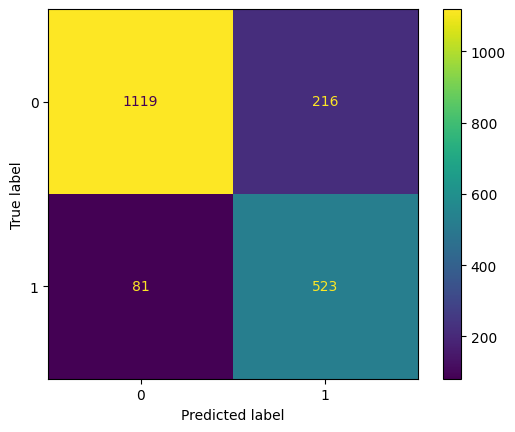

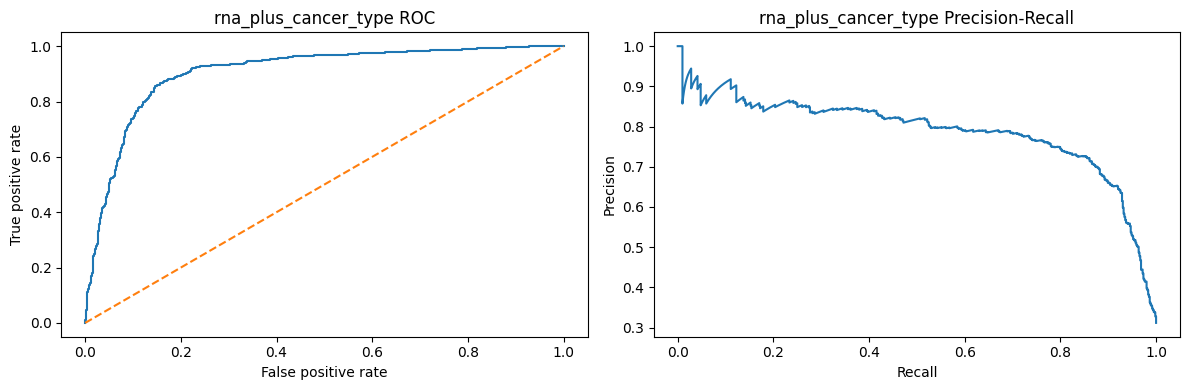

,model,auroc,auprc,balanced_accuracy_at_0.5,f1_at_0.5,brier
0,rna_plus_cancer_type,0.905240,0.788345,0.852048,0.778853,0.118345
1,rna_only_elastic_net_logreg,0.906072,0.781147,0.845643,0.772590,0.117760
2,metadata_only_cancer_type,0.824180,0.647466,0.749707,0.649492,0.179839
3,dummy_prior,0.500000,0.311501,0.500000,0.000000,0.214468


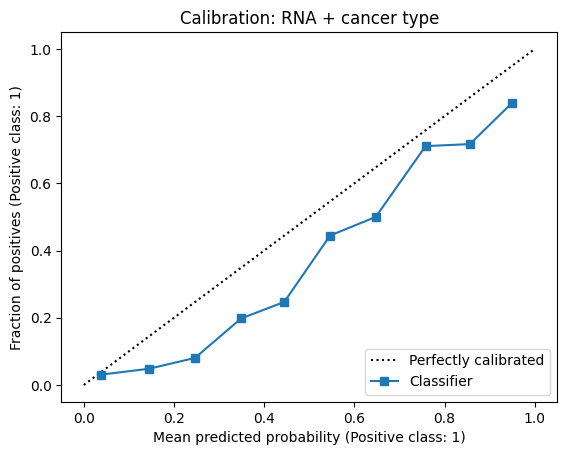

In [21]:
if RUN_COMBINED_MODEL:
    if combo_search is None:
        combo_search = manual_cv_search_combo(
            X_meta=X_meta_train,
            X_rna=X_rna_train,
            y=y_train,
            splitter=inner_cv,
            param_grid=COMBO_PARAM_GRID,
            search_backend=GPU_SEARCH_BACKEND,
            refit_backend=FINAL_REFIT_BACKEND,
            groups=None,
            verbose=1,
            label="COMBO",
        )
    else:
        print("Reusing previously computed combined-model search results.")

    print("Best combined params:", combo_search["best_params"])
    print("Best combined CV AUPRC:", combo_search["best_score"])
    display(combo_search["cv_results"].head(10))

    best_combo_artifact = combo_search["best_artifact"]
    combo_test_proba = predict_combo_artifact(best_combo_artifact, X_meta=X_meta_test, X_rna=X_rna_test)
    combo_metrics = pd.Series({"model": "rna_plus_cancer_type", **evaluate_from_proba(y_test, combo_test_proba)})

    print()
    print("rna_plus_cancer_type")
    display(combo_metrics.to_frame("value"))

    combo_test_pred = (combo_test_proba >= 0.5).astype(int)
    print("Confusion matrix:")
    display(pd.DataFrame(confusion_matrix(y_test, combo_test_pred), index=["true_0", "true_1"], columns=["pred_0", "pred_1"]))
    print("Classification report at fixed threshold 0.5:")
    print(classification_report(y_test, combo_test_pred, digits=3))

    ConfusionMatrixDisplay.from_predictions(y_test, combo_test_pred)
    plt.show()
    plot_roc_pr_curves(y_test, combo_test_proba, title_prefix="rna_plus_cancer_type")

    holdout_results_combo = pd.DataFrame([dummy_metrics, meta_metrics, rna_metrics, combo_metrics])
    holdout_results_combo = holdout_results_combo.sort_values("auprc", ascending=False).reset_index(drop=True)
    display(holdout_results_combo)

    CalibrationDisplay.from_predictions(y_test, combo_test_proba, n_bins=10)
    plt.title("Calibration: RNA + cancer type")
    plt.show()
else:
    combo_search = None
    best_combo_artifact = None
    combo_test_proba = None
    combo_metrics = None
    print("RUN_COMBINED_MODEL is False; skipping combined-model evaluation.")

## 4.17 RNA-model ablation (Task 1, TCGA)

This section tests whether the main RNA elastic-net result depends strongly on model family. Each ablation model uses the same leakage-aware RNA preprocessing sequence inside each training fold: floor-value filtering, top-variance filtering, supervised `SelectKBest`, scaling, and model fitting. Hyperparameters are selected by inner-CV AUPRC; the held-out test set is used only once for the final comparison.

The ablation cell is designed for Kaggle's cuML runtime. The PCA constructor is version-safe because some Kaggle RAPIDS / cuML builds do not accept `random_state` for `cuPCA`. The grid is intentionally compact so the ablation can finish in a reasonable time.

In [22]:
# ============================================================
# RNA model ablation table, cuML-compatible, v2
# ============================================================

import time
import gc
from sklearn.model_selection import ParameterGrid
from sklearn.exceptions import ConvergenceWarning

RUN_RNA_ABLATION = True
RUN_RBF_SVC_ABLATION = False  # keep off by default: RBF SVC is slow and cuML-version-sensitive
ABLATION_ENSEMBLE_TOP_N = 3

if RUN_RNA_ABLATION:
    if not GPU_AVAILABLE or cp is None or cuml is None:
        raise RuntimeError("RUN_RNA_ABLATION=True requires a working cuML/CuPy GPU environment.")

    from cuml.linear_model import LogisticRegression as cuAblationLogisticRegression
    from cuml.ensemble import RandomForestClassifier as cuRandomForestClassifier
    from cuml.neighbors import KNeighborsClassifier as cuKNeighborsClassifier
    from cuml.decomposition import PCA as cuPCA

    try:
        from cuml.svm import SVC as cuSVC
        CUML_SVC_AVAILABLE = True
    except Exception as exc:
        CUML_SVC_AVAILABLE = False
        CUML_SVC_IMPORT_ERROR = repr(exc)
        print("cuML SVC unavailable; SVC ablation will be skipped:", CUML_SVC_IMPORT_ERROR)

    try:
        cuml.set_global_output_type("numpy")
    except Exception:
        pass

    # Compact grid: enough to compare model families without another very long TCGA search.
    ABLATION_GRIDS = {
        "kbest_elastic_net_logreg": {
            "top_k": [5000],
            "k_select": [1000, 2000],
            "scaler": ["maxabs"],
            "model": ["logreg"],
            "C": [0.1, 1.0],
            "l1_ratio": [0.0, 0.5],
        },
        "kbest_random_forest": {
            "top_k": [5000],
            "k_select": [1000],
            "scaler": ["maxabs"],
            "model": ["random_forest"],
            "n_estimators": [300],
            "max_depth": [8, 16],
            "max_features": ["sqrt"],
        },
        "kbest_knn": {
            "top_k": [5000],
            "k_select": [500],
            "scaler": ["standard"],
            "model": ["knn"],
            "n_neighbors": [31, 51],
        },
        "pca_logreg": {
            "top_k": [5000],
            "k_select": [1000],
            "scaler": ["standard"],
            "model": ["pca_logreg"],
            "n_components": [100, 200],
            "C": [0.1, 1.0],
            "l1_ratio": [0.0],
        },
    }

    if RUN_RBF_SVC_ABLATION and CUML_SVC_AVAILABLE:
        ABLATION_GRIDS["kbest_rbf_svc"] = {
            "top_k": [5000],
            "k_select": [500],
            "scaler": ["standard"],
            "model": ["svc"],
            "C": [1.0],
            "kernel": ["rbf"],
            "gamma": ["scale"],
        }

    def _np_float32(X):
        return np.ascontiguousarray(np.asarray(X, dtype=np.float32))

    def _cp_float32(X):
        return cp.asarray(_np_float32(X))

    def _cp_int32(y):
        return cp.asarray(np.asarray(y, dtype=np.int32))

    def _as_numpy_1d(x):
        try:
            if hasattr(x, "to_numpy"):
                x = x.to_numpy()
        except Exception:
            pass
        try:
            if cp is not None and isinstance(x, cp.ndarray):
                x = cp.asnumpy(x)
        except Exception:
            pass
        return np.asarray(x).ravel()

    def make_cuml_pca(n_components):
        """Version-safe cuML PCA constructor.

        Some RAPIDS/cuML builds on Kaggle do not accept random_state for PCA.
        Try the sklearn-like constructor first; fall back to the minimal constructor.
        """
        try:
            return cuPCA(
                n_components=n_components,
                random_state=RANDOM_STATE,
                output_type="numpy",
            )
        except TypeError:
            return cuPCA(
                n_components=n_components,
                output_type="numpy",
            )

    def make_cuml_logreg(**kwargs):
        """Version-tolerant cuML LogisticRegression constructor."""
        attempts = [dict(kwargs)]
        simplified = dict(kwargs)
        for removable in ["l1_ratio", "class_weight", "tol", "penalty"]:
            simplified = dict(simplified)
            simplified.pop(removable, None)
            attempts.append(dict(simplified))

        last_error = None
        for attempt in attempts:
            try:
                return cuAblationLogisticRegression(**attempt)
            except TypeError as exc:
                last_error = exc
        raise last_error

    def _positive_class_scores_from_estimator(clf, X_gpu_or_np):
        """Return positive-class scores on a 0-1 scale where possible."""
        if hasattr(clf, "predict_proba"):
            try:
                proba = clf.predict_proba(X_gpu_or_np)
                proba = np.asarray(proba)
                if proba.ndim == 2 and proba.shape[1] > 1:
                    return proba[:, 1].astype(float)
                return proba.ravel().astype(float)
            except Exception:
                pass

        if hasattr(clf, "decision_function"):
            scores = _as_numpy_1d(clf.decision_function(X_gpu_or_np)).astype(float)
            scores = np.clip(scores, -50, 50)
            return 1.0 / (1.0 + np.exp(-scores))

        pred = _as_numpy_1d(clf.predict(X_gpu_or_np)).astype(float)
        return pred

    def fit_cuml_model_on_ready_matrix(X_ready, y_fit, params):
        """Fit one cuML classifier after fold-internal RNA preprocessing."""
        model_type = params["model"]
        X_gpu = _cp_float32(X_ready)
        y_gpu = _cp_int32(y_fit)

        if model_type == "logreg":
            clf = make_cuml_logreg(
                penalty="elasticnet",
                C=float(params["C"]),
                l1_ratio=float(params["l1_ratio"]),
                max_iter=CUML_MAX_ITER,
                tol=CUML_TOL,
                class_weight="balanced",
                fit_intercept=True,
                output_type="numpy",
            )
            clf.fit(X_gpu, y_gpu)
            return {"model_type": model_type, "clf": clf}

        if model_type == "random_forest":
            clf = cuRandomForestClassifier(
                n_estimators=int(params["n_estimators"]),
                max_depth=int(params["max_depth"]),
                max_features=params["max_features"],
                random_state=RANDOM_STATE,
                n_streams=8,
                output_type="numpy",
            )
            clf.fit(X_gpu, y_gpu)
            return {"model_type": model_type, "clf": clf}

        if model_type == "knn":
            clf = cuKNeighborsClassifier(n_neighbors=int(params["n_neighbors"]))
            clf.fit(X_gpu, y_gpu)
            return {"model_type": model_type, "clf": clf}

        if model_type == "svc":
            svc_kwargs = dict(
                C=float(params["C"]),
                kernel=params["kernel"],
                gamma=params["gamma"],
                max_iter=CUML_MAX_ITER,
                output_type="numpy",
            )
            try:
                clf = cuSVC(probability=True, **svc_kwargs)
            except TypeError:
                clf = cuSVC(**svc_kwargs)
            clf.fit(X_gpu, y_gpu)
            return {"model_type": model_type, "clf": clf}

        if model_type == "pca_logreg":
            n_components = min(int(params["n_components"]), X_ready.shape[1], X_ready.shape[0] - 1)
            pca = make_cuml_pca(n_components)
            X_pca = pca.fit_transform(X_gpu)

            clf = make_cuml_logreg(
                penalty="elasticnet",
                C=float(params["C"]),
                l1_ratio=float(params["l1_ratio"]),
                max_iter=CUML_MAX_ITER,
                tol=CUML_TOL,
                class_weight="balanced",
                fit_intercept=True,
                output_type="numpy",
            )
            clf.fit(cp.asarray(np.asarray(X_pca, dtype=np.float32)), y_gpu)
            return {"model_type": model_type, "pca": pca, "clf": clf}

        raise ValueError(f"Unknown ablation model_type: {model_type}")

    def predict_cuml_model_on_ready_matrix(model_artifact, X_ready):
        model_type = model_artifact["model_type"]
        X_gpu = _cp_float32(X_ready)

        if model_type == "pca_logreg":
            X_pca = model_artifact["pca"].transform(X_gpu)
            X_pred = cp.asarray(np.asarray(X_pca, dtype=np.float32))
        else:
            X_pred = X_gpu

        return _positive_class_scores_from_estimator(model_artifact["clf"], X_pred)

    def fit_ablation_artifact(X_train_fold, y_train_fold, params):
        """Leakage-safe fit: all RNA preprocessing is learned within this fold."""
        rna_params = {
            "top_k": params["top_k"],
            "k_select": params["k_select"],
            "scaler": params["scaler"],
        }
        preproc = fit_rna_preprocessor(X_train_fold, y_train_fold, params=rna_params)
        X_ready = transform_rna_preprocessor(preproc, X_train_fold)
        model_artifact = fit_cuml_model_on_ready_matrix(X_ready, y_train_fold, params)
        return {
            "kind": "rna_ablation",
            "params": dict(params),
            "preproc": preproc,
            "model_artifact": model_artifact,
        }

    def predict_ablation_artifact(artifact, X):
        X_ready = transform_rna_preprocessor(artifact["preproc"], X)
        return predict_cuml_model_on_ready_matrix(artifact["model_artifact"], X_ready)

    def run_one_ablation_search(model_name, param_grid, X_train, y_train, cv):
        """Manual inner-CV search; failures are recorded and skipped rather than crashing the notebook."""
        candidates = list(ParameterGrid(param_grid))
        splits = materialize_cv_splits(cv, y_train, groups=None)

        rows = []
        best_score = -np.inf
        best_params = None

        print(f"\n=== {model_name}: {len(candidates)} candidate settings ===")

        for candidate_i, params in enumerate(candidates, start=1):
            fold_auprcs = []
            fold_aurocs = []
            start = time.time()
            candidate_error = None

            try:
                for fold_i, (tr_idx, val_idx) in enumerate(splits, start=1):
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore", category=ConvergenceWarning)

                        artifact = fit_ablation_artifact(
                            X_train_fold=X_train[tr_idx],
                            y_train_fold=y_train[tr_idx],
                            params=params,
                        )
                        val_score = predict_ablation_artifact(artifact, X_train[val_idx])

                    fold_auprcs.append(average_precision_score(y_train[val_idx], val_score))
                    fold_aurocs.append(roc_auc_score(y_train[val_idx], val_score))

                    del artifact, val_score
                    gc.collect()
                    try:
                        cp.get_default_memory_pool().free_all_blocks()
                    except Exception:
                        pass

                mean_auprc = float(np.mean(fold_auprcs))
                mean_auroc = float(np.mean(fold_aurocs))
                status = "ok"

            except Exception as exc:
                candidate_error = repr(exc)
                mean_auprc = np.nan
                mean_auroc = np.nan
                status = "failed"
                print(f"{model_name}: candidate {candidate_i}/{len(candidates)} failed: {candidate_error}")

            row = {
                "model": model_name,
                **params,
                "mean_cv_auprc": mean_auprc,
                "std_cv_auprc": float(np.std(fold_auprcs)) if len(fold_auprcs) else np.nan,
                "mean_cv_auroc": mean_auroc,
                "std_cv_auroc": float(np.std(fold_aurocs)) if len(fold_aurocs) else np.nan,
                "seconds": time.time() - start,
                "status": status,
                "error": candidate_error,
            }
            rows.append(row)

            if np.isfinite(mean_auprc) and mean_auprc > best_score:
                best_score = mean_auprc
                best_params = dict(params)

            if candidate_i == 1 or candidate_i == len(candidates) or candidate_i % max(1, len(candidates) // 5) == 0:
                print(f"{model_name}: {candidate_i}/{len(candidates)} done | best CV AUPRC={best_score:.4f}")

        cv_results = pd.DataFrame(rows).sort_values("mean_cv_auprc", ascending=False, na_position="last").reset_index(drop=True)

        if best_params is None:
            raise RuntimeError(f"All candidates failed for ablation model {model_name}")

        best_artifact = fit_ablation_artifact(X_train, y_train, best_params)

        return {
            "model": model_name,
            "best_params": best_params,
            "best_score": float(best_score),
            "cv_results": cv_results,
            "best_artifact": best_artifact,
        }

    ablation_searches = {}
    ablation_cv_result_tables = []
    ablation_test_rows = []
    ablation_test_scores = {}
    ablation_failures = {}

    for model_name, grid in ABLATION_GRIDS.items():
        try:
            search = run_one_ablation_search(
                model_name=model_name,
                param_grid=grid,
                X_train=X_rna_train,
                y_train=y_train,
                cv=inner_cv,
            )
            ablation_searches[model_name] = search
            ablation_cv_result_tables.append(search["cv_results"])

            test_score = predict_ablation_artifact(search["best_artifact"], X_rna_test)
            ablation_test_scores[model_name] = test_score
            test_metrics = evaluate_from_proba(y_test, test_score)

            ablation_test_rows.append({
                "model": model_name,
                "best_cv_auprc": search["best_score"],
                "best_params": search["best_params"],
                **{f"test_{k}": v for k, v in test_metrics.items()},
            })
        except Exception as exc:
            ablation_failures[model_name] = repr(exc)
            print(f"Skipping ablation model {model_name} after failure: {repr(exc)}")

    ablation_cv_results = (
        pd.concat(ablation_cv_result_tables, ignore_index=True)
        if len(ablation_cv_result_tables)
        else pd.DataFrame()
    )

    ablation_table = (
        pd.DataFrame(ablation_test_rows)
        .sort_values("test_auprc", ascending=False)
        .reset_index(drop=True)
        if len(ablation_test_rows)
        else pd.DataFrame()
    )

    print("RNA-model ablation table, selected by inner-CV AUPRC and evaluated once on the holdout test set:")
    display(ablation_table)

    if ablation_failures:
        print("\nAblation failures/skips:")
        for name, err in ablation_failures.items():
            print(f" - {name}: {err}")
else:
    ablation_searches = {}
    ablation_cv_results = pd.DataFrame()
    ablation_test_scores = {}
    ablation_table = pd.DataFrame()
    ablation_failures = {}
    print("RUN_RNA_ABLATION is False; skipping RNA ablation table.")



=== kbest_elastic_net_logreg: 8 candidate settings ===
kbest_elastic_net_logreg: 1/8 done | best CV AUPRC=0.7963
kbest_elastic_net_logreg: 2/8 done | best CV AUPRC=0.8096
kbest_elastic_net_logreg: 3/8 done | best CV AUPRC=0.8096
kbest_elastic_net_logreg: 4/8 done | best CV AUPRC=0.8096
kbest_elastic_net_logreg: 5/8 done | best CV AUPRC=0.8096
kbest_elastic_net_logreg: 6/8 done | best CV AUPRC=0.8096
[2026-05-12 18:53:46.361] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
kbest_elastic_net_logreg: 7/8 done | best CV AUPRC=0.8096
[2026-05-12 18:54:38.010] [CUML] [warning] QWL-QN: max iterations reached
[2026-05-12 18:54:38.010] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
[2026-05-12 18:54:59.669] [CUML] [warning] QWL-QN: max iterations reached
[2026-05-12 18:54:59.669] [CUML] [warning] Ma

,model,best_cv_auprc,best_params,test_auroc,test_auprc,test_balanced_accuracy_at_0.5,test_f1_at_0.5,test_brier
0,kbest_elastic_net_logreg,0.809630,"{'C': 0.1, 'k_select': 1000, 'l1_ratio': 0.5, ...",0.902102,0.778831,0.844579,0.772382,0.120298
1,kbest_random_forest,0.785142,"{'k_select': 1000, 'max_depth': 16, 'max_featu...",0.882643,0.772607,0.777766,0.699288,0.128059
2,pca_logreg,0.804497,"{'C': 0.1, 'k_select': 1000, 'l1_ratio': 0.0, ...",0.899397,0.764496,0.840616,0.765543,0.123670
3,kbest_knn,0.765028,"{'k_select': 500, 'model': 'knn', 'n_neighbors...",0.874609,0.730495,0.784997,0.704413,0.129153


### 4.17b Soft-voting ensemble and final ablation comparison

The ensemble is selected without looking at test labels: the top models by inner-CV AUPRC are averaged with uniform weights. This tests whether model diversity improves the held-out AUPRC beyond the main elastic-net and combined models.

In [23]:
# ============================================================
# Soft-voting ensemble and final comparison table
# ============================================================

if RUN_RNA_ABLATION and len(ablation_table) > 0:
    top_ensemble_models = (
        ablation_table
        .sort_values("best_cv_auprc", ascending=False)
        .head(min(ABLATION_ENSEMBLE_TOP_N, len(ablation_table)))["model"]
        .tolist()
    )

    print("Soft-voting ensemble members selected by inner-CV AUPRC:")
    print(top_ensemble_models)

    ensemble_test_score = np.mean(
        [ablation_test_scores[m] for m in top_ensemble_models],
        axis=0,
    )
    ensemble_metrics = evaluate_from_proba(y_test, ensemble_test_score)

    ensemble_row = {
        "model": f"soft_vote_top{len(top_ensemble_models)}_by_cv_auprc",
        "best_cv_auprc": float(np.mean([ablation_searches[m]["best_score"] for m in top_ensemble_models])),
        "best_params": {
            "members": top_ensemble_models,
            "weights": "uniform",
            "selection_rule": "top models by inner-CV AUPRC",
        },
        **{f"test_{k}": v for k, v in ensemble_metrics.items()},
    }

    ablation_table_with_ensemble = (
        pd.concat([ablation_table, pd.DataFrame([ensemble_row])], ignore_index=True)
        .sort_values("test_auprc", ascending=False)
        .reset_index(drop=True)
    )

    # Recompute the holdout dummy score because the grouped-CV section reuses the variable name dummy_proba.
    holdout_dummy_score = np.repeat(float(np.mean(y_train)), len(y_test))

    main_rows_for_ablation = []
    existing_model_scores = {
        "dummy_prior": holdout_dummy_score,
        "metadata_only_cancer_type": meta_test_proba,
        "main_rna_elastic_net_logreg": rna_test_proba,
    }

    if "combo_test_proba" in globals() and combo_test_proba is not None:
        existing_model_scores["main_rna_plus_cancer_type"] = combo_test_proba

    for model_name, score in existing_model_scores.items():
        metrics = evaluate_from_proba(y_test, score)
        main_rows_for_ablation.append({
            "model": model_name,
            "model_family": "main_notebook_model",
            "best_cv_auprc": np.nan,
            "best_params": np.nan,
            **{f"test_{k}": v for k, v in metrics.items()},
        })

    ablation_rows_clean = ablation_table_with_ensemble.copy()
    ablation_rows_clean["model_family"] = "rna_ablation"

    final_ablation_table = pd.concat(
        [pd.DataFrame(main_rows_for_ablation), ablation_rows_clean],
        ignore_index=True,
    )

    preferred_cols = [
        "model",
        "model_family",
        "best_cv_auprc",
        "test_auprc",
        "test_auroc",
        "test_balanced_accuracy_at_0.5",
        "test_f1_at_0.5",
        "test_brier",
        "best_params",
    ]

    final_ablation_table = (
        final_ablation_table[preferred_cols]
        .sort_values("test_auprc", ascending=False)
        .reset_index(drop=True)
    )

    print("Final holdout comparison including main models, RNA ablations, and soft-voting ensemble:")
    display(final_ablation_table)

    final_ablation_table.to_csv("tcga_rna_model_ablation_table.csv", index=False)
    if len(ablation_cv_results):
        ablation_cv_results.to_csv("tcga_rna_model_ablation_cv_results.csv", index=False)
    print("Saved final ablation outputs to tcga_rna_model_ablation_table.csv and tcga_rna_model_ablation_cv_results.csv")
else:
    top_ensemble_models = []
    ablation_table_with_ensemble = pd.DataFrame()
    final_ablation_table = pd.DataFrame()
    print("RNA ablation was skipped or no ablation model succeeded; no ensemble/final ablation table created.")


Soft-voting ensemble members selected by inner-CV AUPRC:
['kbest_elastic_net_logreg', 'pca_logreg', 'kbest_random_forest']
Final holdout comparison including main models, RNA ablations, and soft-voting ensemble:


,model,model_family,best_cv_auprc,test_auprc,test_auroc,test_balanced_accuracy_at_0.5,test_f1_at_0.5,test_brier,best_params
0,soft_vote_top3_by_cv_auprc,rna_ablation,0.799756,0.800193,0.907994,0.845230,0.775636,0.113530,"{'members': ['kbest_elastic_net_logreg', 'pca_..."
1,main_rna_plus_cancer_type,main_notebook_model,NaN,0.788345,0.905240,0.852048,0.778853,0.118345,NaN
2,main_rna_elastic_net_logreg,main_notebook_model,NaN,0.781147,0.906072,0.845643,0.772590,0.117760,NaN
3,kbest_elastic_net_logreg,rna_ablation,0.809630,0.778831,0.902102,0.844579,0.772382,0.120298,"{'C': 0.1, 'k_select': 1000, 'l1_ratio': 0.5, ..."
4,kbest_random_forest,rna_ablation,0.785142,0.772607,0.882643,0.777766,0.699288,0.128059,"{'k_select': 1000, 'max_depth': 16, 'max_featu..."
5,pca_logreg,rna_ablation,0.804497,0.764496,0.899397,0.840616,0.765543,0.123670,"{'C': 0.1, 'k_select': 1000, 'l1_ratio': 0.0, ..."
6,kbest_knn,rna_ablation,0.765028,0.730495,0.874609,0.784997,0.704413,0.129153,"{'k_select': 500, 'model': 'knn', 'n_neighbors..."
7,metadata_only_cancer_type,main_notebook_model,NaN,0.647466,0.824180,0.749707,0.649492,0.179839,NaN
8,dummy_prior,main_notebook_model,NaN,0.311501,0.500000,0.500000,0.000000,0.214468,NaN


Saved final ablation outputs to tcga_rna_model_ablation_table.csv and tcga_rna_model_ablation_cv_results.csv


## 4.18 Within-cancer RNA evaluation

This asks whether the RNA model still carries TP53 signal **within individual tumour types**, not just across pan-cancer mixtures.

,cancer_type,n_samples,n_pos,n_neg,prevalence,cv_auroc_mean,cv_auroc_std,cv_auprc_mean,cv_auprc_std,cv_balanced_accuracy_at_0.5_mean
8,LGG,510,241,269,0.472549,0.955565,0.020072,0.945125,0.029859,0.924166
3,COAD,284,160,124,0.563380,0.859823,0.044764,0.887724,0.030446,0.804917
4,ESCA,180,153,27,0.850000,0.494910,0.142411,0.849973,0.059420,0.502366
6,HNSC,518,351,167,0.677606,0.779932,0.016669,0.847828,0.022565,0.725801
17,UCEC,180,92,88,0.511111,0.821351,0.022849,0.823755,0.036576,0.755865
11,LUSC,495,394,101,0.795960,0.547846,0.080589,0.814538,0.031407,0.550333
10,LUAD,513,257,256,0.500975,0.822231,0.034775,0.801477,0.051982,0.758183
0,BLCA,406,194,212,0.477833,0.816599,0.053689,0.800544,0.048004,0.750300
12,PAAD,178,103,75,0.578652,0.735778,0.081530,0.798976,0.062636,0.632381
16,STAD,413,200,213,0.484262,0.760097,0.026006,0.721237,0.037662,0.683081


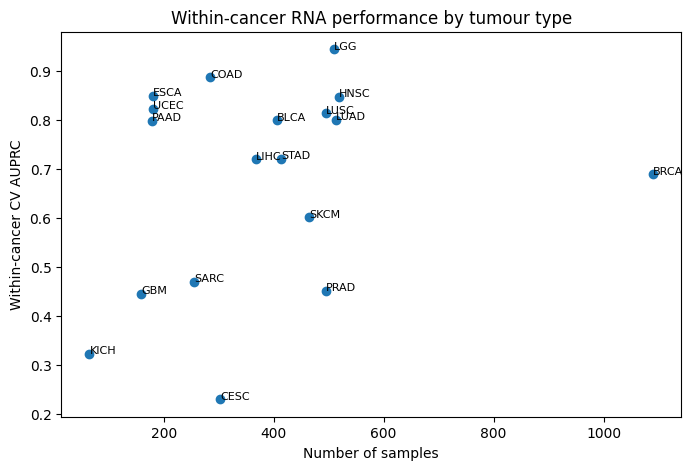

In [24]:
if RUN_WITHIN_CANCER_EVAL:
    within_cancer_rows = []
    for cancer_type, idx in model_meta.groupby(CANCER_TYPE_COL).groups.items():
        idx = np.array(list(idx))
        y_sub = y[idx]
        counts = pd.Series(y_sub).value_counts()
        n_neg = int(counts.get(0, 0))
        n_pos = int(counts.get(1, 0))
        if n_neg < MIN_SAMPLES_PER_CLASS or n_pos < MIN_SAMPLES_PER_CLASS:
            continue

        cv_splits = min(5, n_neg, n_pos)
        if cv_splits < 3:
            continue

        sub_cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)
        sub_scores = crossval_fixed_rna_params(
            X=X_rna[idx],
            y=y_sub,
            splitter=sub_cv,
            params=rna_search["best_params"],
            backend=WITHIN_CANCER_BACKEND,
        )

        within_cancer_rows.append({
            "cancer_type": cancer_type,
            "n_samples": len(idx),
            "n_pos": n_pos,
            "n_neg": n_neg,
            "prevalence": n_pos / len(idx),
            "cv_auroc_mean": float(sub_scores["auroc"].mean()),
            "cv_auroc_std": float(sub_scores["auroc"].std(ddof=0)),
            "cv_auprc_mean": float(sub_scores["auprc"].mean()),
            "cv_auprc_std": float(sub_scores["auprc"].std(ddof=0)),
            "cv_balanced_accuracy_at_0.5_mean": float(sub_scores["balanced_accuracy_at_0.5"].mean()),
        })

    within_cancer_df = pd.DataFrame(within_cancer_rows).sort_values("cv_auprc_mean", ascending=False)
    display(within_cancer_df)

    if len(within_cancer_df) > 0:
        plt.figure(figsize=(8, 5))
        plt.scatter(within_cancer_df["n_samples"], within_cancer_df["cv_auprc_mean"])
        for _, row in within_cancer_df.iterrows():
            plt.text(row["n_samples"], row["cv_auprc_mean"], row["cancer_type"], fontsize=8)
        plt.xlabel("Number of samples")
        plt.ylabel("Within-cancer CV AUPRC")
        plt.title("Within-cancer RNA performance by tumour type")
        plt.show()
else:
    print("RUN_WITHIN_CANCER_EVAL is False; skipping within-cancer evaluation.")

## Final methodological discussion and interpretation

This project addressed the assignment objective: using gene expression profiles to predict TP53 mutation status. The central idea is that TP53 mutations can alter cellular transcriptional programs, either directly through disruption of p53-mediated regulation or indirectly through cancer-type-specific selective pressures and downstream pathway activity. Therefore, RNA expression may contain predictive information about TP53 mutation status. However, throughout the analysis I interpret this as a predictive association, not as proof that the model has discovered a causal mechanism.

### Task 1: TP53 mutant versus wild type

For Task 1, I formulated the problem as binary classification: each sample was labelled as either TP53-mutant or TP53 wild type based on mutation annotation data. Importantly, the labels were derived from mutation calls, not from RNA expression values. The gene expression matrix was used only as the predictor feature matrix.

The main CCLE binary task used a train/validation/test split stratified by TP53 mutation status. This preserves the mutant versus wild-type class balance across splits and avoids evaluating the model on a test set with a very different mutation prevalence from the training set. I also examined lineage distributions after splitting because cancer lineage is an important possible confounder: both gene expression patterns and TP53 mutation frequency can vary substantially across cancer types.

The binary RNA-expression models performed well, especially regularized linear models such as logistic regression and linear SVM. This is appropriate for high-dimensional gene expression data because the number of genes is large, many genes are correlated, and simpler regularized models often provide strong baselines. I also compared RNA-only models with metadata-only and combined models to assess whether prediction was driven mainly by gene expression signal or by lineage/cancer-type structure.

A key observation is that metadata-only models can achieve non-trivial performance. This means that some predictive signal is associated with lineage or cancer type rather than TP53 biology alone. For this reason, the RNA model results should be interpreted cautiously: high predictive performance does not automatically imply that the model has learned only TP53-specific transcriptional consequences. The lineage-aware checks and metadata baselines were included to make this limitation explicit.

### Task 2: TP53 mutation type / consequence classes

For Task 2, the assignment asked for prediction of the type of TP53 mutation. I implemented this as a multiclass classification task using mutation annotation information to define broader TP53 mutation-type/consequence classes.

Instead of trying to classify every rare raw mutation category separately, I grouped related mutation annotations into broader classes with enough sample support for supervised learning. In CCLE, the main classes were:

- `wild_type`
- `missense_or_inframe`
- `lof_or_splice`

In TCGA, the corresponding classes were:

- `WT`
- `missense`
- `truncating_or_splice`

This grouping is biologically motivated. Missense and in-frame mutations often preserve protein length but alter amino-acid sequence or local protein structure. In contrast, nonsense, frameshift, splice-site, and truncating events are more likely to severely disrupt TP53 protein function or produce loss-of-function effects. Grouping rare mutation annotations into broader consequence classes avoids extremely small classes and makes the multiclass task more statistically stable.

This is a coarse mutation-type classification rather than a complete raw mutation-mechanism classifier. A more literal interpretation of the assignment could separate categories such as substitution, insertion, deletion, frameshift insertion, frameshift deletion, nonsense, missense, synonymous, and splice-site mutations. However, many of these categories may have too few samples to support reliable classification from RNA expression. Therefore, I treated Task 2 as mutation-type/consequence prediction, which is both biologically meaningful and feasible for supervised modelling.

For Task 2, I used a dedicated multiclass split. Where possible, I stratified by the combined mutation-type label and lineage. This preserves both mutation-type class balance and major lineage composition across train, validation, and test sets. This does not mean that the model is trained separately within each lineage. Rather, lineage-aware stratification helps prevent the evaluation split from being dominated by different lineage mixtures. Rare lineage-by-mutation-type combinations may still be too small for reliable per-lineage claims, so I avoid overinterpreting performance for rare groups.

Task 2 was harder than Task 1, as expected. Binary TP53 mutation status has a stronger and more stable signal, while mutation-type prediction requires distinguishing between different altered TP53 states that may produce overlapping transcriptional consequences. Therefore, macro-F1, balanced accuracy, per-class precision/recall/F1, and confusion matrices are especially important for Task 2 because accuracy alone can hide poor performance on smaller mutation-type classes.

### Preprocessing and leakage control

A major methodological priority was avoiding data leakage. Mutation annotation columns were used only to construct labels and were not included as expression features. Preprocessing steps such as scaling, feature selection, and model fitting were performed after splitting and within modelling workflows where appropriate. This is important because fitting transformations or selecting genes on the full dataset before train/test splitting can leak information from the test set into the training process and inflate performance estimates.

The project also considered possible confounding by lineage or cancer type. RNA expression is highly tissue-specific, and cancer types differ in TP53 mutation prevalence. As a result, a model could partially learn lineage-associated expression patterns rather than TP53-specific biology. To address this, I compared RNA-only models with metadata-only models and performed lineage/cancer-type-aware analyses. These checks do not eliminate confounding completely, but they help quantify and interpret it.

### Model choice

I evaluated multiple modelling approaches, including simple baselines, regularized logistic regression, linear SVM, random forest, PCA-based models, and ensemble-style approaches. This was important because the assignment encouraged exploration of different architectures, but in high-dimensional RNA expression data, simpler regularized models are often strong and scientifically defensible.

The purpose of testing multiple models was not only to maximize performance, but also to understand whether the predictive signal was robust across model classes. If only one complex model performed well, the result would be harder to trust. The fact that several RNA-based approaches achieved meaningful performance supports the conclusion that the expression data contain information relevant to TP53 mutation status.

### Evaluation strategy

For Task 1, I used binary classification metrics including AUROC, AUPRC, F1 score, balanced accuracy, sensitivity/recall, specificity, and confusion-matrix-based summaries. AUROC measures ranking ability across thresholds, while AUPRC is especially useful when classes are imbalanced. F1 and balanced accuracy help evaluate performance at a chosen threshold and avoid relying only on overall accuracy.

For Task 2, I used multiclass metrics such as macro-F1, weighted F1, balanced accuracy, one-vs-rest AUROC/AUPRC, and per-class precision/recall/F1. Macro-F1 is particularly important because it gives equal weight to each class and therefore penalizes models that perform well only on the majority class.

The results support the conclusion that TP53 mutation status is more predictable from RNA expression than detailed mutation type. This is biologically plausible because different TP53 mutation types may converge on similar downstream transcriptional effects, while binary mutation status captures a broader distinction between altered and unaltered TP53 function.

### Biological interpretation

The interpretation of important genes and pathways was treated cautiously. Some highly weighted or important features may reflect TP53 pathway activity, DNA damage response, cell-cycle regulation, apoptosis, or p53 feedback regulation. However, because this is an observational prediction task, feature importance should not be interpreted as causal evidence. A gene can be predictive because it is downstream of TP53, correlated with cancer lineage, associated with proliferation, or linked to technical/dataset structure.

The most defensible biological interpretation is that RNA expression contains both TP53-related signal and cancer-context signal. Therefore, the models are useful for prediction and hypothesis generation, but they do not prove a direct mechanistic relationship between every selected gene and TP53 mutation.

### Limitations

Several limitations should be considered:

1. **Mutation-type grouping**
   Task 2 used broad mutation-type/consequence groups rather than every raw DNA mutation category. This was done to avoid unstable rare classes, but it means the task is a coarse mutation-type prediction problem.

2. **Lineage and cancer-type confounding**
   TP53 mutation frequency differs across cancer types, and RNA expression is strongly lineage-dependent. Although I used stratification, metadata baselines, and grouped analyses to assess this issue, confounding cannot be completely eliminated.

3. **Generalization across datasets**
   CCLE cell lines and TCGA tumors are biologically and technically different. Cell lines are simplified model systems, while tumors contain microenvironmental and purity effects. Therefore, performance may differ across datasets.

4. **Class imbalance**
   Some mutation-type classes are smaller than others, especially loss-of-function/splice/truncating classes. This makes Task 2 harder and makes macro-averaged metrics more important than accuracy.

5. **Predictive association, not causation**
   The models identify expression patterns associated with TP53 mutation labels. They do not prove that any individual gene causes or is caused by TP53 mutation.

### Overall conclusion

Overall, the analysis shows that gene expression profiles can be used to predict TP53 mutation status with meaningful performance, especially for the binary mutant versus wild-type task. Mutation-type prediction is more challenging but still feasible when mutation annotations are grouped into biologically meaningful consequence classes.

The strongest conclusion is that TP53 mutation status leaves a detectable signal in transcriptomic data, but that signal is mixed with lineage, cancer-type, and dataset-specific structure. Therefore, careful splitting, leakage control, metadata comparison, and cautious biological interpretation are necessary for a scientifically defensible analysis.

## Final summary and defensibility statement

This project addresses the assignment task — predicting **TP53 mutation status from gene-expression profiles** — in **two independent cohorts** (CCLE cell lines and TCGA primary tumours), and implements both required tasks in each.

### Task 1 — Mutant vs wild-type

The Task 1 label (`TP53_mut_nonsyn`) is constructed from raw mutation annotations (`VariantClassification`, `VariantInfo`, `ProteinChange`, etc.) before any modelling, and is verified not to be derivable from any expression feature. A defensive assertion is included to prevent mutation-annotation columns from leaking into the predictor matrix. Splits are stratified by label; in CCLE all preprocessing that uses the label (correlation-based supervised feature selection, standardisation) is fit fold-internally inside the scikit-learn pipeline (`RNAFeatureBuilder`) so that no validation- or test-fold information leaks into training. The TCGA pipeline uses the same discipline (`fit_rna_preprocessor` re-fits the floor filter, top-variance filter, SelectKBest, and scaler on each training fold). A patient-level deduplication step keeps at most one sample per TCGA patient, with primary-tumour sample-type codes prioritised, eliminating patient-level leakage.

Multiple architectures are evaluated against a dummy-prior baseline and a metadata-only (lineage / cancer-type) baseline so that the marginal value of RNA over tissue composition is auditable: elastic-net logistic regression, L2 logistic regression, linear SVM, optional random forest, and (where GPU is available) a cuML ablation across kNN, SVC, PCA-then-logreg, and random forest, plus a soft-voting ensemble. Evaluation reports AUROC, AUPRC, balanced accuracy, F1, precision, recall, specificity, and confusion-matrix counts, with bootstrap confidence intervals on AUROC and AUPRC, a Brier score, and a reliability curve. A lineage- / cancer-type-grouped cross-validation is run as an explicit robustness check against tissue-composition confounding, and a label-definition sensitivity sweep (`TP53_mut_nonsyn`, `TP53_mut_lof`, and a strict-exclusion variant) verifies that conclusions do not depend on a single label choice.

### Task 2 — Mutation type

The Task 2 mutation-type label is constructed for **every sample, including wild-type**, from the same raw annotation fields.
Two collapse decisions deserve explicit defence. **Synonymous TP53 variants do not change protein sequence** and are therefore expected to be transcriptionally indistinguishable from wild-type; including them as their own modelling class would inject label noise without biological justification, so they are reported but excluded. **In-frame indels** in CCLE are merged with missense because they share the "protein produced, residue identity altered" phenotype and the in-frame indel pool alone is too small for stable cross-validation; in TCGA the in-frame pool was kept as a separately reported excluded class so that the loss-of-function modelling class (`truncating_or_splice`) remains transcriptionally homogeneous. All collapses are accompanied by the raw class counts before and after, so the granularity choice is auditable.

Task 2 uses its own train / validation / test split, stratified jointly by mutation-type label and by the cohort's tissue grouping variable (CCLE lineage, TCGA cancer-type abbreviation) via `make_stable_joint_strata`, which collapses sparse label × group cells to a rare-group bucket and falls back to label-only stratification if joint strata remain too sparse. Hyperparameter selection uses cross-validation macro-F1 on the training split with the same joint stratification, and the final model is selected by validation macro-F1, not by test performance. The held-out test set is touched once, after refitting on train + validation with the validation-selected hyperparameters. Evaluation reports accuracy, balanced accuracy, macro-F1, weighted-F1, one-vs-rest macro AUROC and macro AUPRC, per-class precision / recall / F1, support counts, and the full confusion matrix. A cancer-type-grouped Task 2 CV is included as a robustness check.

### Use of TP53 deposited knowledge

The biological interpretation overlays the top predictive coefficients of the final mRNA model with a curated 50-gene canonical TP53 transcriptional target set drawn from Fischer (2017) and consistent with the gene catalogues at https://p53.fr and https://tp53.cancer.gov. The number of canonical TP53 targets recovered in the top-30 coefficients is reported, and per-lineage AUPRC / AUROC for the primary model is reported so that lineage-driven contributions to the signal can be inspected directly.

### Limitations explicitly acknowledged

CCLE has a higher TP53 mutation prevalence than TCGA (~58% vs ~37%), reflecting selection bias from cell-line immortalisation; the two cohorts are therefore modelled independently rather than pooled. Bulk transcriptome cannot resolve fine-grained missense allele identity (e.g. R175H vs R248W vs R273H), so Task 2 is necessarily framed at a *functional class* granularity rather than at an *amino-acid-substitution* granularity. The grouped (lineage / cancer-type) CV results, the per-lineage AUPRC table, and the metadata-only baselines together quantify how much of the Task 1 and Task 2 signal is attributable to RNA above and beyond tissue composition; conclusions about the value of RNA are restricted to what those comparisons support and are not extrapolated beyond the cohorts modelled here.